In [1]:
from __future__ import print_function, division
import sys,os
# line 4 and line 5 below are for development purposes and can be removed
qspin_path = os.path.join(os.getcwd(),"../../")
sys.path.insert(0,qspin_path)
#####################################################################
#                            example 0                              #
#    In this script we demonstrate how to use QuSpin's exact        #
#    diagonlization routines to solve for the eigenstates and       #
#    energies of the XXZ chain.                                     #
#####################################################################
from quspin.operators import hamiltonian, exp_op, quantum_operator # Hamiltonians and operators
from quspin.basis import spin_basis_1d # Hilbert space spin basis
from quspin.tools.measurements import ent_entropy
import numpy as np # generic math functions
from numpy import linalg as LA
import scipy.sparse as sp
from scipy.linalg import logm, expm, sinm, cosm, svd
from scipy.sparse.linalg import eigs, eigsh
from scipy.sparse.linalg import expm, expm_multiply
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline
from scipy.stats import linregress

import time
import copy
import numba as nb
import matplotlib.pyplot as plt
import functools as ft
import scienceplots
import math
import random
from scipy.stats import unitary_group
import itertools
from joblib import Parallel, delayed
from scipy.linalg import svd
import json

%load_ext memory_profiler
plt.style.use(['science','notebook', 'grid'])

In [2]:
def Fredkin_Ham_bd(L,i,j):
    basis = spin_basis_1d(L,S='1/2',pauli=1)
    First_term_I = [[1/2, i]]
    Last_term_I = [[1/2, j]]
    First_term_z = [[-1.0/2, i]]
    Last_term_z = [[1.0/2, j]]
    static = [["I",First_term_I],["z",First_term_z],["I",First_term_I],["z",Last_term_z]]
    dynamic =[]
    return hamiltonian(static,dynamic,basis=basis,dtype=np.float64,check_symm=False)

def Fredkin_Ham_bulk(L,j):
    basis = spin_basis_1d(L,S='1/2',pauli=1)
    III = [[2.0/8,i,i+1,i+2] for i in range(j,L-2)]
    Iaa = [[-1.0/8,i,i+1,i+2] for i in range(j,L-2)]
    zII = [[1.0/8,i,i+1,i+2] for i in range(j,L-2)]
    zaa = [[-1.0/8,i,i+1,i+2] for i in range(j,L-2)]
    IIz = [[-1.0/8,i,i+1,i+2] for i in range(j,L-2)]
    aaI = [[-1.0/8,i,i+1,i+2] for i in range(j,L-2)]
    aaz = [[1.0/8,i,i+1,i+2] for i in range(j,L-2)]
    static = [["III",III],["Ixx",Iaa],["Iyy",Iaa],["Izz",Iaa],["zII",zII],["zxx",zaa],["zyy",zaa],["IIz",IIz],["xxI",aaI],["yyI",aaI],["zzI",aaI],["xxz",aaz],["yyz",aaz]]
    dynamic = []
    return hamiltonian(static,dynamic,basis=basis,dtype=np.float64,check_symm=False)

def Fredkin_Ham_bulk_dressed(L,j):
    basis = spin_basis_1d(L,S='1/2',pauli=1)
    zII = [[1.0/8,i,i+1,i+2] for i in range(j,L-2)]
    zaa = [[-1.0/8,i,i+1,i+2] for i in range(j,L-2)]
    IIz = [[1.0/8,i,i+1,i+2] for i in range(j,L-2)]
    aaz = [[-1.0/8,i,i+1,i+2] for i in range(j,L-2)]
    static = [["zII",zII],["zxx",zaa],["zyy",zaa],["zzz",zaa],["IIz",IIz],["xxz",aaz],["yyz",aaz],["zzz",aaz]]
    dynamic = []
    return hamiltonian(static,dynamic,basis=basis,dtype=np.float64,check_symm=False)

def Fredkin_Ham_total(L):
    return Fredkin_Ham_bd(L,0,L-1) + Fredkin_Ham_bulk(L,0)

def Fredkin_Ham_PBC_0(L,j,k):
    basis = spin_basis_1d(L,S='1/2',pauli=1)
    III = [[2.0/8,i%L,(i+1)%L,(i+2)%L] for i in range(j,k)]
    Iaa = [[-1.0/8,i%L,(i+1)%L,(i+2)%L] for i in range(j,k)]
    zII = [[1.0/8,i%L,(i+1)%L,(i+2)%L] for i in range(j,k)]
    zaa = [[-1.0/8,i%L,(i+1)%L,(i+2)%L] for i in range(j,k)]
    IIz = [[-1.0/8,i%L,(i+1)%L,(i+2)%L] for i in range(j,k)]
    aaI = [[-1.0/8,i%L,(i+1)%L,(i+2)%L] for i in range(j,k)]
    aaz = [[1.0/8,i%L,(i+1)%L,(i+2)%L] for i in range(j,k)]
    static = [["III",III],["Ixx",Iaa],["Iyy",Iaa],["Izz",Iaa],["zII",zII],["zxx",zaa],["zyy",zaa],["IIz",IIz],["xxI",aaI],["yyI",aaI],["zzI",aaI],["xxz",aaz],["yyz",aaz]]
    dynamic = []
    return hamiltonian(static,dynamic,basis=basis,dtype=np.float64,check_symm=False)


def Fredkin_Ham_PBC(L):
    basis = spin_basis_1d(L,S='1/2',pauli=1)
    III = [[1.0/8,i,(i+1)%L,(i+2)%L] for i in range(L)]
    Iaa = [[-1.0/8,i,(i+1)%L,(i+2)%L] for i in range(L)]
    zII = [[1.0/8,i,(i+1)%L,(i+2)%L] for i in range(L)]
    zaa = [[-1.0/8,i,(i+1)%L,(i+2)%L] for i in range(L)]
    III_1 = [[1.0/8,i,(i+1)%L,(i+2)%L] for i in range(L)]
    aaI = [[-1.0/8,i,(i+1)%L,(i+2)%L] for i in range(L)]
    IIz = [[-1.0/8,i,(i+1)%L,(i+2)%L] for i in range(L)]
    aaz = [[1.0/8,i,(i+1)%L,(i+2)%L] for i in range(L)]
    static = [["III",III],["Ixx",Iaa],["Iyy",Iaa],["Izz",Iaa],["zII",zII],["zxx",zaa],["zyy",zaa],["zzz",zaa],["III",III_1],["xxI",aaI],["yyI",aaI],["zzI",aaI],["IIz",IIz],["xxz",aaz],["yyz",aaz],["zzz",aaz]]
    dynamic = []
    return hamiltonian(static,dynamic,basis=basis,dtype=np.float64,check_symm=False)

def Fredkin_Ham_PBC_zero_mag(L):
    basis = spin_basis_1d(L,S='1/2',pauli = 1, Nup=L//2) # zero magnetisation sector
    III = [[1.0/8,i,(i+1)%L,(i+2)%L] for i in range(L)]
    Iaa = [[-1.0/8,i,(i+1)%L,(i+2)%L] for i in range(L)]
    zII = [[1.0/8,i,(i+1)%L,(i+2)%L] for i in range(L)]
    zaa = [[-1.0/8,i,(i+1)%L,(i+2)%L] for i in range(L)]
    III_1 = [[1.0/8,i,(i+1)%L,(i+2)%L] for i in range(L)]
    aaI = [[-1.0/8,i,(i+1)%L,(i+2)%L] for i in range(L)]
    IIz = [[-1.0/8,i,(i+1)%L,(i+2)%L] for i in range(L)]
    aaz = [[1.0/8,i,(i+1)%L,(i+2)%L] for i in range(L)]
    static = [["III",III],["Ixx",Iaa],["Iyy",Iaa],["Izz",Iaa],["zII",zII],["zxx",zaa],["zyy",zaa],["zzz",zaa],["III",III_1],["xxI",aaI],["yyI",aaI],["zzI",aaI],["IIz",IIz],["xxz",aaz],["yyz",aaz],["zzz",aaz]]
    dynamic = []
    return hamiltonian(static,dynamic,basis=basis,dtype=np.float64,check_symm=False)

In [3]:
#Time evolution
def evol_op (H, at,start_time, end_time, time_step):
    return exp_op(H,a=at*(-1j),start=start_time,stop=end_time,num=time_step,endpoint=True,iterate=False)

def timestepN(starttime, endtime, deltat):
    return (endtime-starttime)/deltat

def timesteplistT(starttime, endtime, no_steps):
    timelistT = []
    for i in range(no_steps):
        tel = starttime + i*((endtime-starttime)/(no_steps-1))
        timelistT.append(tel)
    return timelistT

def evolved_observable_general_inner(H, Op, starttime, endtime, timestep, psia, psib):
    tq = []
    steps = int((endtime-starttime)/timestep)+1
    for i in range(steps):
        psiq1 = np.squeeze(np.transpose(evol_op(H,1.0,i*timestep, i*timestep,1).dot(psia)))
        psiq2 = Op.dot(psiq1)
        psiq3 = np.squeeze(np.transpose(evol_op(H,1.0,i*timestep, i*timestep,1).dot(psib)))
        ovlap = np.inner(np.conjugate(np.transpose(psiq3)),psiq2)
        tq.append(ovlap)
    return tq

def evolved_observable_expvalue(H, Op, starttime, endtime, timestep, psia):
    tq = []
    steps = int((endtime-starttime)/timestep)+1
    for i in range(steps):
        psiq1 = np.squeeze(np.transpose(evol_op(H,1.0,i*timestep, i*timestep,1).dot(psia)))
        psiq2 = Op.dot(psiq1)
        ovlap = np.inner(np.conjugate(np.transpose(psiq1)),psiq2)
        tq.append(ovlap.real)
    return tq

def evolved_overlap(H, starttime, endtime, timestep, psia, psib):
    tq = []
    steps = int((endtime-starttime)/timestep)+1
    for i in range(steps):
        psiq1 = np.squeeze(np.transpose(evol_op(H,1.0,i*timestep, i*timestep,1).dot(psia)))
        ovlap = np.inner(np.conjugate(np.transpose(psiq1)),psib)
        tq.append(abs(ovlap)**2)
    return tq

def evolved_state(H, starttime, endtime, timestep, psia):
    tq = []
    steps = int((endtime-starttime)/timestep)+1
    for i in range(steps):
        psiq1 = np.squeeze(np.transpose(evol_op(H,1.0,i*timestep, i*timestep,1).dot(psia)))
        tq.append(psiq1)
    return tq

def evolved_entropy(H, L, starttime, endtime, timestep, psia, alpha):
    tq = []
    steps = int((endtime-starttime)/timestep)+1
    for i in range(steps):
        psiq1 = np.squeeze(np.transpose(evol_op(H,1.0,i*timestep, i*timestep,1).dot(psia)))
        S_ent = basis.ent_entropy(state=psiq1, sub_sys_A=tuple(range(L//2)),alpha=alpha)
        S_ent_value = S_ent['Sent_A']
        tq.append(S_ent_value)
    return tq

def evolved_single_observable_expvalue(H, Op, time, psi):
    psiq1 = np.squeeze(np.transpose(evol_op(H,1.0,time, time,1).dot(psi)))
    psiq2 = Op.dot(psiq1)
    ovlap = np.inner(np.conjugate(np.transpose(psiq1)),psiq2)
    return ovlap

def evolved_double_observable_expvalue(H, Op1, Op2, time, psi):
    psiq1 = np.squeeze(np.transpose(evol_op(H,1.0,time, time,1).dot(psi)))
    psiq2 = Op2.dot(psiq1)
    psiq3 = Op1.dot(psiq2)
    ovlap = np.inner(np.conjugate(np.transpose(psiq1)),psiq2)
    return ovlap

def OTOC_operational(H, W, V, t, psi):
    psi_1 = V.dot(psi)
    psi_2 = np.squeeze(np.transpose(evol_op(H,1.0,t,t,1).dot(psi_1)))
    psi_3 = W.dot(psi_2)
    psi_4 = np.squeeze(np.transpose(evol_op(H,-1.0,t,t,1).dot(psi_3)))
    psi_5 = V.conj().T.dot(psi_4)
    psi_6 = np.squeeze(np.transpose(evol_op(H,1.0,t,t,1).dot(psi_5)))
    psi_7 = W.conj().T.dot(psi_6)
    psi_8 = np.squeeze(np.transpose(evol_op(H,-1.0,t,t,1).dot(psi_7)))
    ovlap = np.inner(np.conjugate(np.transpose(psi)),psi_8)
    return ovlap

def OTOC_full(H, W, V, t, psi):
    psi_1 = V.dot(psi)
    psi_2 = np.squeeze(np.transpose(evol_op(H,1.0,t,t,1).dot(psi_1)))
    psi_3 = W.dot(psi_2)
    psi_4 = np.squeeze(np.transpose(evol_op(H,-1.0,t,t,1).dot(psi_3)))
    psi_11 = np.squeeze(np.transpose(evol_op(H,1.0,t,t,1).dot(psi)))
    psi_21 = W.dot(psi_11)
    psi_31 = np.squeeze(np.transpose(evol_op(H,-1.0,t,t,1).dot(psi_21)))
    psi_41 = V.dot(psi_31)
    psi_c = psi_4 - psi_41
    ovlap = np.inner(np.conjugate(np.transpose(psi_c)),psi_c)
    return ovlap 

In [4]:
#Neel, Dimer, Spinon states, Spin correlation observables, Neel Obs, VBS Obs
up = np.array([1.0,0.0])
dn = np.array([0.0,1.0])
mg = (1/np.sqrt(2))*(np.kron(up,dn)-np.kron(dn,up))
mg1 = (1/np.sqrt(2))*(np.kron(dn,up)-np.kron(up,dn))

#Neel state
def allup(L):
    state =[]
    for i in range(L):
        state.append(up)
    return ft.reduce(np.kron,state)

def alldown(L):
    state = []
    for i in range(L):
        state.append(dn)
    return ft.reduce(np.kron,state)

def neel(L):
    state = []
    for i in range(L):
        if (i+1)%2 == 1:
            state.append(up)
        if (i+1)%2 == 0:
            state.append(dn)
    return ft.reduce(np.kron,state)
#Dimer state
def MGstate(L):
    state =[]
    for i in range(int(L/2)):
        state.append(mg)
    return ft.reduce(np.kron,state)

def MGstate1(L):
    state =[]
    for i in range(int(L/2)):
        state.append(mg1)
    return ft.reduce(np.kron,state)

#Domain wall
def domainwallnew(L):
    state = []
    for i in range(L):
        if i+1 <= int(L/2):
            state.append(up)
        if i+1 > int(L/2):
            state.append(dn)
    return ft.reduce(np.kron,state)
    #return state
    
def domainwall_state_1(L):
    state = []
    for i in range(L):
        if i <= L//2:
            state.append('up')
        if i > L//2:
            state.append('dn')
    #return ft.reduce(np.kron,state)
    return state

def domainwallnew_state(L):
    state = []
    for i in range(L):
        if i+1 <= int(L/2):
            state.append('up')
        if i+1 > int(L/2):
            state.append('dn')
    return state

def twodomainwall_state(L,n):
    state = []
    for i in range((L-n)//2):
        state.append('up')
    for i in range(n):
        state.append('dn')
    for i in range((L-n)//2):
        state.append('up')
    return state

def twodomainwall(L,n):
    state = []
    for i in range((L-n)//2):
        state.append(up)
    for i in range(n):
        state.append(dn)
    for i in range((L-n)//2):
        state.append(up)
    return ft.reduce(np.kron,state)

#perturbed ferro
def perturbed_up(L):
    state = []
    for i in range(L):
        if i+1 <= int(L/2)-1:
            state.append(up)
        if i+1 == int(L/2):
            state.append(dn)
        if i+1 > int(L/2):
            state.append(up)
    return ft.reduce(np.kron,state)

def perturbed_up_state(L):
    state = []
    for i in range(L):
        if i+1 <= int(L/2)-1:
            state.append('up')
        if i+1 == int(L/2):
            state.append('dn')
        if i+1 > int(L/2):
            state.append('up')
    return state

def random_product_state(L):
    state = []
    for i in range(L):
        RandomUnitary = unitary_group.rvs(2)
        random_two_state = RandomUnitary.dot(up)
        state.append(random_two_state)
    return ft.reduce(np.kron,state)
    

#Domain wall
def domainwall(L):
    state = []
    for i in range(L):
        if i+1 <= int(L/2):
            if (i+1)%2 == 1:
                state.append(up)
            if (i+1)%2 == 0:
                state.append(dn)
        if i+1 > int(L/2):
            if (i+1)%2 == 1:
                state.append(dn)
            if (i+1)%2 == 0:
                state.append(up)
    #return ft.reduce(np.kron,state)
    return state
#Two-spinon
def spinon_2(L):
    state =[]
    for i in range(L):
        if (i+1)%2 == 1:
            state.append(up)
        if (i+1)%2 == 0:
            state.append(dn)
    state[int(L/2)-1]=up
    state[int(L/2)]=dn
    return ft.reduce(np.kron,state)
#four-spinon
def spinon_4(L):
    state = []
    for i in range(L):
        if (i+1)%2 == 1:
            state.append(up)
        if (i+1)%2 == 0:
            state.append(dn)
    state[int(L/2)-2] = dn
    state[int(L/2)-3] = up
    state[int(L/2)+1] = up
    state[int(L/2)+2] = dn
    return ft.reduce(np.kron,state)

#Spin operators x, y, z at i-th site
def spinopx(N,i):
    basisq = spin_basis_1d(N,pauli=0)
    spincoeff = [[1.0, i]]
    return hamiltonian([['x', spincoeff]],[], basis=basisq, check_herm=False, check_symm=False)

def spinopy(N,i):
    basisq = spin_basis_1d(N,pauli=0)
    spincoeff = [[1.0, i]]
    return hamiltonian([['y', spincoeff]],[], basis=basisq, check_herm=False, check_symm=False)

def spinopz(N,i):
    basisq = spin_basis_1d(N,pauli=0)
    spincoeff = [[1.0, i]]
    return hamiltonian([['z', spincoeff]],[], basis=basisq, check_herm=False, check_symm=False)

def spinopx_pauli(N,i):
    basisq = spin_basis_1d(N,pauli=1)
    spincoeff = [[1.0, i]]
    return hamiltonian([['x', spincoeff]],[], basis=basisq, check_herm=False, check_symm=False)

def spinopy_pauli(N,i):
    basisq = spin_basis_1d(N,pauli=1)
    spincoeff = [[1.0, i]]
    return hamiltonian([['y', spincoeff]],[], basis=basisq, check_herm=False, check_symm=False)

def spinopz_pauli(N,i):
    basisq = spin_basis_1d(N,pauli=1)
    spincoeff = [[1.0, i]]
    return hamiltonian([['z', spincoeff]],[], basis=basisq, check_herm=False, check_symm=False)

#Magnetization observable, Neel observables and VBS observables

def magnetizationobs(L):
    basis = spin_basis_1d(L,pauli=0)
    S_z = [[(1/L),i] for i in range(L)] #PBC
    static = [["z",S_z]]
    dynamic=[]
    return hamiltonian(static,dynamic,basis=basis,dtype=np.float64,check_symm=False)

def neelobservable(L):
    basis = spin_basis_1d(L,pauli=0)
    S_z = [[(1/L)*(-1)**(i+1),i] for i in range(L)] #PBC
    static = [["z",S_z]]
    dynamic=[]
    return hamiltonian(static,dynamic,basis=basis,dtype=np.float64,check_symm=False)

def domainwallobservable(L):
    basis = spin_basis_1d(L,pauli=0)
    D_z =[]
    for i in range(L):
        if i < L//2:
            D_z.append([(1/L)*1.0,i])
        if i >= L//2:
            D_z.append([(1/L)*(-1.0),i])
    static = [["z", D_z]]
    dynamic=[]
    return hamiltonian(static,dynamic,basis=basis,dtype=np.float64,check_herm=False,check_symm=False)

def kinkobservable_site(L,i):
    basis = spin_basis_1d(L,pauli=1)
    II = [[1.0,i,i+1]]
    zz = [[-1.0,i,i+1]]
    static = [["II",II],["zz",zz]]
    dynamic = []
    return hamiltonian(static,dynamic,basis=basis,dtype=np.float64,check_herm=False,check_symm=False)

def domainwallnumber(L):
    basis = spin_basis_1d(L,pauli=1)
    II = [[1.0,i,i+1] for i in range(L-1)]
    zz = [[-1.0,i,i+1] for i in range(L-1)]
    static = [["II",II],["zz",zz]]
    dynamic = []
    return hamiltonian(static,dynamic,basis=basis,dtype=np.float64,check_herm=False,check_symm=False)


def VBSobservable(L):
    basis = spin_basis_1d(L,pauli=0)
    S_xy = [[(1/L)*(-1)**i,i,(i+1)% L] for i in range(L)] # PBC
    static = [["xx",S_xy],["yy",S_xy],["zz",S_xy]]
    dynamic = []
    return hamiltonian(static,dynamic,basis=basis,dtype=np.float64,check_symm=False)

def VBSorder(N):
    vbsxx = spinopx(N,int(N/2)).dot(spinopx(N,int(N/2+1)))
    vbsyy = spinopy(N,int(N/2)).dot(spinopy(N,int(N/2+1)))
    vbszz = spinopz(N,int(N/2)).dot(spinopz(N,int(N/2+1)))
    vbsxx1 = spinopx(N,int(N/2-1)).dot(spinopx(N,int(N/2)))
    vbsyy1 = spinopy(N,int(N/2-1)).dot(spinopy(N,int(N/2)))
    vbszz1 = spinopz(N,int(N/2-1)).dot(spinopz(N,int(N/2)))
    return vbsxx+vbsyy+vbszz-(vbsxx1+vbsyy1+vbszz1)

def Neelorder(N):
    return spinopz(N,int(N/2+1))-spinopz(N,int(N/2))

def spincorrxx(N,i,j):
    spincorrxxop = spinopx(N,i).dot(spinopx(N,j))
    return spincorrxxop

def evolved_long_spinz_corr(N, H, psi, i, j, t, c):
    Op1 = spinopz(N,i)
    Op2 = spinopz(N,j)
    pt_1 = evolved_double_observable_expvalue(H, Op1, Op2, t, psi)
    pt_2 = evolved_single_observable_expvalue(H, Op1, t, psi)
    pt_3 = evolved_single_observable_expvalue(H, Op2, t, psi)
    pt_4 = pt_1 - c*pt_2*pt_3
    return pt_4

def evolved_long_spinx_corr(N, H, psi, i, j, t, c):
    Op1 = spinopx(N,i)
    Op2 = spinopx(N,j)
    pt_1 = evolved_double_observable_expvalue(H, Op1, Op2, t, psi)
    pt_2 = evolved_single_observable_expvalue(H, Op1, t, psi)
    pt_3 = evolved_single_observable_expvalue(H, Op2, t, psi)
    pt_4 = pt_1 - c*pt_2*pt_3
    return pt_4

In [5]:
#Old Hamiltonians
#OBC x,y,z spin operators
def Ham(L, J1, J2, Delta):
    basis = spin_basis_1d(L,pauli=0)
    J_zz = [[Delta,i,i+1] for i in range(L-1)] # OBC
    J_xy = [[J1,i,i+1] for i in range(L-1)] # OBC
    J2_ij = [[J2,i,i+2] for i in range(L-2)] # OBC    
    static = [["xx",J_xy],["yy",J_xy],["zz",J_zz],["xx",J2_ij],["yy",J2_ij],["zz",J2_ij]]
    dynamic=[]
    return hamiltonian(static,dynamic,basis=basis,dtype=np.float64,check_symm=False)

#OBC +,-,z spin operators
def Hamn(L, J1, J2, Delta):
    basis = spin_basis_1d(L,pauli=0)
    J_zz = [[Delta,i,i+1] for i in range(L-1)] # OBC
    J_xy = [[J1/2,i,i+1] for i in range(L-1)] # OBC
    J2_xy = [[J2/2,i,i+2] for i in range(L-2)] # OBC
    J2_zz = [[J2,i,i+2] for i in range(L-2)] # OBC 
    static = [["+-",J_xy],["-+",J_xy],["zz",J_zz],["+-",J2_xy],["-+",J2_xy],["zz",J2_zz]]
    dynamic=[]
    return hamiltonian(static,dynamic,basis=basis,dtype=np.float64,check_symm=False)

#PBC x,y,z spin operators
def HamPBC(L, J1, J2, Delta):
    basis = spin_basis_1d(L,pauli=0)
    J_zz = [[Delta,i,(i+1)% L] for i in range(L)] # PBC
    J_xy = [[J1,i,(i+1)% L] for i in range(L)] # PBC
    J2_ij = [[J2,i,(i+2)% L] for i in range(L)] # PBC    
    static = [["xx",J_xy],["yy",J_xy],["zz",J_zz],["xx",J2_ij],["yy",J2_ij],["zz",J2_ij]]
    dynamic=[]
    return hamiltonian(static,dynamic,basis=basis,dtype=np.float64,check_symm=False)

def Ham_ising_PBC(L, J1, hc):
    basis = spin_basis_1d(L,pauli=0)
    J_xy = [[J1,i,(i+1)% L] for i in range(L)] # PBC
    hz = [[hc,i%L] for i in range(L)]
    static = [["xx",J_xy],["z",hz]]
    dynamic=[]
    return hamiltonian(static,dynamic,basis=basis,dtype=np.float64,check_symm=False)

#PBC +,-,z spin operators
def HamPBCn(L, J1, J2, Delta):
    basis = spin_basis_1d(L,pauli=0)
    J_zz = [[Delta,i,(i+1)%L] for i in range(L)] # OBC
    J_xy = [[J1/2,i,(i+1)%L] for i in range(L)] # OBC
    J2_xy = [[J2/2,i,(i+2)%L] for i in range(L)] # OBC
    J2_zz = [[J2,i,(i+2)%L] for i in range(L)] # OBC 
    static = [["+-",J_xy],["-+",J_xy],["zz",J_zz],["+-",J2_xy],["-+",J2_xy],["zz",J2_zz]]
    dynamic=[]
    return hamiltonian(static,dynamic,basis=basis,dtype=np.float64,check_symm=False)

def Ham_ising(L, Jx1, Jy1, Jz1, hx, hy, hz):
    basis = spin_basis_1d(L,pauli=0)
    Jxx = [[Jx1,i,i+1] for i in range(L-1)] # OBC
    Jyy = [[Jy1,i,i+1] for i in range(L-1)] # OBC
    Jzz = [[Jz1,i,i+1] for i in range(L-1)] # OBC
    hmx = [[hx,i] for i in range(L)]
    hmy = [[hy,i] for i in range(L)]
    hmz = [[hz,i] for i in range(L)]
    static = [["xx",Jxx],["yy",Jyy],["zz",Jzz],["x",hmx],["y",hmy],["z",hmz]]
    dynamic=[]
    return hamiltonian(static,dynamic,basis=basis,dtype=np.float64,check_symm=False)

def Ham_ising_simple(L, Jx1, hz):
    basis = spin_basis_1d(L,pauli=0)
    Jxx = [[Jx1,i,i+1] for i in range(L-1)] # OBC
    hmz = [[hz,i] for i in range(L)]
    static = [["xx",Jxx],["z",hmz]]
    dynamic=[]
    return hamiltonian(static,dynamic,basis=basis,dtype=np.float64,check_symm=False)

In [6]:
upr = np.array([[1,0]])
dnr = np.array([[0,1]])
upc = upr.T
dnc = dnr.T
I2 = np.identity(2)
I2s = sp.eye(2)
spind0 = [upr, dnr]
spind = [sp.csr_matrix(upr), sp.csr_matrix(dnr)]
spindc = [sp.csr_matrix(upc), sp.csr_matrix(dnc)]
spinls = ['u','d']

def projop(N,i,d):
    basisq = spin_basis_1d(N,pauli=0)
    aterm = [[0.5, i]]
    if d == 0:
        bterm = [[1.0, i]]
    if d == 1:
        bterm = [[-1.0, i]]
    static = [['I', aterm], ['z', bterm]]
    return hamiltonian(static,[], basis=basisq, check_herm=False, check_symm=False)

def identityop(N,i):
    basisq = spin_basis_1d(N,pauli=0)
    aterm = [[1.0, i]]
    static = [['I', aterm]]
    return hamiltonian(static,[], basis=basisq, check_herm=False, check_symm=False)

def leftblock(L):
    lkk = []
    for i in range(L//2):
        lkk.append(i)
    return lkk

def centralblock(L):
    lkkk=[]
    for i in range(int(L/4),int(3*L/4)):
        lkkk.append(i)
    return lkkk    

def parse_list(s):
    return [float(x) for x in s.strip('[]').split(',')]

def ith_sing_p_A(i, pAlist):
    return pAlist[i]    

In [7]:
def commutator(O_1, O_2): # [O_1, O_2]
    term_1 = O_1.dot(O_2)
    term_2 = O_2.dot(O_1)
    comm = term_1 - term_2
    return comm

def squared_comm_trace_mixed(N, O_1, O_2):
    com = commutator(O_1, O_2)
    com2 = com.H.dot(com)
    com2_tr = com2.diagonal().sum()
    com2_tr_1 = np.real((0.5/2**N)*com2_tr)
    return com2_tr_1

In [8]:
#Operator entanglement entropy method 1

def state_to_index(state):
    return int(''.join(map(str, state)), 2)

def index_to_state(index, num_qubits):
    return [int(bit) for bit in format(index, f'0{num_qubits}b')]

def reshape_operator(U, NA, NB):
    N = NA + NB
    dA, dB = 2**NA, 2**NB
    M = np.zeros((dA**2, dB**2), dtype=complex)
    
    for i_A in range(dA):
        for i_B in range(dB):
            for j_A in range(dA):
                for j_B in range(dB):
                    state_i_A = index_to_state(i_A, NA)
                    state_i_B = index_to_state(i_B, NB)
                    state_j_A = index_to_state(j_A, NA)
                    state_j_B = index_to_state(j_B, NB)
                    
                    full_state_i = state_i_A + state_i_B
                    full_state_j = state_j_A + state_j_B
                    
                    i_full = state_to_index(full_state_i)
                    j_full = state_to_index(full_state_j)
                    
                    M[state_to_index(state_i_A + state_j_A), 
                      state_to_index(state_i_B + state_j_B)] = U[i_full, j_full]
    
    return M

def operator_entanglement_entropy(M):
    _, s, _ = svd(M)
    s_squared = s**2
    s_squared_normalized = s_squared / np.sum(s_squared)
    entropy = -np.sum(s_squared_normalized * np.log2(s_squared_normalized + 1e-12))
    return entropy

In [9]:
#Operator entanglement entropy method 2
I = np.eye(2)
sigma_1 = np.array([[0, 1], [1, 0]])
sigma_2 = np.array([[0, -1j], [1j, 0]])
sigma_3 = np.array([[1, 0], [0, -1]])

# Define the set A
A = [I, sigma_1, sigma_2, sigma_3]

def combination_list(basis_list,N):
    all_combinations = list(itertools.product(range(len(basis_list)), repeat=N))
    return all_combinations

def normalized_tensor_product(matrices):
    ten_prod = matrices[0]
    for mat_element in matrices[1:]:
        ten_prod = np.kron(ten_prod, mat_element)
    hermitian_conjugate = np.conjugate(ten_prod.T)
    norm = np.trace(np.dot(hermitian_conjugate, ten_prod))
    return ten_prod / np.sqrt(norm)

def normalized_sparse_tensor_product(matrices):
    ten_prod = matrices[0]
    for mat_element in matrices[1:]:
        ten_prod = np.kron(ten_prod, mat_element)
    hermitian_conjugate = np.conjugate(ten_prod.T)
    norm = np.trace(np.dot(hermitian_conjugate, ten_prod))
    ten_prod_1 = ten_prod / np.sqrt(norm)
    return sp.csr_matrix(ten_prod_1)

def unitary_decomposition(U, basis_list, N_A, N_B):
    if N_A == N_B:
        comb_list = combination_list(basis_list, N_A)
        U_mat = np.zeros((len(comb_list), len(comb_list)), dtype=complex)
        for i, i_comb in enumerate(comb_list):
            mat_prod_i = [A[k] for k in i_comb]
            ten_prod_i = normalized_sparse_tensor_product(mat_prod_i)
            for j, j_comb in enumerate(comb_list):
                mat_prod_j = [A[k] for k in j_comb]
                ten_prod_j = normalized_sparse_tensor_product(mat_prod_j)
                V_ij = sp.kron(ten_prod_i, ten_prod_j)
                U_mat[i, j] = sp.csr_matrix.trace(sp.csr_matrix.conjugate(sp.csr_matrix.transpose(U)).dot(V_ij))
    else:
        comb_list_A = combination_list(basis_list, N_A)
        comb_list_B = combination_list(basis_list, N_B)
        U_mat = np.zeros((len(comb_list_A), len(comb_list_B)), dtype=complex)
        for i, i_comb in enumerate(comb_list_A):
            mat_prod_i = [A[k] for k in i_comb]
            ten_prod_i = normalized_sparse_tensor_product(mat_prod_i)
            for j, j_comb in enumerate(comb_list_B):
                mat_prod_j = [A[k] for k in j_comb]
                ten_prod_j = normalized_sparse_tensor_product(mat_prod_j)
                V_ij = sp.kron(ten_prod_i, ten_prod_j)
                U_mat[i, j] = sp.csr_matrix.trace(sp.csr_matrix.conjugate(sp.csr_matrix.transpose(U)).dot(V_ij))
    return U_mat

def compute_entropy(U_decomposed):
    M = U_decomposed @ U_decomposed.conj().T
    log_M = logm(M)
    S = -np.trace(M @ log_M)
    return S

In [8]:
#timelist = ntt
#spinsite = [0,1,2,3]
N = 12
FredkinHam = Fredkin_Ham_total(N)
HamXXX_ferro = Ham(N, -1.0, 0, -1.0)
#HamXXX_antiferro = Ham(N, 1.0, 0, 1.0)

#HamIsing = Ham_ising_simple(N,-1.0,-1.0)
basis = spin_basis_1d(N,S='1/2',pauli=0)

Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!


In [17]:
t = 1.0
#psi = neel(N)
psi = domainwallnew(N)
#psi = allup(N)
#com = commutator(spinopz(N,1), spinopz(N,1))
#com_exp = np.inner(np.conjugate(np.transpose(psi)),com.dot(psi))
st_ti = time.time()
otoc_op = np.real(OTOC_full(FredkinHam, spinopz_pauli(N,1),spinopz_pauli(N,10),t,psi))
#print(com_exp)
print(otoc_op)
fi_ti = time.time()
print(fi_ti-st_ti)

1.7291493129709107e-15
6.367281913757324


In [9]:
#projup = projop(N,N//2,0)

#spinsiteA = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
#spinsiteB = [0, 1, 2, 3, 4, 15, 16, 17, 18, 19]
initial_state = domainwallnew(N)
#initial_state = twodomainwall(N,10)
#initial_state = perturbed_up(N)
#initial_state = neel(N)
#initial_state = random_product_state(N)
#initial_state = unitary_group.rvs(2**N).dot(allup(N))

In [18]:
kink_site = []
for i in range(N-1):
    kink_i = 0.5*np.inner(np.conjugate(np.transpose(initial_state)),kinkobservable_site(N,i).dot(initial_state))
    kink_site.append(kink_i)
print(kink_site)
domainwallno = 0.5*np.inner(np.conjugate(np.transpose(initial_state)),domainwallnumber(N).dot(initial_state))
print(domainwallno)

[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]
1.0


In [22]:
#Domain wall states N = 20
DW_1 = domainwallnew(N)
DW_3 = ft.reduce(np.kron,[up, up, up, up, up, dn, dn, dn, dn, dn, up, up, up, up, up, dn, dn, dn, dn, dn])
DW_4 = ft.reduce(np.kron,[up, up, up, up, dn, dn, dn, dn, up, up, up, up, dn, dn, dn, dn, up, up, up, up])
DW_9 = ft.reduce(np.kron,[up, up, dn, dn, up, up, dn, dn, up, up, dn, dn, up, up, dn, dn, up, up, dn, dn])
DW_19 = neel(N)
print(0.5*np.inner(np.conjugate(np.transpose(DW_19)),domainwallnumber(N).dot(DW_19)))

11.0


In [32]:
FredkinHamBulk = Fredkin_Ham_bulk_dressed(8,0)

Hermiticity check passed!


In [23]:
FredkinHamBulk

<quspin.operators.hamiltonian:
static mat: <4096x4096 sparse matrix of type '<class 'numpy.float64'>'
	with 19955 stored elements in Compressed Sparse Row format>
dynamic:>

In [34]:
egvals, egvecs = FredkinHam.eigsh(k = 2, which = 'SA')
Vs = egvecs[:, 0]

In [ ]:
egval_q = FredkinHam.eigvalsh()

In [35]:
initial_state = projup.dot(Vs)

In [9]:
egval, egvec = FredkinHam.eigh()

In [11]:
GS = egvec[:,0]
print(GS.tolist())

[0.0, 0.0, 0.0, 0.7071067811865477, 0.0, 0.7071067811865475, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [15]:
(1/np.sqrt(2))*(ft.reduce(np.kron,[up,dn,up,dn])+ft.reduce(np.kron,[up,up,dn,dn]))

array([0.        , 0.        , 0.        , 0.70710678, 0.        ,
       0.70710678, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        ])

In [16]:
(1/np.sqrt(2))*(ft.reduce(np.kron,[dn,up,dn,up])+ft.reduce(np.kron,[dn,dn,up,up]))

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.70710678, 0.        , 0.70710678, 0.        , 0.        ,
       0.        ])

In [24]:
Fredkin_ground_state_energy = []
Fredkin_first_excited_energy = []

for n in range(2,12):
    L=2*(n+1)
    FredkinHamt = Fredkin_Ham_total(L)
    if L <= 12:
        egval_L, egvec_L = FredkinHamt.eigh()
    if L > 12:
        egval_L, egvec_L = FredkinHamt.eigsh(k = 2, which = 'SA')
    En0 = egval_L[0]
    En1 = egval_L[1]
    Fredkin_ground_state_energy.append(En0)
    Fredkin_first_excited_energy.append(En1)

Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!


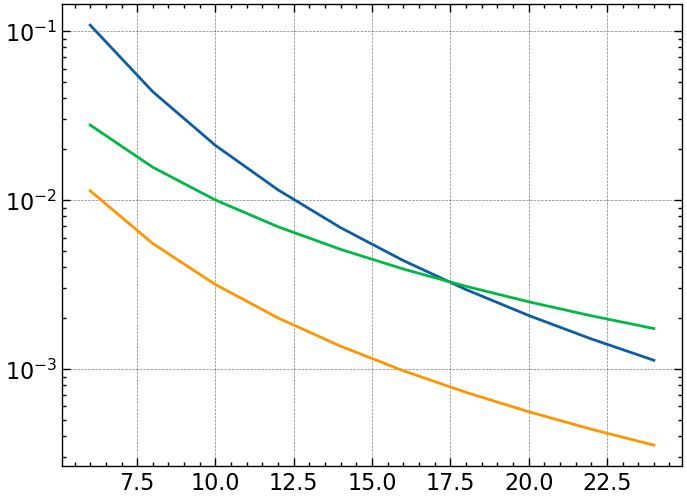

In [25]:
site = [2*(n+1) for n in range(2,12)]
gap_1 = [L**(-2) for L in site]
gap_2 = [L**(-5/2) for L in site]
gap_3 = [L**(-15/2) for L in site]

plt.plot(site, Fredkin_first_excited_energy)
#plt.plot(site, Fredkin_ground_state_energy)
plt.plot(site,gap_1)
plt.plot(site, gap_2)
#plt.plot(site,gap_3)
#plt.xscale('log')
plt.yscale('log')

In [23]:
site = [2*(n+1) for n in range(2,12)]
print(site)

[6, 8, 10, 12, 14, 16, 18, 20, 22, 24]


In [26]:
print(Fredkin_first_excited_energy)

[0.10838334458731401, 0.043732974019830485, 0.02104350768652077, 0.011479199966565897, 0.0068562645329514876, 0.0043829558092608085, 0.002953017316850207, 0.002074409932529411, 0.0015074858268572917, 0.0011266921303492163]


In [45]:
#Fredkin_first_excited_energy_with size
chain_size = [6, 8, 10, 12, 14, 16, 18, 20, 22, 24]
Fredkin_first_excited_energy_with_size = [0.10838334458731401, 0.043732974019830485, 0.02104350768652077, 0.011479199966565897, 0.0068562645329514876, 0.0043829558092608085, 0.002953017316850207, 0.002074409932529411, 0.0015074858268572917, 0.0011266921303492163]

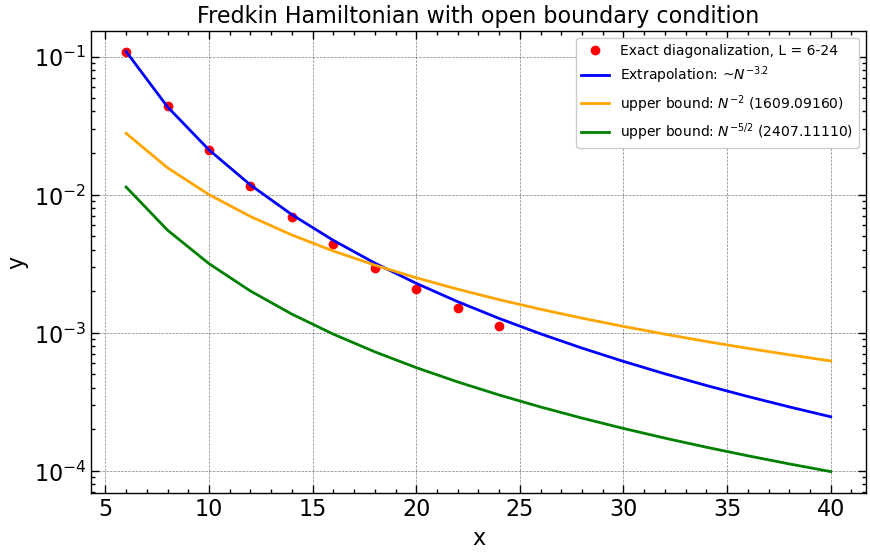

Fitted parameters: a = 34.08845114316654, b = -3.2088859721963403


In [44]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Given data
x = np.array([6, 8, 10, 12, 14, 16, 18, 20, 22, 24])
y = np.array([0.10838334458731401, 0.043732974019830485, 0.02104350768652077, 
              0.011479199966565897, 0.0068562645329514876, 0.0043829558092608085, 
              0.002953017316850207, 0.002074409932529411, 0.0015074858268572917, 
              0.0011266921303492163])

# Define an exponential function to fit the data
def func(x, a, b):
    return a*x**b

# Fit the curve
params, covariance = curve_fit(func, x, y)

# Get the parameters
a, b = params

# Generate a range of x values for extrapolation
x_extrapolate = np.array([2*(n+1) for n in range(2,20)])
y_extrapolate = func(x_extrapolate, a, b)

site = [2*(n+1) for n in range(2,20)]
gap_1 = [L**(-2) for L in site]
gap_2 = [L**(-5/2) for L in site]


# Plotting the results
plt.figure(figsize=(10, 6))
plt.scatter(x, y, label='Exact diagonalization, L = 6-24', color='red')
#plt.plot(site, Fredkin_first_excited_energy)

plt.plot(x_extrapolate, y_extrapolate, label='Extrapolation: ~$N^{-3.2}$', color='blue')
plt.plot(x_extrapolate, gap_1, label = 'upper bound: $N^{-2}$ (1609.09160)', color = 'orange')
plt.plot(x_extrapolate, gap_2, label = 'upper bound: $N^{-5/2}$ (2407.11110)', color = 'green')


#plt.axvline(x=500, color='green', linestyle='--', label='x=500')
plt.yscale('log')  # Using log scale to better visualize the decay
plt.xlabel('x')
plt.ylabel('y')
plt.legend(fontsize = 10, loc='upper right')
plt.title('Fredkin Hamiltonian with open boundary condition')
plt.show()

# Output the parameters
print(f"Fitted parameters: a = {a}, b = {b}")


In [11]:
FredkinHamPBC_1 = Fredkin_Ham_PBC_0(10,0,10)
FredkinHamPBC_2 = Fredkin_Ham_PBC(10)



Hermiticity check passed!
Hermiticity check passed!


In [12]:
egv_1, egvec_1 = FredkinHamPBC_1.eigh()
egv_2, egvec_2 = FredkinHamPBC_2.eigh()
print(egv_1[0:20])
print(egv_2[0:20])

[-1.61278255e-16 -1.39575760e-16 -1.13954191e-16  0.00000000e+00
  0.00000000e+00  1.48676159e-16  2.89095266e-16  5.29384640e-16
  7.18221878e-16  7.26075800e-16  8.88178420e-16  1.36970142e-15
  5.06934033e-02  5.06934033e-02  7.98030440e-02  7.98030440e-02
  7.98030440e-02  7.98030440e-02  8.86055492e-02  8.86055492e-02]
[-1.61278255e-16 -1.39575760e-16 -1.13954191e-16  0.00000000e+00
  0.00000000e+00  1.48676159e-16  2.89095266e-16  5.29384640e-16
  7.18221878e-16  7.26075800e-16  8.88178420e-16  1.36970142e-15
  5.06934033e-02  5.06934033e-02  7.98030440e-02  7.98030440e-02
  7.98030440e-02  7.98030440e-02  8.86055492e-02  8.86055492e-02]


In [16]:
egv_1[12]

0.050693403326492484

In [19]:
Nz = 14
egvs, egvecs = Fredkin_Ham_PBC(Nz).eigsh(k=Nz+3,which = 'SA')
egvs[Nz+2]

Hermiticity check passed!


0.014620711359113983

In [13]:
FredkinHamPBCZeroMag = Fredkin_Ham_PBC_zero_mag(10)
egvalp, egvecp = FredkinHamPBCZeroMag.eigh()
print(egvalp[0:20])

Hermiticity check passed!
Particle conservation check passed!
[-2.04083027e-17  8.43109573e-16  8.86055492e-02  8.86055492e-02
  8.86055492e-02  8.86055492e-02  1.50168686e-01  1.50168686e-01
  1.50168686e-01  1.50168686e-01  1.51044417e-01  1.51044417e-01
  3.00673868e-01  3.00673868e-01  3.00673868e-01  3.00673868e-01
  3.27657871e-01  3.27657871e-01  4.52452511e-01  4.52452511e-01]


In [ ]:
Fredkin_first_excited_energy_PBC = []

for n in range(2,10):
    L = 2*(n+1)
    FredkinHamt_PBC0 = Fredkin_Ham_PBC(L)
    if L <= 12:
        egv_b, egvec_b = FredkinHamt_PBC0.eigh()
    if L > 12:
        egv_b, egvec_b = FredkinHamt_PBC0.eigsh(k = L+3, which = 'SA')
    En1_b = egv_b[L+2]
    Fredkin_first_excited_energy_PBC.append(En1_b)

Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!


In [ ]:
print(Fredkin_first_excited_energy_PBC)

In [201]:
Fredkin_ground_state_energy_PBC_zeroMag = []
Fredkin_first_excited_energy_PBC_zeroMag = []

for n in range(2,12):
    L=2*(n+1)
    FredkinHamt_pbc = Fredkin_Ham_PBC_zero_mag(L)
    if L <= 12:
        egval_L_pbc, egvec_L_pbc = FredkinHamt_pbc.eigh()
    if L > 12:
        egval_L_pbc, egvec_L_pbc = FredkinHamt_pbc.eigsh(k = 3, which = 'SA')
    En0_pbc = egval_L_pbc[0]
    En1_pbc = egval_L_pbc[2]
    Fredkin_ground_state_energy_PBC_zeroMag.append(En0_pbc)
    Fredkin_first_excited_energy_PBC_zeroMag.append(En1_pbc)

Hermiticity check passed!
Particle conservation check passed!
Hermiticity check passed!
Particle conservation check passed!
Hermiticity check passed!
Particle conservation check passed!
Hermiticity check passed!
Particle conservation check passed!
Hermiticity check passed!
Particle conservation check passed!
Hermiticity check passed!
Particle conservation check passed!
Hermiticity check passed!
Particle conservation check passed!
Hermiticity check passed!
Particle conservation check passed!
Hermiticity check passed!
Particle conservation check passed!
Hermiticity check passed!
Particle conservation check passed!


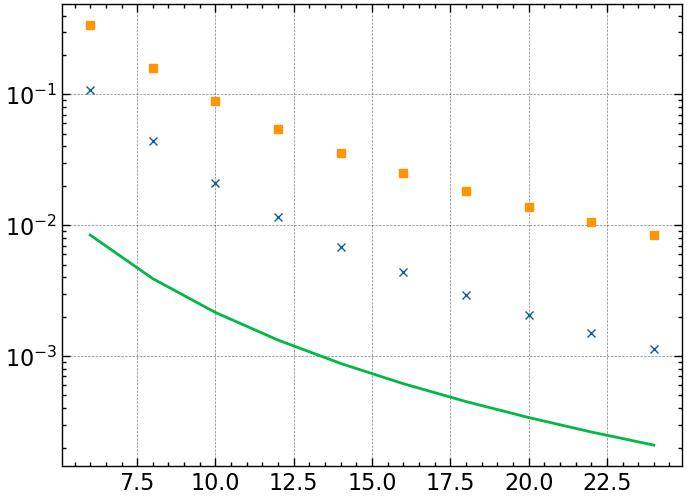

In [210]:
site0 = [2*(n+1) for n in range(2,12)]
gp = [L**(-8/3) for L in site0]
plt.plot(site0, Fredkin_first_excited_energy,'x')

plt.plot(site0,gp)
plt.plot(site0, Fredkin_first_excited_energy_PBC_zeroMag,'s')
plt.yscale('log')

In [9]:
domain_observable = np.inner(np.transpose(np.conjugate(initial_state)),domainwallobservable(N).dot(initial_state))

Hermiticity check passed!


In [10]:
print(domain_observable)

0.5


In [30]:
file_name = 'Fredkin_spectrum_N14-2.txt'
with open(file_name, "w") as file:
    file.write("")

for i in range(len(egval)):
    z1 = str(egval[i])
    lst = egvec[:,i]
    z2 = '[' + ','.join(map(str, lst)) + ']'
    z3 = z1 + ' ' + z2
    with open(file_name, "a") as file:
        file.write(z3 + '\n')
        file.flush()

In [21]:
egval1, egvec1 = HamXXX_ferro.eigh()

In [22]:
ovlap_scar = []
for i in range(len(egval)):
    ovlap_scar_0 = abs(np.inner(np.conjugate(np.transpose(egvec[:,i])),initial_state))
    #ovlap_scar_1 = np.log(ovlap_scar_0)
    ovlap_scar.append(ovlap_scar_0)
    
ovlap_scar1 = []
for i in range(len(egval1)):
    ovlap_scar_01 = abs(np.inner(np.conjugate(np.transpose(egvec1[:,i])),initial_state))
    #ovlap_scar_1 = np.log(ovlap_scar_0)
    ovlap_scar1.append(ovlap_scar_01)
    

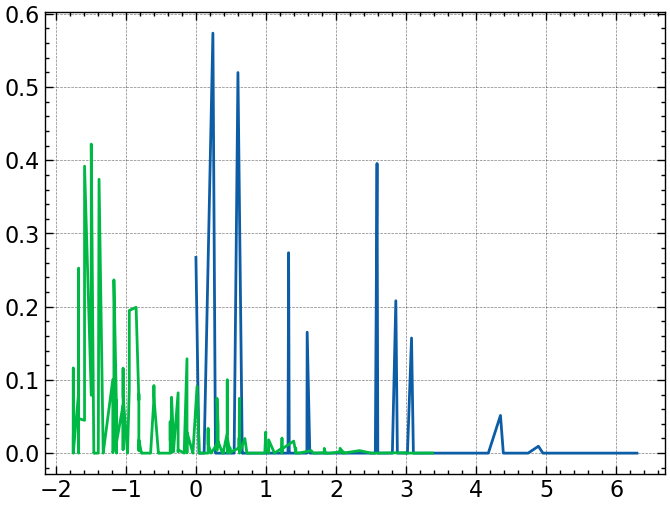

In [23]:
plt.plot(egval,ovlap_scar)
plt.plot(egval1,ovlap_scar1)

In [33]:
alpha = 1.0

spinsiteA = leftblock(N)

Sentlist = []
pAlist = []

#Sentlist1 = []
#pAlist1 = []

for i in range(len(egval)):
    S_ent_1 = basis.ent_entropy(egvec[:,i],sub_sys_A=spinsiteA,density = False,return_rdm="A",enforce_pure=False,return_rdm_EVs=True,sparse=True,alpha=alpha,sparse_diag=True,subsys_ordering=True)
    S_ent_f_1 = float(S_ent_1['Sent_A'])
    P_sub_A0 = S_ent_1['p_A']
    P_sub_A = [float(P_sub_A0[i]) for i in range(len(P_sub_A0))]
    Sentlist.append(S_ent_f_1)
    pAlist.append(P_sub_A)
    #S_ent_11 = basis.ent_entropy(egvec1[:,i],sub_sys_A=spinsiteA,density = False,return_rdm="A",enforce_pure=False,return_rdm_EVs=True,sparse=True,alpha=alpha,sparse_diag=True,subsys_ordering=True)
    #S_ent_f_11 = float(S_ent_11['Sent_A'])
    #P_sub_A01 = S_ent_11['p_A']
    #P_sub_A1 = [float(P_sub_A01[i]) for i in range(len(P_sub_A01))]
    #Sentlist1.append(S_ent_f_11)
    #pAlist1.append(P_sub_A1)

[8, 9, 27, 28, 92, 93, 94, 96, 97, 98, 99]
[0.3333325899602766, 0.33333258996027926, 1.0, 1.0, 2.0, 2.0, 2.0, 2.000000000000001, 2.000000000000001, 2.0000000000000013, 2.0000000000000027]


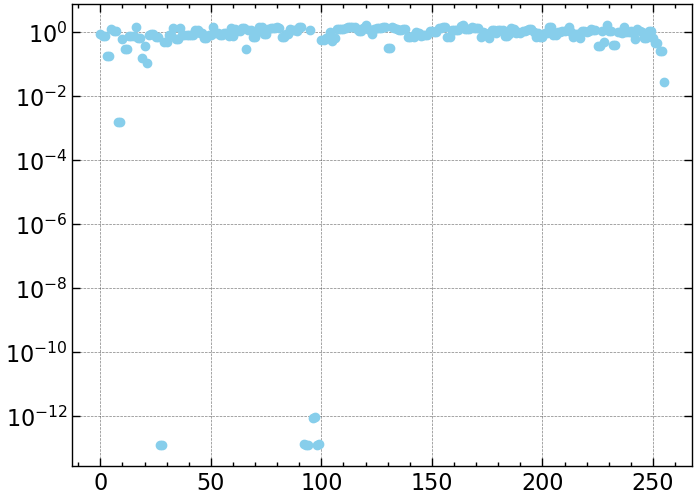

In [35]:
pos1 = []
for i in range(len(egval)):
    if Sentlist[i]<1e-2:
        pos1.append(i)
print(pos1)

enpos = []

for i in pos1:
    enpos.append(egval[i])
print(enpos)

#plt.plot(egval,Sentlist,'o',color='skyblue')
plt.plot(Sentlist,'o',color='skyblue')

#plt.plot(Sentlist1,'o',color='orange')
#plt.xscale('log')
plt.yscale('log')    

In [11]:
alpha = 1.0

t = 5.0

spinsiteA = leftblock(N)
spinsiteB = centralblock(N)

evolved_state = np.squeeze(np.transpose(evol_op(FredkinHam,1.0,t,t,1).dot(initial_state)))

S_ent_A = basis.ent_entropy(evolved_state,sub_sys_A=spinsiteA,density = False,return_rdm="A",enforce_pure=False,return_rdm_EVs=True,sparse=True,alpha=alpha,sparse_diag=True,subsys_ordering=True)
#S_ent_B = basis.ent_entropy(evolved_state,sub_sys_A=spinsiteB,density = False,return_rdm="A",enforce_pure=False,return_rdm_EVs=False,sparse=True,alpha=alpha,sparse_diag=True,subsys_ordering=True)

S_ent_fA = float(S_ent_A['Sent_A'])
#S_ent_fB = float(S_ent_B['Sent_A'])

print(S_ent_fA)
#print(S_ent_fB)

P_val_A = S_ent_A['p_A']

#P_val_A_n = []
#for i in P_val_A:
#    P_val_A_n.append(float(i))
    
#P_val_A_n1 = [float(P_val_A[i]) for i in range(len(P_val_A))]

#print(P_val_A_n1)


1.1445935633252982


In [15]:
print(len(P_val_A))
print(2**10)
print(P_val_A[1])

1024
1024
0.17296323927904364


In [39]:
Lnn = P_val_A_n
Lnt = str(Lnn)

cq = '1' + ' ' + '2' + ' ' + Lnt

# writing to file
file1 = open('myfile.txt', 'w')
file1.writelines(cq)
file1.close()


In [7]:
import csv

# Initialize lists to store the data
fredkin_N8_egval = []
fredkin_N8_egvec = []

# Read the txt file
with open('Fredkin_spectrum_N14-2.txt', 'r') as file:
    reader = csv.reader(file, delimiter=' ')
    for row in reader:
        # Assuming the first column is a number
        fredkin_N8_egval.append(float(row[0]))
        # Assuming the second column is a string representation of a list
        fredkin_N8_egvec.append(eval(row[1]))


In [8]:
fredkin_N10_egval = []
fredkin_N10_egvec = []

# Read the txt file
with open('Fredkin_spectrum_N10-1.txt', 'r') as file:
    reader = csv.reader(file, delimiter=' ')
    for row in reader:
        # Assuming the first column is a number
        fredkin_N10_egval.append(float(row[0]))
        # Assuming the second column is a string representation of a list
        fredkin_N10_egvec.append(eval(row[1]))


In [38]:
fredkin_N12_egval = []
fredkin_N12_egvec = []

# Read the txt file
with open('Fredkin_spectrum_N12-1.txt', 'r') as file:
    reader = csv.reader(file, delimiter=' ')
    for row in reader:
        # Assuming the first column is a number
        fredkin_N12_egval.append(float(row[0]))
        # Assuming the second column is a string representation of a list
        fredkin_N12_egvec.append(eval(row[1]))


In [32]:
import csv
csv.field_size_limit(sys.maxsize)

# Initialize lists to store the data
fredkin_N14_egval = []
fredkin_N14_egvec = []

# Read the txt file
with open('Fredkin_spectrum_N14-2.txt', 'r') as file:
    reader = csv.reader(file, delimiter=' ')
    for row in reader:
        # Assuming the first column is a number
        fredkin_N14_egval.append(float(row[0]))
        # Assuming the second column is a string representation of a list
        fredkin_N14_egvec.append(eval(row[1]))


In [34]:
print(len(fredkin_N14_egvec[0]))
print(2**14)

16384
16384


In [10]:
# Initialize lists to store the data
fredkin_N14_egval = []
fredkin_N14_egvec = []
#list2 = []

def parse_list(list_str):
    # Remove brackets and split by space
    return list(map(float, list_str.strip('[]').split()))

# Read the txt file
with open('Fredkin_spectrum_N14-1.txt', 'r') as file:
    reader = csv.reader(file, delimiter=' ')
    for row in reader:
        try:
            # Assuming the first column is a number
            number = float(row[0])
            fredkin_N14_egval.append(number)
            
            # Assuming the second and third columns are lists without commas
            fredkin_N14_egvec.append(parse_list(row[1]))
            #list2.append(parse_list(row[2]))
        
        except (ValueError, IndexError) as e:
            print(f"Error parsing row {row}: {e}")
            continue

#print("Numbers:", numbers)
#print("List1:", list1)
#print("List2:", list2)


In [42]:
alpha = 1.0
n = 14

spinsiteA = leftblock(n)
basis = spin_basis_1d(n,S='1/2',pauli=0)

Sentlist_14 = []
pAlist_14 = []

#Sentlist1 = []
#pAlist1 = []

for i in range(len(fredkin_N14_egval)):
    S_ent_1 = basis.ent_entropy(fredkin_N14_egvec[i],sub_sys_A=spinsiteA,density = False,return_rdm="A",enforce_pure=False,return_rdm_EVs=True,sparse=True,alpha=alpha,sparse_diag=True,subsys_ordering=True)
    S_ent_f_1 = float(S_ent_1['Sent_A'])
    P_sub_A0 = S_ent_1['p_A']
    P_sub_A = [float(P_sub_A0[i]) for i in range(len(P_sub_A0))]
    Sentlist_14.append(S_ent_f_1)
    pAlist_14.append(P_sub_A)

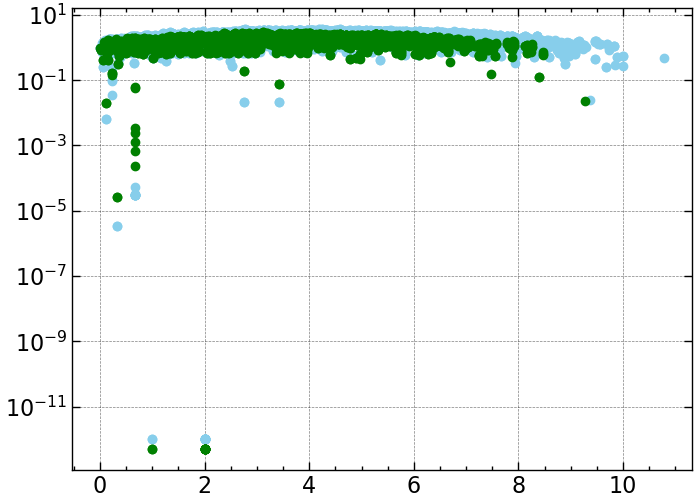

In [44]:
plt.plot(fredkin_N14_egval,Sentlist_14,'o',color='skyblue')
#plt.plot(fredkin_N10_egval,Sentlist_10,'o',color='orange')
plt.plot(fredkin_N12_egval,Sentlist_12,'o',color='green')


#plt.plot(Sentlist1,'o',color='orange')
#plt.xscale('log')
plt.yscale('log')    

In [34]:
print(Sentlist_8[0],Sentlist_10[0],Sentlist_12[0])

0.8304717124363975 0.7654478283421386 0.9669369773453552


In [19]:
Op1 = spinopz(N,N//2)
Ham = FredkinHam

t = 0.01
Nstep = 2000

evolved_state = initial_state

filename = "Fredkin-pert_GS_corr_zz-N20_dt0p01_t20.txt"

with open(filename, "w") as file:
        file.write("")

for step in range(Nstep):
        evolved_state = np.squeeze(np.transpose(evol_op(Ham,1.0,t,t,1).dot(evolved_state)))
        tmm = t*(step+1)
        for i in range(N):
            Opi = spinopz(N,i)
            psi_1 = Op1.dot(evolved_state)
            psi_2 = Opi.dot(evolved_state)
            psi_21 = Opi.dot(psi_1)
            ovlap1 = np.real(np.inner(np.conjugate(np.transpose(evolved_state)),psi_1))
            ovlap2 = np.real(np.inner(np.conjugate(np.transpose(evolved_state)),psi_2))
            ovlap21 = np.real(np.inner(np.conjugate(np.transpose(evolved_state)),psi_21))
            ovlap_fin = ovlap21 - ovlap2*ovlap1
            c1 = str(tmm)
            c2 = str(i)
            c3 = str(ovlap_fin)
            c4 = c1 +' '+ c2 +' '+ c3
            with open(filename, "a") as file:
                file.write(c4 + '\n')
                file.flush()

In [28]:
#dynamical correlation check
Op1 = spinopz(N,N//2)
Ham = FredkinHam

t = 0.1
Nstep = 5000

evolved_state = Op1.dot(GS)

filename = "Fredkin-dynamical_corr_zz_i_5-N12_dt0p01_t500.txt"

with open(filename, "w") as file:
        file.write("")

for step in range(Nstep):
        evolved_state = np.squeeze(np.transpose(evol_op(Ham,1.0,t,t,1).dot(evolved_state)))
        tmm = t*(step+1)
        for i in range(N):
            Opi = spinopz(N,i)
            psi = Opi.dot(evolved_state)
            ovlap = np.real(np.inner(np.conjugate(np.transpose(GS)),psi))
            c1 = str(tmm)
            c2 = str(i)
            c3 = str(ovlap)
            c4 = c1 +' '+ c2 +' '+ c3
            with open(filename, "a") as file:
                file.write(c4 + '\n')
                file.flush()

Text(0, 0.5, 'time, t')

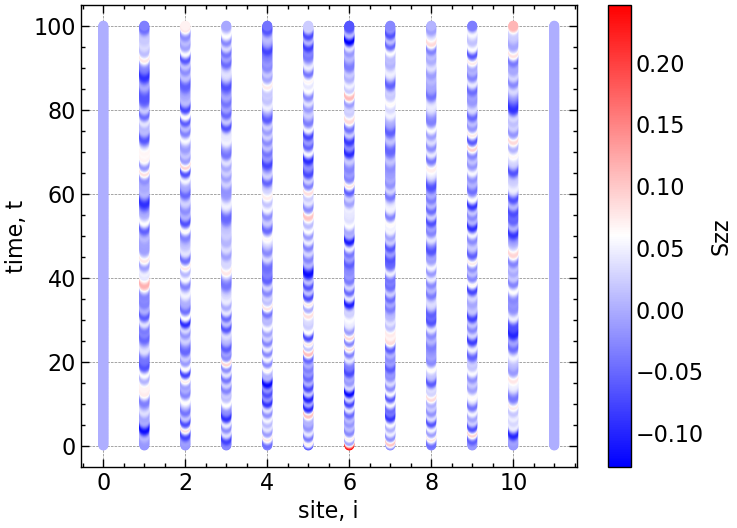

In [30]:
spinzz = np.loadtxt('Fredkin-dynamical_corr_zz_i_5-N12_dt0p01_t500.txt')

tzz = spinzz[:,0]
xzz = spinzz[:,1]
szz = spinzz[:,2]

tzz1 =[]
xzz1 = []
szz1= []

for i in range(len(tzz)):
    if tzz[i] <= 100.0:
        tzz1.append(tzz[i])
        xzz1.append(xzz[i])
        szz1.append(szz[i])

scatter = plt.scatter(xzz1, tzz1, c=szz1, cmap='bwr')
plt.colorbar(scatter, label='Szz')
plt.xlabel('site, i')
plt.ylabel('time, t')

In [9]:
#spinsite_1 = [8, 9, 10]

#spinsite_1 = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

spinsite_1 = leftblock(N)
spinsite_2 = centralblock(N)
print(spinsite_1)
print(spinsite_2)


#spinsite_1 = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
#spinsite_2 = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

[0, 1, 2, 3, 4, 5]
[3, 4, 5, 6, 7, 8]


In [10]:
#timelist = ntt
Hamtt = FredkinHam
spinsitec = spinsite_1
t = 0.1
Nstep = 500
alpha = 2.0
filename = "Fredkin_Renyi_DW_N12_Left_L6_t50_dt0p1.txt"
evolved_state = initial_state
#evolved_state = np.squeeze(np.transpose(evol_op(FredkinHam,1.0,7.0,7.0,1).dot(initial_state)))
with open(filename, "w") as file:
    file.write("")

for step in range(Nstep):
    evolved_state = np.squeeze(np.transpose(evol_op(Hamtt,1.0,t,t,1).dot(evolved_state)))
    #ovlapin = (1/N)*np.log(abs(np.inner(np.conjugate(np.transpose(evolved_state)),initial_state))**2)
    S_ent_1 = basis.ent_entropy(evolved_state,sub_sys_A=spinsitec,density = False,return_rdm="A",enforce_pure=False,return_rdm_EVs=True,sparse=True,alpha=alpha,sparse_diag=True,subsys_ordering=True)
    S_ent_f_1 = float(S_ent_1['Sent_A'])
#    P_sub_A0 = S_ent_1['p_A']
#    P_sub_A = [float(P_sub_A0[i]) for i in range(len(P_sub_A0))]
    tmm = t*(step+1)
    c1 = str(tmm)                  
    c2 = str(S_ent_f_1)
    c3 = c1 +' '+ c2

#    c3 = str(P_sub_A)
#    c4 = c1 +' '+ c2 + ' '+ c3
    
    with open(filename, "a") as file:
        file.write(c3 + '\n')
        file.flush()

In [25]:
#Domain-wall observable
#timelist = ntt
Hamtt = FredkinHam
#Hamtt = HamXXX_ferro
t = 0.1
Nstep = 500
filename = "Fredkin_DW_N12_domain_wall_number_t50_dt0p1.txt"
evolved_state = initial_state
obs_op = domainwallnumber(N)

tlist = []
expval_list = []
#evolved_state = np.squeeze(np.transpose(evol_op(FredkinHam,1.0,7.0,7.0,1).dot(initial_state)))
with open(filename, "w") as file:
    file.write("")

for step in range(Nstep):
    evolved_state = np.squeeze(np.transpose(evol_op(Hamtt,1.0,t,t,1).dot(evolved_state)))
    expval = 0.5*np.inner(np.conjugate(np.transpose(evolved_state)),obs_op.dot(evolved_state))
    tmm = t*(step+1)
    tlist.append(tmm)
    expval_list.append(expval)
    c1 = str(tmm)                  
    c2 = str(expval)
    c3 = c1 +' '+ c2
    
    with open(filename, "a") as file:
        file.write(c3 + '\n')
        file.flush()

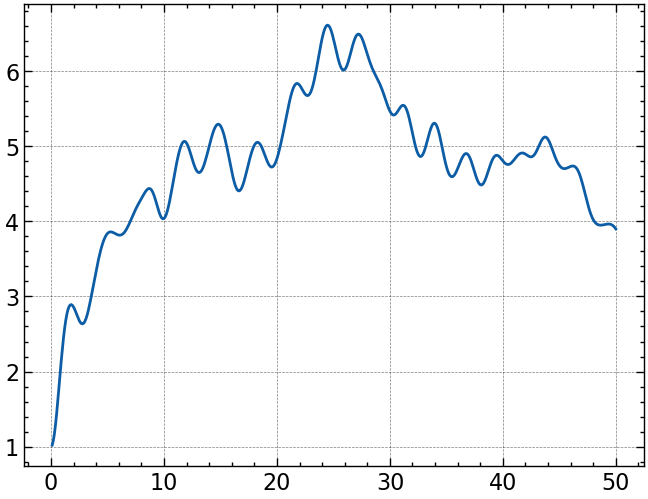

In [26]:
plt.plot(tlist,np.real(expval_list))

In [29]:
print(np.real(expval_list).tolist())

[0.4983409547143197, 0.4934544401738295, 0.4856061414281495, 0.47521879228310404, 0.46284383263580325, 0.4491250706856128, 0.4347572608229011, 0.42044278988222483, 0.4068496380396951, 0.39457347188846836, 0.38410619372589777, 0.3758125914434378, 0.36991599433670813, 0.366493123503167, 0.36547769744361314, 0.36667185745283704, 0.36976413154956345, 0.37435245501607856, 0.379970687526472, 0.38611707914242677, 0.39228320670525396, 0.39798200088892516, 0.4027735956999897, 0.40628785222635244, 0.408242543553834, 0.4084563514057922, 0.40685603185882246, 0.40347736751636765, 0.39845983754878445, 0.3920352938344315, 0.38451130785504306, 0.3762502163858006, 0.36764520704700177, 0.3590950113333968, 0.3509788838882621, 0.3436335257372183, 0.3373334542051013, 0.33227604711663794, 0.3285721209586566, 0.32624247873168405, 0.3252204241373744, 0.32535982398840674, 0.326447943475207, 0.3282220027786119, 0.3303882210891972, 0.3326420275119929, 0.3346881212858943, 0.33625914438764193, 0.3371318735891877, 

In [103]:
site_test = []
l0 = [9]
site_test = [l0]

l1 = l0
l2 = l0
for site in range(8,-1,-1):
    site1 = 18-site
    l1 = [site]+l1
    l2 = l2+[site1]
    l1s = set(l1)
    l2s = set(l2)
    l3s = l1s.union(l2s)
    l3 = list(l3s)
    

    #site_test.append(l3)
    print(l1, l2, l3)

[8, 9] [9, 10] [8, 9, 10]
[7, 8, 9] [9, 10, 11] [7, 8, 9, 10, 11]
[6, 7, 8, 9] [9, 10, 11, 12] [6, 7, 8, 9, 10, 11, 12]
[5, 6, 7, 8, 9] [9, 10, 11, 12, 13] [5, 6, 7, 8, 9, 10, 11, 12, 13]
[4, 5, 6, 7, 8, 9] [9, 10, 11, 12, 13, 14] [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
[3, 4, 5, 6, 7, 8, 9] [9, 10, 11, 12, 13, 14, 15] [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
[2, 3, 4, 5, 6, 7, 8, 9] [9, 10, 11, 12, 13, 14, 15, 16] [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
[1, 2, 3, 4, 5, 6, 7, 8, 9] [9, 10, 11, 12, 13, 14, 15, 16, 17] [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9] [9, 10, 11, 12, 13, 14, 15, 16, 17, 18] [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]


In [51]:
#timelist = ntt
Hamtt = HamXXX_ferro
t = 0.1
Nstep = 500
alpha = 1.0
filename = "XXX_ferro_vN_Neel_N20_spatial_temporal_wrt_midpoint_site_t50_dt0p1-new.txt"
evolved_state = initial_state
#evolved_state = np.squeeze(np.transpose(evol_op(FredkinHam,1.0,43.9,43.9,1).dot(initial_state)))
with open(filename, "w") as file:
    file.write("")
    for step in range(Nstep):
        evolved_state = np.squeeze(np.transpose(evol_op(Hamtt,1.0,t,t,1).dot(evolved_state)))
        site_ent = []
        for spinsitex in site_test:
            S_ent_x = basis.ent_entropy(evolved_state,sub_sys_A=spinsitex,density = False,return_rdm="A",enforce_pure=False,return_rdm_EVs=False,sparse=True,alpha=alpha,sparse_diag=True,subsys_ordering=True)
            S_ent_f_x = float(S_ent_x['Sent_A'])
            site_ent.append([spinsitex,S_ent_f_x])
        tmm = t*(step+1)
        c4 = {'time': tmm, 'site_ent': site_ent}
        file.write(json.dumps(c4) + '\n')
        file.flush()

/global/homes/t/talal/.conda/envs/quspin/lib/python3.10/site-packages/quspin/basis/lattice.py:440: RuntimeWarning: invalid value encountered in log
  Sent_A = - _np.nansum((p_A * _np.log(p_A)),axis=-1)
/global/homes/t/talal/.conda/envs/quspin/lib/python3.10/site-packages/quspin/basis/lattice.py:443: RuntimeWarning: invalid value encountered in log
  Sent_B = - _np.nansum((p_B * _np.log(p_B)),axis=-1)


In [ ]:
#OTOC calculation with respect to the mixed state
#timelist = ntt
Hamtt = FredkinHam
dt = 0.1
Nstep = 500
psi = domainwallnew(N)

filename = "Fredkin_DW_OTOC_ZZ_N20_t50_dt0p1_site_1-19.txt"

with open(filename, "w") as file:
    file.write("")
    for step in range(Nstep):
        t = dt*(step+1)
        otoc_chain = []
        for site in range(1,N-1):
            otoc_site = np.real(OTOC_full(FredkinHam, spinopz_pauli(N,1),spinopz_pauli(N,site),t,psi))
            otoc_chain.append(otoc_site)
        c4 = {'time': t, 'otoc_chain': otoc_chain}
        file.write(json.dumps(c4) + '\n')
        file.flush()

In [10]:
# von Neuman Renyi left-block central block
#file_1: time | von Neumann left | von Neumann central
#file_2: time | left singular value
#file_3: time | central singular value
#timelist = ntt
Hamtt = FredkinHam
spinsitec = spinsite_1
spinsited = spinsite_2

t = 0.1
Nstep = 500
alpha = 2.0

filename_1 = "Fredkin_Renyi_DW_N20_Left_L10_Central_C10_dt0p1_t50.txt"
#filename_2 = "XXX_ferro_random_product_N20_Left_L10_sing_val_dt0p1_t50.txt"
#filename_3 = "XXX_ferro_random_product_N20_Central_C10_sing_val_dt0p1_t50.txt"

evolved_state = initial_state
#evolved_state = np.squeeze(np.transpose(evol_op(FredkinHam,1.0,7.0,7.0,1).dot(initial_state)))
with open(filename_1, "w") as file_1:

#with open(filename_1, "w") as file_1, open(filename_2, "w") as file_2, open(filename_3, "w") as file_3:
    for step in range(Nstep):
        evolved_state = np.squeeze(np.transpose(evol_op(Hamtt,1.0,t,t,1).dot(evolved_state)))
        S_ent_1 = basis.ent_entropy(evolved_state, sub_sys_A=spinsitec, density=False, return_rdm="A", enforce_pure=False, return_rdm_EVs=False, sparse=True, alpha=alpha, sparse_diag=True, subsys_ordering=True)
        S_ent_2 = basis.ent_entropy(evolved_state, sub_sys_A=spinsited, density=False, return_rdm="A", enforce_pure=False, return_rdm_EVs=False, sparse=True, alpha=alpha, sparse_diag=True, subsys_ordering=True)

        S_ent_f_1 = float(S_ent_1['Sent_A'])
        S_ent_f_2 = float(S_ent_2['Sent_A'])

        #P_sub_A0_1 = S_ent_1['p_A']
        #P_sub_A_1 = [float(P_sub_A0_1[i]) for i in range(len(P_sub_A0_1))]
        #P_sub_A0_2 = S_ent_2['p_A']
        #P_sub_A_2 = [float(P_sub_A0_2[i]) for i in range(len(P_sub_A0_2))]
        
        tmm = t * (step + 1)
        c3 = f"{tmm} {S_ent_f_1} {S_ent_f_2}"
        #c4 = {'time': tmm, 'sing_val': P_sub_A_1}
        #c5 = {'time': tmm, 'sing_val': P_sub_A_2}
        
        file_1.write(c3 + '\n')
        file_1.flush()

        #file_2.write(json.dumps(c4) + '\n')
        #file_2.flush()

        #file_3.write(json.dumps(c5) + '\n')
        #file_3.flush()

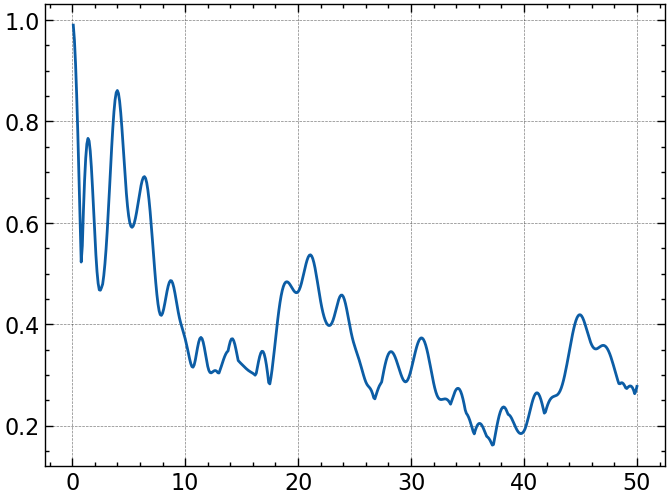

In [21]:
times = []
first_elements = []

# Open the file and read it line by line
with open('Fredkin_DW_N12_Left_L6_sing_val_dt0p1_t50.txt', 'r') as file:
    for line in file:
        # Parse the JSON data
        data = json.loads(line.strip())
        # Append the time and the first element of the list
        times.append(data['time'])
        first_elements.append(data['sing_val'][0])
plt.plot(times, first_elements)

In [12]:
def file_reader(key_1, key_2, filename, list_element_no):
    listname_1 = []
    listname_2 = []

    with open(filename, 'r') as file:
        for line in file:
            data = json.loads(line.strip())
            listname_1.append(data[key_1])
            listname_2.append(data[key_2][list_element_no])
    return listname_1, listname_2

def file_reader_full_list(key_1, key_2, filename):
    listname_1 = []
    listname_2 = []

    with open(filename, 'r') as file:
        for line in file:
            data = json.loads(line.strip())
            listname_1.append(data[key_1])
            listname_2.append(data[key_2])
    return listname_1, listname_2

In [21]:
file_nn_1, file_nn_2 = file_reader_full_list('time', 'site_ent', 'Fredkin_vN_Neel_N20_spatial_temporal_wrt_midpoint_site_t50_dt0p1-new.txt')
file_mm_1, file_mm_2 = file_reader_full_list('time', 'site_ent', 'XXX_ferro_vN_Neel_N20_spatial_temporal_wrt_midpoint_site_t50_dt0p1-new.txt')

In [22]:
file_nn_2r = [file_nn_2[i] for i in range(len(file_nn_2))]
file_nn_2q = [file_nn_2r[0][i][1] for i in range(len(file_nn_2r[0]))]

file_nn_2s = [[file_nn_2r[j][i][1] for i in range(len(file_nn_2[j]))] for j in range(len(file_nn_2))]

file_nn_2w = [[abs(file_nn_2s[j][0]-file_nn_2s[j][i+1]) for i in range(len(file_nn_2s[j])-1)] for j in range(len(file_nn_2s))]

In [23]:
file_mm_2r = [file_mm_2[i] for i in range(len(file_mm_2))]
file_mm_2q = [file_mm_2r[0][i][1] for i in range(len(file_mm_2r[0]))]

file_mm_2s = [[file_mm_2r[j][i][1] for i in range(len(file_mm_2[j]))] for j in range(len(file_mm_2))]

file_mm_2w = [[abs(file_mm_2s[j][0]-file_mm_2s[j][i+1]) for i in range(len(file_mm_2s[j])-1)] for j in range(len(file_mm_2s))]

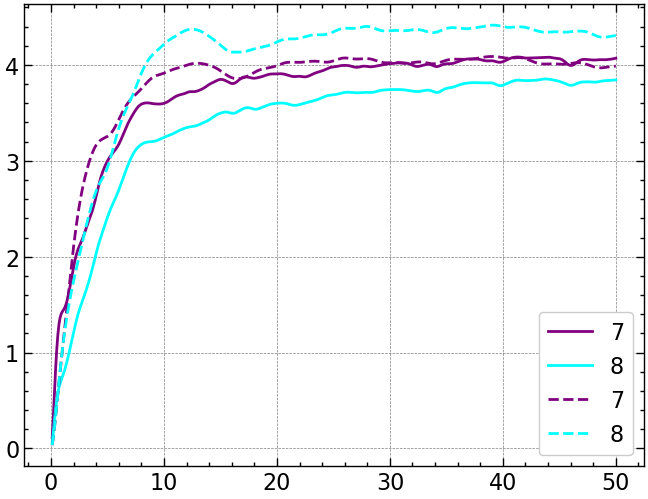

In [25]:
i = 7
j= 8
plt.plot(file_nn_1,np.array(file_nn_2s).T[i], color = colorl[i], label = f'{i}')
plt.plot(file_nn_1,np.array(file_nn_2s).T[j], color = colorl[j], label = f'{j}')
plt.plot(file_mm_1,np.array(file_mm_2s).T[i],'--', color = colorl[i], label = f'{i}')
plt.plot(file_mm_1,np.array(file_mm_2s).T[j],'--', color = colorl[j], label = f'{j}')
plt.legend(loc = 'lower right')



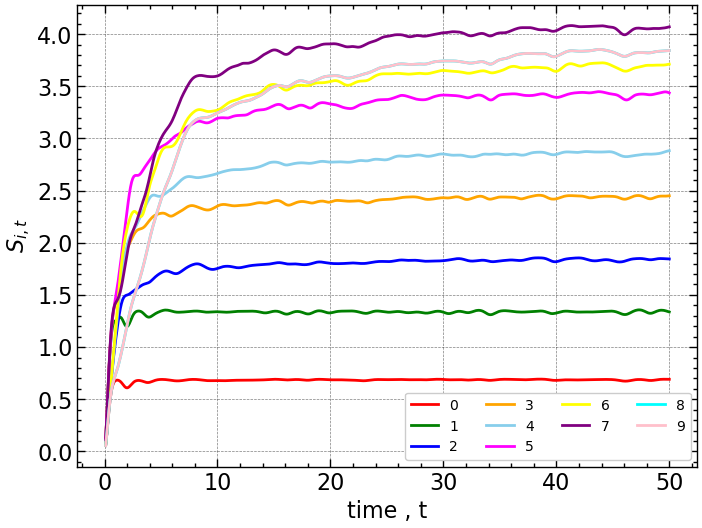

In [114]:
colorl = ['red', 'green', 'blue', 'orange', 'skyblue', 'magenta', 'yellow', 'purple', 'cyan', 'pink']
#for i in range(9):
#    if i%2 == 0:
#        plt.plot(file_nn_1[:30],np.array(file_nn_2s).T[i][:30], color = colorl[i], label = f'{i}')
l = 500
for i in range(10):
    plt.plot(file_nn_1[:l],np.array(file_nn_2s).T[i][:l], color = colorl[i], label = f'{i}')
plt.xlabel('time , t')
#plt.ylabel(r'$|S_{N/2+i}-S_{N/2}|$')
plt.ylabel(r'$S_{i,t}$')

plt.legend(ncol = 4, fontsize = 10, loc = 'lower right')

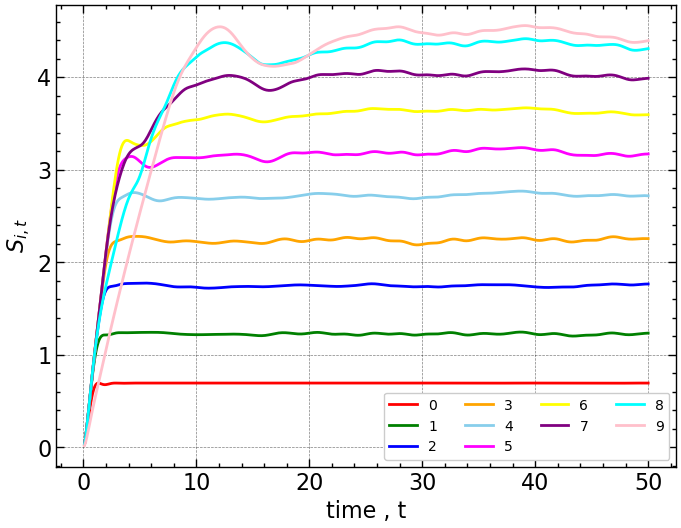

In [115]:
for i in range(10):
    plt.plot(file_mm_1[:l],np.array(file_mm_2s).T[i][:l], color = colorl[i], label = f'{i}')
plt.xlabel('time , t')
#plt.ylabel(r'$|S_{N/2+i}-S_{N/2}|$')
plt.ylabel(r'$S_{i,t}$')

plt.legend(ncol = 4, fontsize = 10, loc = 'lower right')

1.1268533735723953 -0.05676839943516698


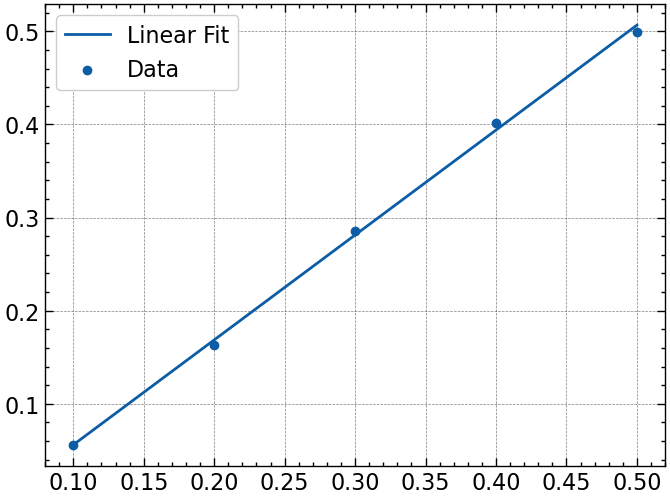

In [117]:
iz = 0
lz = 5
xt = np.array(file_nn_1)[:lz]
yt = np.array(file_nn_2s).T[iz][:lz]

slope, intercept, r_value, p_value, std_err = linregress(xt, yt)

# Define the linear function based on the fit
def f(x):
    return slope * x + intercept

print(slope, intercept)
# Plot
plt.plot(xt, f(xt), label="Linear Fit")
plt.scatter(xt, yt, label="Data")
plt.legend()
plt.show()

#print(yt)


#spline = UnivariateSpline(xt, yt, s=1)  # Adjust `s` for smoothness

#x_new = np.linspace(min(xt), max(xt), 100)  # Define a range of x values
#y_new = spline(x_new) 

# Plot
#plt.plot(xt, spline(xt), label="Spline Fit")
#plt.scatter(xt, yt, label="Data")
#plt.legend()
#plt.show()

In [123]:
N = 12
site_A = [i for i in range(N//2)]
site_B = [N//2+i for i in range(N//2)]
print(site_A)
print(site_B)

[0, 1, 2, 3, 4, 5]
[6, 7, 8, 9, 10, 11]


[1.18719686 1.21564843]
[ 1.12685337 -0.0567684 ]

41.96753337626171
59.58822354422729


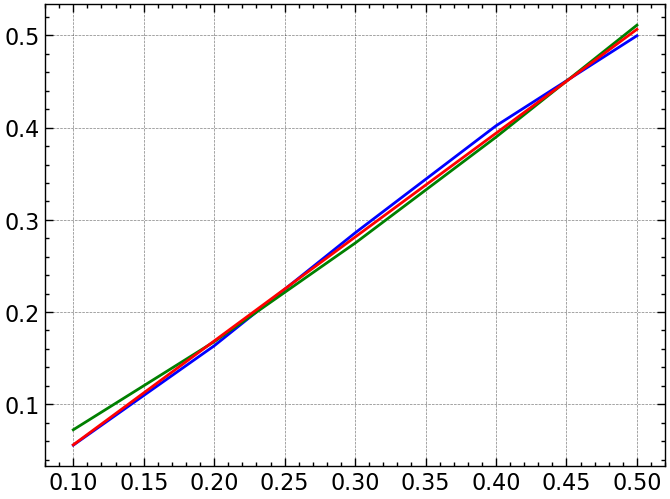

In [83]:
def func(t, a, b, c):
    return a*t+b*(t**c)

def func0(t, a, b):
    return a*(t**b)

def func1(t, a, b):
    return a*t+b

popt, pcov = curve_fit(func0, xt, yt)
popt1, pcov1 = curve_fit(func1, xt, yt)

print(popt)
print(popt1)
print()

print(np.linalg.cond(pcov))
print(np.linalg.cond(pcov1))


plt.plot(xt,yt,color = 'blue')
plt.plot(xt, func0(xt, *popt),'g-')
plt.plot(xt, func1(xt, *popt1), 'r-')

#plt.legend(loc = 'lower right')


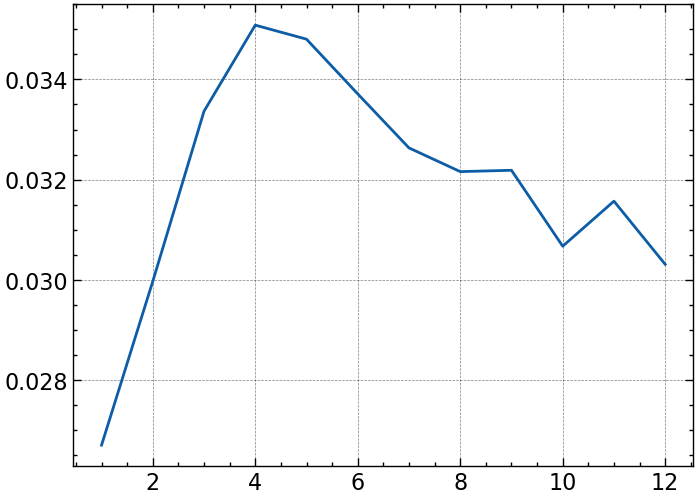

In [17]:
site = [i for i in range(1,N-1)]
plt.plot(site, np.flip(file_nn_2[90]))

In [78]:
fredkin_renyi = np.loadtxt('Fredkin_Renyi_test_N10.txt')
fredkin_renyi_y = fredkin_renyi[:,1]
print(fredkin_renyi_y)

[0.01990721 0.0784611  0.17175015 0.29191907 0.4254739  0.55235705
 0.64863688 0.69518802 0.68827261 0.64174934]


In [9]:
#Revival scar state and DQPT

#in_state = domainwallnew(N)
#in_state = twodomainwall(N,N//2)
#in_state = perturbed_up(N)
#in_state =neel(N)
Hamtt = FredkinHam
t = 0.1
Nstep = 300
filename = "Fredkin_n-DW_N20_fidality_dt0p1_t30.txt"
ev_DW_3 = DW_3
ev_DW_4 = DW_4
ev_DW_9 = DW_9
ev_DW_19 = DW_19
#evolved_state = np.squeeze(np.transpose(evol_op(FredkinHam,1.0,7.0,7.0,1).dot(initial_state)))
with open(filename, "w") as file:
    file.write("")

for step in range(Nstep):
    ev_DW_3 = np.squeeze(np.transpose(evol_op(Hamtt,1.0,t,t,1).dot(ev_DW_3)))
    ev_DW_4 = np.squeeze(np.transpose(evol_op(Hamtt,1.0,t,t,1).dot(ev_DW_4)))
    ev_DW_9 = np.squeeze(np.transpose(evol_op(Hamtt,1.0,t,t,1).dot(ev_DW_9)))
    ev_DW_19 = np.squeeze(np.transpose(evol_op(Hamtt,1.0,t,t,1).dot(ev_DW_19)))
    ovlap_3 = abs(np.inner(np.conjugate(np.transpose(ev_DW_3)),DW_3))**2
    ovlap_4 = abs(np.inner(np.conjugate(np.transpose(ev_DW_4)),DW_4))**2
    ovlap_9 = abs(np.inner(np.conjugate(np.transpose(ev_DW_9)),DW_9))**2
    ovlap_19 = abs(np.inner(np.conjugate(np.transpose(ev_DW_19)),DW_19))**2
    #ratefn = -(1/N)*np.log(ovlapin)
    tmm = t*(step+1)
    c1 = str(tmm)
    c2 = str(ovlap_3)
    c3 = str(ovlap_4)
    c4 = str(ovlap_9)
    c5 = str(ovlap_19)
    c6 = c1 + ' ' + c2 + ' ' + c3 +' '+ c4 +' '+ c5
    with open(filename, "a") as file:
        file.write(c6 + '\n')
        file.flush()

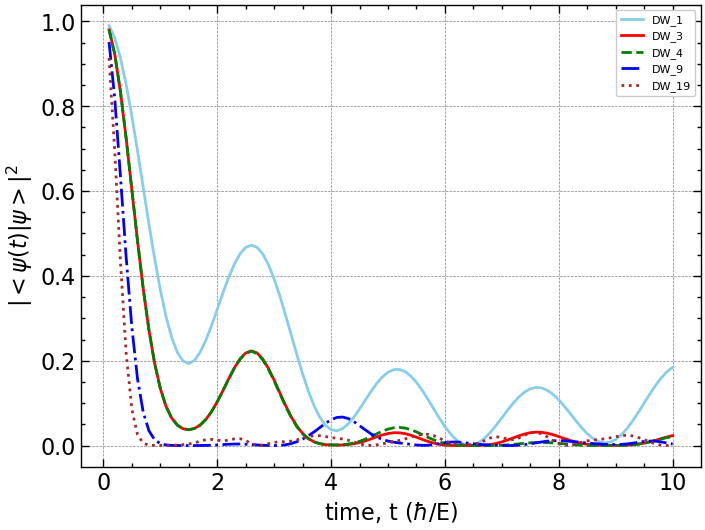

In [15]:
ovlp = np.loadtxt('Fredkin_n-DW_N20_fidality_dt0p1_t30.txt')
dqpt_fredkin_N20 = np.loadtxt('Fredkin_DW_N20_fidality_ratefn_dt0p1_t50.txt')
xdqpt = dqpt_fredkin_N20[:,0]
ydqpt = dqpt_fredkin_N20[:,1]

to = ovlp[:,0][:100]
dw3 = ovlp[:,1][:100]
dw4 = ovlp[:,2][:100]
dw9 = ovlp[:,3][:100]
dw19 = ovlp[:,4][:100]

plt.plot(xdqpt[:100],ydqpt[:100],color = 'skyblue', label = 'DW_1')
plt.plot(to,dw3,color = 'red', label = 'DW_3')
plt.plot(to,dw4,'--',color = 'green', label = 'DW_4')
plt.plot(to,dw9,'-.',color = 'blue', label = 'DW_9')
plt.plot(to,dw19,':',color = 'brown', label = 'DW_19')
#plt.xscale('log')
#plt.yscale('log')
plt.xlabel('time, t ($\hbar$/E)')
plt.ylabel(r'$|<\psi(t)|\psi>|^{2}$')
plt.legend(fontsize = 8, loc = 'upper right')

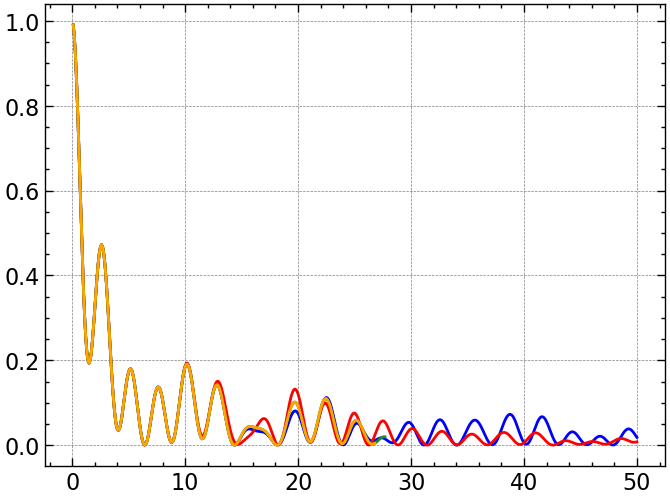

In [69]:
dqpt_fredkin_N20 = np.loadtxt('Fredkin_DW_N20_fidality_ratefn_dt0p1_t50.txt')

dqpt_fredkin_N16 = np.loadtxt('Fredkin_DW_N16_fidality_ratefn_dt0p1_t50.txt')

dqpt_fredkin_N12 = np.loadtxt('Fredkin_DW_N12_fidality_ratefn_dt0p1_t50.txt')

dqpt_fredkin_N8 = np.loadtxt('Fredkin_DW_N8_fidality_ratefn_dt0p1_t50.txt')

dqpt_fredkin_N10 = np.loadtxt('Fredkin_DW_N10_fidality_ratefn_dt0p1_t50.txt')

dqpt_fredkin_N60 = np.loadtxt('Fredkin_DW_Overlap_N60_dt0p1_t50.txt')

dqpt_fredkin_N100 = np.loadtxt('Fredkin_DW_ovlap_N100_dt0p1_t50.txt')

xdqpt = dqpt_fredkin_N20[:,0]
ydqpt = dqpt_fredkin_N20[:,1]
zdqpt = dqpt_fredkin_N20[:,2]

xdqpt1 = dqpt_fredkin_N16[:,0]
ydqpt1 = dqpt_fredkin_N16[:,1]
zdqpt1 = dqpt_fredkin_N16[:,2]

xdqpt2 = dqpt_fredkin_N12[:,0]
ydqpt2 = dqpt_fredkin_N12[:,1]
zdqpt2 = dqpt_fredkin_N12[:,2]

xdqpt3 = dqpt_fredkin_N8[:,0]
ydqpt3 = dqpt_fredkin_N8[:,1]
zdqpt3 = dqpt_fredkin_N8[:,2]

xdqpt4 = dqpt_fredkin_N10[:,0]
ydqpt4 = dqpt_fredkin_N10[:,1]
zdqpt4 = dqpt_fredkin_N10[:,2]

xdqpt60 = dqpt_fredkin_N60[:,0]
ydqpt60 = dqpt_fredkin_N60[:,1]

xdqpt100 = dqpt_fredkin_N100[:,0]
ydqpt100 = dqpt_fredkin_N100[:,1]


plt.plot(xdqpt, ydqpt, color ='blue')
plt.plot(xdqpt1, ydqpt1, color = 'red')
#plt.plot(xdqpt2, ydqpt2, color = 'green')
#plt.plot(xdqpt3, ydqpt3, color = 'orange')
#plt.plot(xdqpt4, ydqpt4, color = 'magenta')
plt.plot(xdqpt60, ydqpt60, color = 'forestgreen')
plt.plot(xdqpt100, ydqpt100, color = 'orange')





#plt.plot(xdqpt, zdqpt)

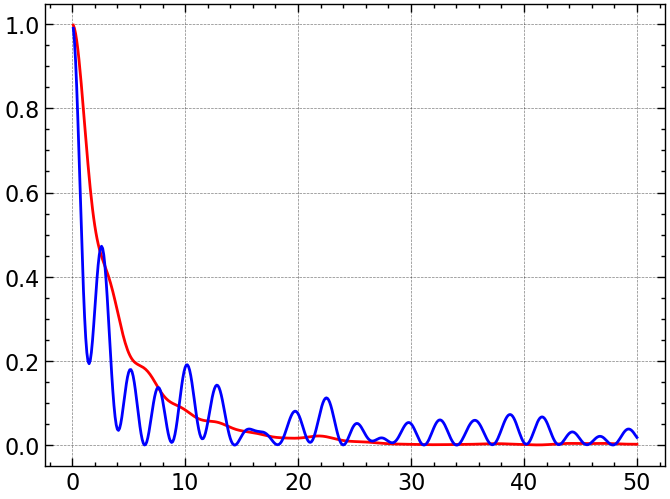

In [70]:
dqpt_xxx_N20 = np.loadtxt('XXX_ferro_DW_N20_fidality_ratefn_dt0p1_t50.txt')

dqpt_xxx_N16 = np.loadtxt('XXX_ferro_DW_N16_fidality_ratefn_dt0p1_t50.txt')

dqpt_xxx_N12 = np.loadtxt('XXX_ferro_DW_N12_fidality_ratefn_dt0p1_t50.txt')

dqpt_xxx_N8 = np.loadtxt('XXX_ferro_DW_N8_fidality_ratefn_dt0p1_t50.txt')

dqpt_xxx_N10 = np.loadtxt('XXX_ferro_DW_N10_fidality_ratefn_dt0p1_t50.txt')

xdqpt_xxx_20 = dqpt_xxx_N20[:,0]
ydqpt_xxx_20 = dqpt_xxx_N20[:,1]

xdqpt_xxx_8 = dqpt_xxx_N8[:,0]
ydqpt_xxx_8 = dqpt_xxx_N8[:,1]

plt.plot(xdqpt_xxx_20, ydqpt_xxx_20,color='red')
plt.plot(xdqpt, ydqpt, color ='blue')
#plt.plot(xdqpt_xxx_8, ydqpt_xxx_8,color='orange')
#plt.plot(xdqpt3, ydqpt3, color ='green')


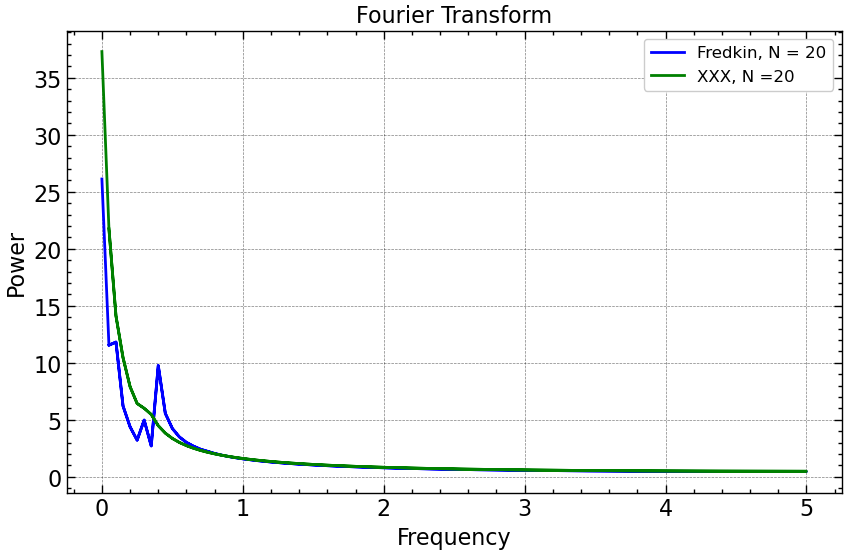

In [51]:
from scipy.fft import fft, fftfreq

data_fft = np.loadtxt('Fredkin_DW_N20_fidality_ratefn_dt0p1_t50.txt')
data_fft_60 = np.loadtxt('Fredkin_DW_Overlap_N60_dt0p1_t50.txt')
data_fft_100 = np.loadtxt('Fredkin_DW_ovlap_N100_dt0p1_t50.txt')

data_fft_xxx_20 = np.loadtxt('XXX_ferro_DW_N20_fidality_ratefn_dt0p1_t50.txt')


time = data_fft[:, 0][:200]
ovlap_data = data_fft[:, 1][:200]

power = fft(ovlap_data)
frequency = fftfreq(len(ovlap_data), time[1] - time[0])

time_60 = data_fft_60[:, 0][:200]
ovlap_data_60 = data_fft_60[:, 1][:200]

power_60 = fft(ovlap_data_60)
frequency_60 = fftfreq(len(ovlap_data_60), time_60[1] - time_60[0])

time_100 = data_fft_100[:, 0][:200]
ovlap_data_100 = data_fft_100[:, 1][:200]

power_100 = fft(ovlap_data_100)
frequency_100 = fftfreq(len(ovlap_data_100), time_100[1] - time_100[0])

time_xxx = data_fft_xxx_20[:, 0][:200]
ovlap_data_xxx = data_fft_xxx_20[:, 1][:200]

power_xxx = fft(ovlap_data_xxx)
frequency_xxx = fftfreq(len(ovlap_data_xxx), time_xxx[1] - time_xxx[0])


plt.figure(figsize=(10, 6))

# Plot magnitude of the Fourier Transform
plt.plot(np.abs(frequency), np.abs(power), color = 'blue', label = 'Fredkin, N = 20')
#plt.plot(np.abs(frequency_60), np.abs(power_60),'x',markersize = 12, color = 'red', label = 'Fredkin, N = 60')
#plt.plot(np.abs(frequency_100), np.abs(power_100),'o', color = 'orange', label = 'Fredkin, N =100')
plt.plot(np.abs(frequency_xxx), np.abs(power_xxx), color = 'green', label = 'XXX, N =20')


plt.title("Fourier Transform")
plt.xlabel("Frequency")
plt.ylabel("Power")
plt.legend(fontsize = 12, loc = 'upper right')


In [55]:
qdw = np.loadtxt("Fredkin_vN_DW_N20_Left_L10_Central_C10_dt0p1_t50.txt")
adw = np.loadtxt("XXX_ferro_vN_DW_N20_Left_L10_Central_C10_dt0p1_t50.txt")

qrdw = np.loadtxt("Fredkin_Renyi_DW_N20_Left_L10_Central_C10_dt0p1_t50.txt")

qpgs = np.loadtxt("Fredkin_pert_GS_N20_Left_L10_Central_C10_dt0p1_t50.txt")

qneel = np.loadtxt("Fredkin_neel_N20_Left_L10_Central_C10_dt0p1_t50.txt")

qrand = np.loadtxt("Fredkin_random_product_N20_Left_L10_Central_C10_dt0p1_t50.txt")

arand = np.loadtxt("XXX_ferro_random_product_N20_Left_L10_Central_C10_dt0p1_t50.txt")

xqdw = qdw[:,0]
yqdw = qdw[:,1]
zqdw = qdw[:,2]

xqrdw = qrdw[:,0]
yqrdw = qrdw[:,1]
zqrdw = qrdw[:,2]

xadw = adw[:,0]
yadw = adw[:,1]
zadw = adw[:,2]

xqpgs = qpgs[:,0]
yqpgs = qpgs[:,1]
zqpgs = qpgs[:,2]

xqneel = qneel[:,0]
yqneel = qneel[:,1]
zqneel = qneel[:,2]

xqrand = qrand[:,0]
yqrand = qrand[:,1]
zqrand = qrand[:,2]

xarand = arand[:,0]
yarand = arand[:,1]
zarand = arand[:,2]

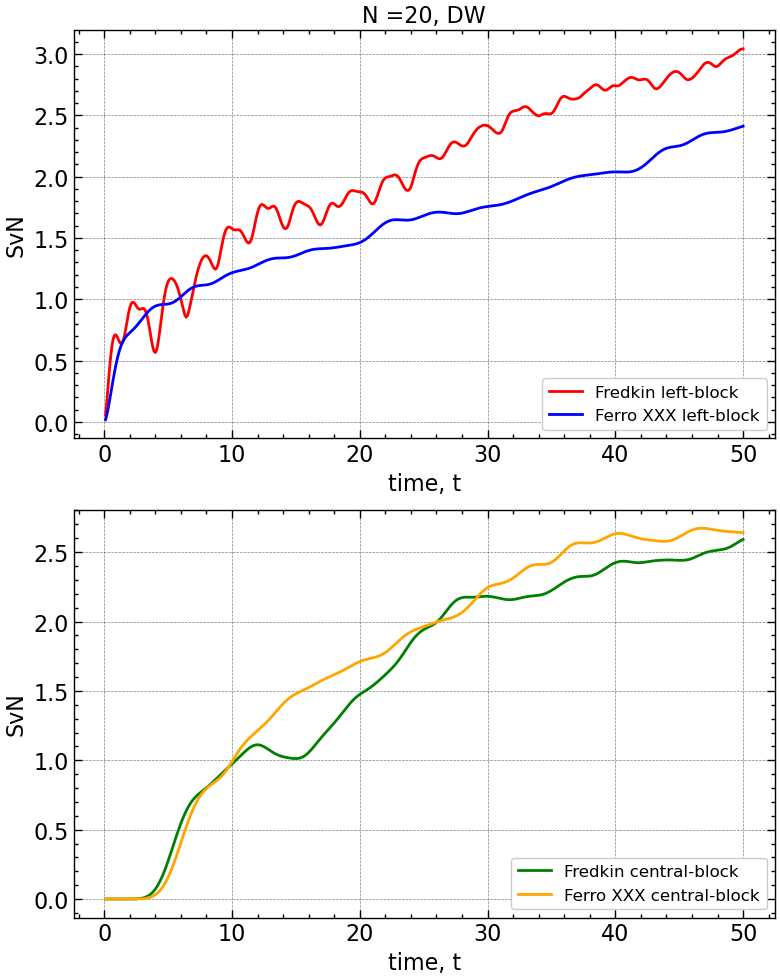

In [34]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Create a figure with a specific size
fig = plt.figure(figsize=(8, 10))

# Create a GridSpec layout with 2 rows and 1 column
# Customize height_ratios for arbitrary sizing of the subplots
gs = gridspec.GridSpec(2, 1, height_ratios=[2, 2])  # Custom height ratios (e.g., 2:4)

# Create subplots in the defined GridSpec layout
ax0 = fig.add_subplot(gs[0])  # First subplot
ax1 = fig.add_subplot(gs[1])  # Second subplot

# Plotting data
ax0.plot(xqdw, yqdw, color='red', label='Fredkin left-block')
ax0.plot(xadw, yadw, color='blue', label='Ferro XXX left-block')
ax1.plot(xqdw, zqdw, color='green', label='Fredkin central-block')
ax1.plot(xadw, zadw, color='orange', label='Ferro XXX central-block')

# Adding legends
ax0.legend(fontsize = 12,loc='lower right')
ax1.legend(fontsize = 12,loc='lower right')

# Labels for the axes
ax0.set_xlabel('time, t')
ax0.set_ylabel('SvN')
ax1.set_xlabel('time, t')
ax1.set_ylabel('SvN')

ax0.set_title('N =20, DW')

# Display the plot
plt.tight_layout()  # Adjust the layout to avoid overlap
plt.show()


Text(0.5, 1.0, 'N =20, perturbed GS')

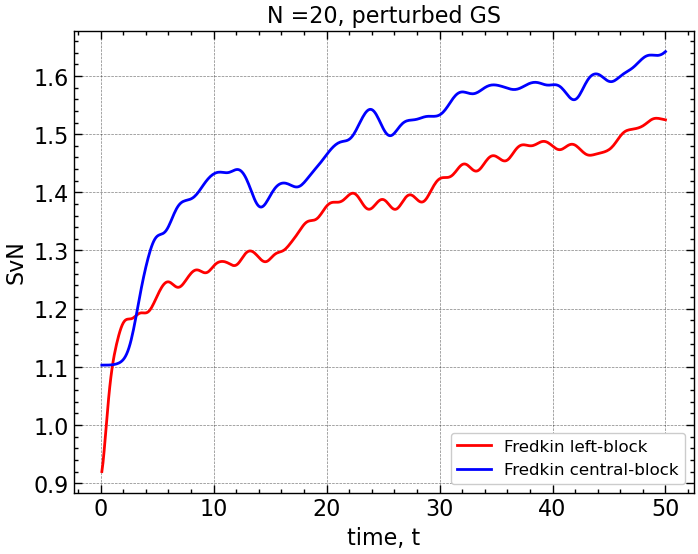

In [35]:
plt.plot(xqpgs,yqpgs,color = 'red', label = 'Fredkin left-block')
plt.plot(xqpgs,zqpgs,color = 'blue', label ='Fredkin central-block')
plt.xlabel('time, t')
plt.ylabel('SvN')
plt.legend(fontsize = 12, loc= 'lower right')
plt.title('N =20, perturbed GS')

Text(0.5, 1.0, 'N =20, Neel')

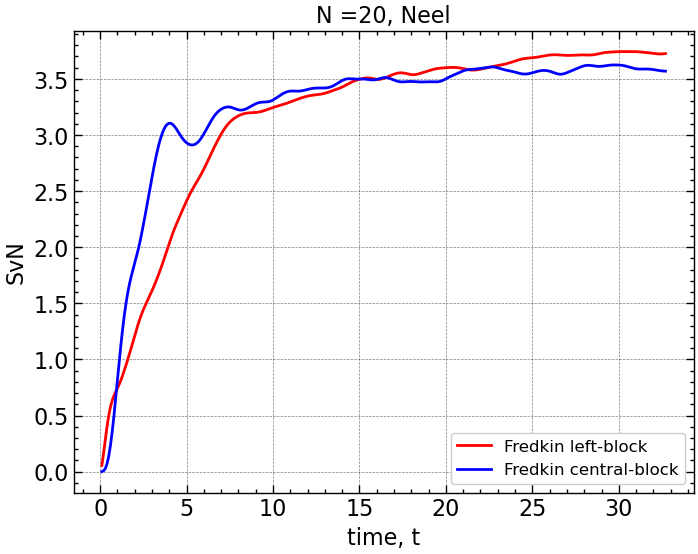

In [36]:
plt.plot(xqneel,yqneel,color = 'red', label = 'Fredkin left-block')
plt.plot(xqneel,zqneel,color = 'blue', label ='Fredkin central-block')
plt.xlabel('time, t')
plt.ylabel('SvN')
plt.legend(fontsize = 12, loc= 'lower right')
plt.title('N =20, Neel')

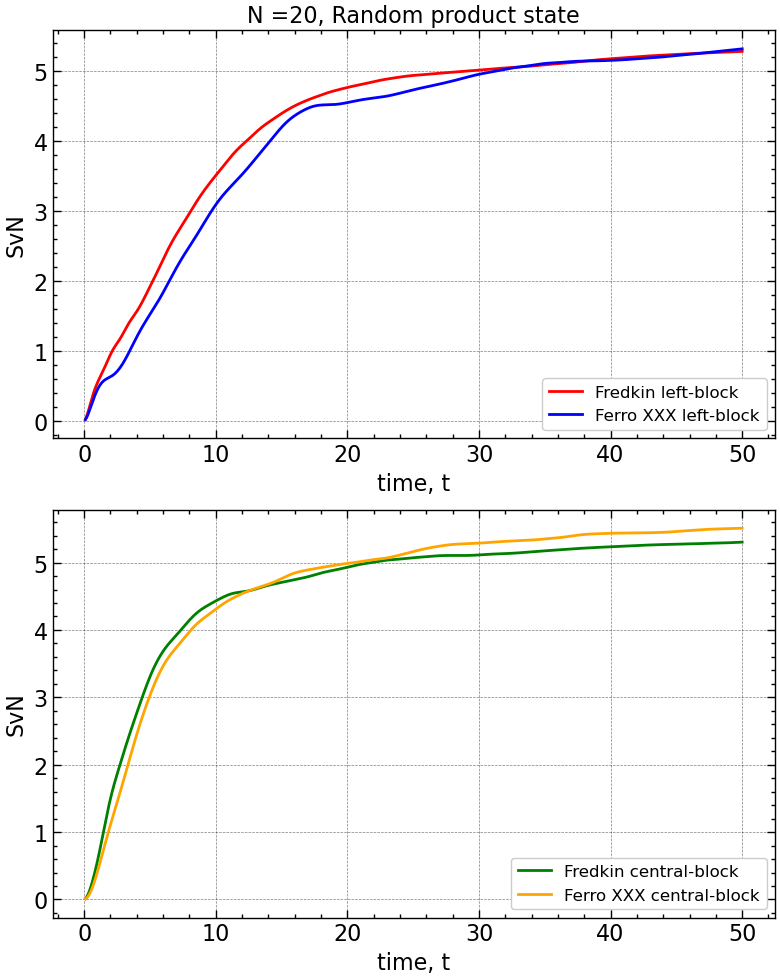

In [37]:
# Create a figure with a specific size
fig = plt.figure(figsize=(8, 10))

# Create a GridSpec layout with 2 rows and 1 column
# Customize height_ratios for arbitrary sizing of the subplots
gs = gridspec.GridSpec(2, 1, height_ratios=[2, 2])  # Custom height ratios (e.g., 2:4)

# Create subplots in the defined GridSpec layout
ax0 = fig.add_subplot(gs[0])  # First subplot
ax1 = fig.add_subplot(gs[1])  # Second subplot

# Plotting data
ax0.plot(xqrand, yqrand, color='red', label='Fredkin left-block')
ax0.plot(xarand, yarand, color='blue', label='Ferro XXX left-block')
ax1.plot(xqrand, zqrand, color='green', label='Fredkin central-block')
ax1.plot(xarand, zarand, color='orange', label='Ferro XXX central-block')

# Adding legends
ax0.legend(fontsize = 12,loc='lower right')
ax1.legend(fontsize = 12,loc='lower right')

# Labels for the axes
ax0.set_xlabel('time, t')
ax0.set_ylabel('SvN')
ax1.set_xlabel('time, t')
ax1.set_ylabel('SvN')

ax0.set_title('N =20, Random product state')

# Display the plot
plt.tight_layout()  # Adjust the layout to avoid overlap
plt.show()

Text(0.5, 1.0, 'N = 20 DW')

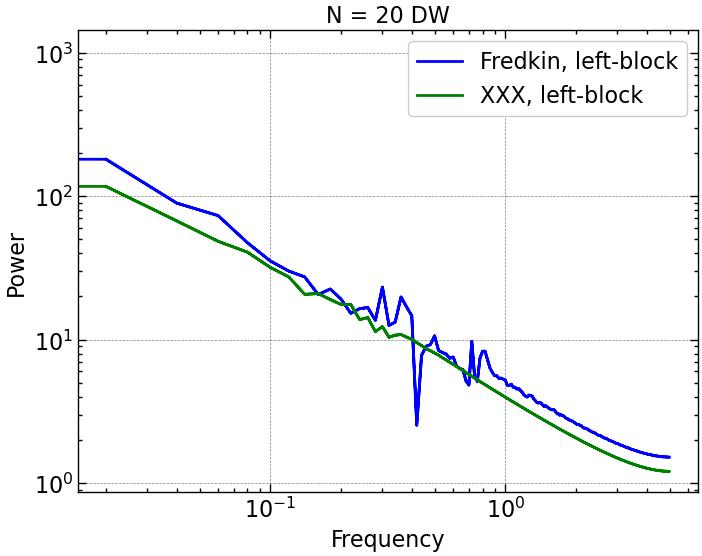

In [59]:
from scipy.fft import fft, fftfreq
pw_qdw = fft(yqdw)
pw_qdw_1 = fft(zqdw)
fq_qdw = fftfreq(len(xqdw),0.1)
pw_adw = fft(yadw)
pw_adw_1 = fft(zadw)
fq_adw = fftfreq(len(xadw),0.1)
plt.plot(np.abs(fq_qdw), np.abs(pw_qdw), color = 'blue', label = 'Fredkin, left-block')
plt.plot(np.abs(fq_adw), np.abs(pw_adw), color = 'green', label = 'XXX, left-block')
plt.xlabel('Frequency')
plt.ylabel('Power')
plt.xscale('log')
plt.yscale('log')
plt.legend(loc= 'upper right')
plt.title('N = 20 DW')

Text(0.5, 1.0, 'N = 20 DW')

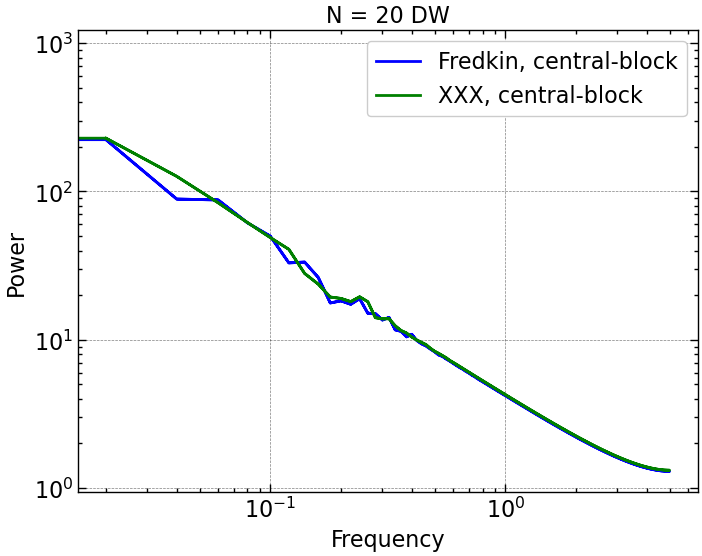

In [49]:
plt.plot(np.abs(fq_qdw), np.abs(pw_qdw_1), color = 'blue', label = 'Fredkin, central-block')
plt.plot(np.abs(fq_adw), np.abs(pw_adw_1), color = 'green', label = 'XXX, central-block')
plt.xlabel('Frequency')
plt.ylabel('Power')
plt.xscale('log')
plt.yscale('log')
plt.legend(loc= 'upper right')
plt.title('N = 20 DW')


Text(0.5, 1.0, 'N = 20 Neel')

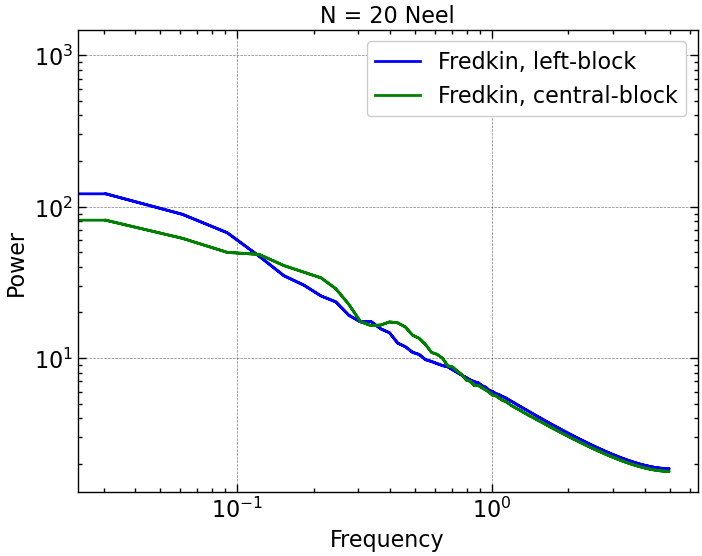

In [54]:
pw_qneel = fft(yqneel)
pw_qneel_1 = fft(zqneel)
fq_qneel = fftfreq(len(xqneel),0.1)
plt.plot(np.abs(fq_qneel), np.abs(pw_qneel), color = 'blue', label = 'Fredkin, left-block')
plt.plot(np.abs(fq_qneel), np.abs(pw_qneel_1), color = 'green', label = 'Fredkin, central-block')
plt.xlabel('Frequency')
plt.ylabel('Power')
plt.xscale('log')
plt.yscale('log')
plt.legend(loc= 'upper right')
plt.title('N = 20 Neel')

Text(0.5, 1.0, 'N = 20 Perturbed GS')

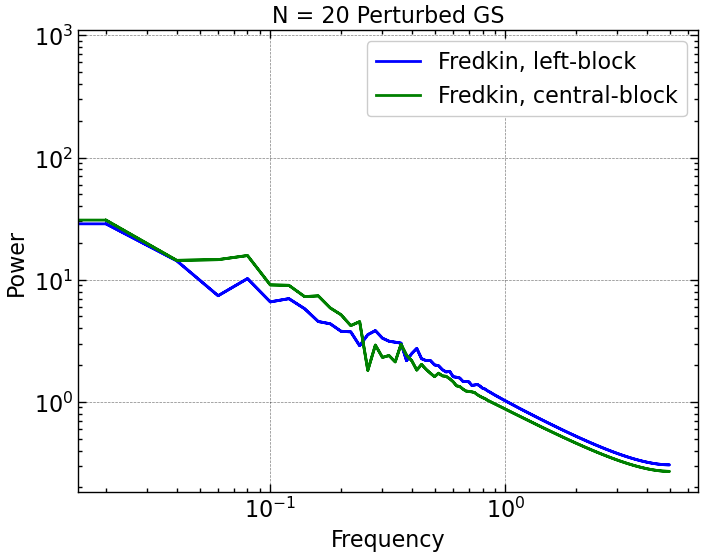

In [53]:
pw_qpgs = fft(yqpgs)
pw_qpgs_1 = fft(zqpgs)
fq_qpgs = fftfreq(len(xqpgs),0.1)
plt.plot(np.abs(fq_qpgs), np.abs(pw_qpgs), color = 'blue', label = 'Fredkin, left-block')
plt.plot(np.abs(fq_qpgs), np.abs(pw_qpgs_1), color = 'green', label = 'Fredkin, central-block')
plt.xlabel('Frequency')
plt.ylabel('Power')
plt.xscale('log')
plt.yscale('log')
plt.legend(loc= 'upper right')
plt.title('N = 20 Perturbed GS')


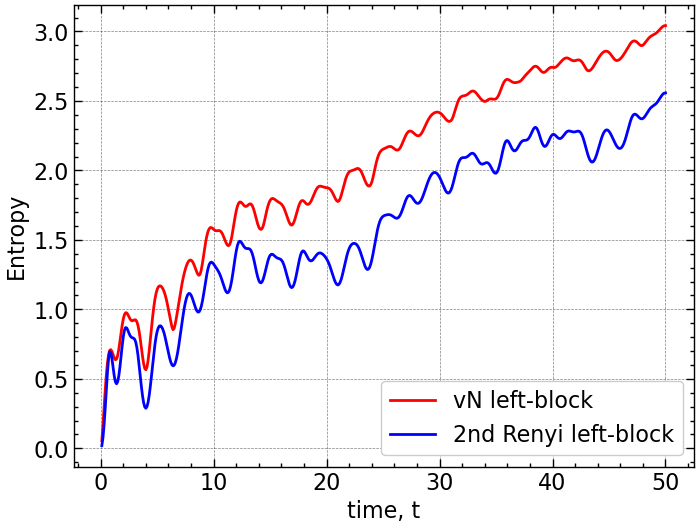

In [57]:
plt.plot(xqdw,yqdw, color = 'red', label = 'vN left-block')
plt.plot(xqrdw,yqrdw,color = 'blue', label = '2nd Renyi left-block')
plt.xlabel('time, t')
plt.ylabel('Entropy')
plt.legend(loc='lower right')

In [ ]:
#entanglement spectrum for eigenstates





Hamtt = FredkinHam
spinsitec = spinsite_1
t = 0.1
Nstep = 500
alpha = 1.0
filename = "Fredkin_twoDW_N20_left_block_L10_dt0p1_t50_singval.txt"
evolved_state = initial_state
#evolved_state = np.squeeze(np.transpose(evol_op(FredkinHam,1.0,7.0,7.0,1).dot(initial_state)))
with open(filename, "w") as file:
    file.write("")

for step in range(Nstep):
    evolved_state = np.squeeze(np.transpose(evol_op(Hamtt,1.0,t,t,1).dot(evolved_state)))
    #ovlapin = (1/N)*np.log(abs(np.inner(np.conjugate(np.transpose(evolved_state)),initial_state))**2)
    S_ent_1 = basis.ent_entropy(evolved_state,sub_sys_A=spinsitec,density = False,return_rdm="A",enforce_pure=False,return_rdm_EVs=True,sparse=True,alpha=alpha,sparse_diag=True,subsys_ordering=True)
    S_ent_f_1 = float(S_ent_1['Sent_A'])
    P_sub_A0 = S_ent_1['p_A']
    P_sub_A = [float(P_sub_A0[i]) for i in range(len(P_sub_A0))]
    tmm = t*(step+1)
    c1 = str(tmm)
    #c2 = str(ovlapin)
    #c3 = c1 + ' ' + c2
                  
    c2 = str(S_ent_f_1)
    c3 = str(P_sub_A)
    c4 = c1 +' '+ c2 + ' '+ c3
    with open(filename, "a") as file:
        file.write(c4 + '\n')
        file.flush()

In [139]:
coln1 = []
coln2 = []
coln3 = []

with open('Fredkin_twoDW_N20_central_block_L10_dt0p1_t50_singval.txt', 'r') as file:
    for line in file:
        parts = line.strip().split(' ', 2)
        coln1.append(float(parts[0]))
        coln2.append(float(parts[1]))
        coln3.append(parse_list(parts[2]))


In [55]:
len(coln3)

500

In [142]:
max_singl_val = [ith_sing_p_A(0,coln3[i]) for i in range(len(coln3))]

max_singl_val1 = [ith_sing_p_A(1,coln3[i]) for i in range(len(coln3))]

diff1 = [max_singl_val[i]-max_singl_val1[i] for i in range(len(max_singl_val))]

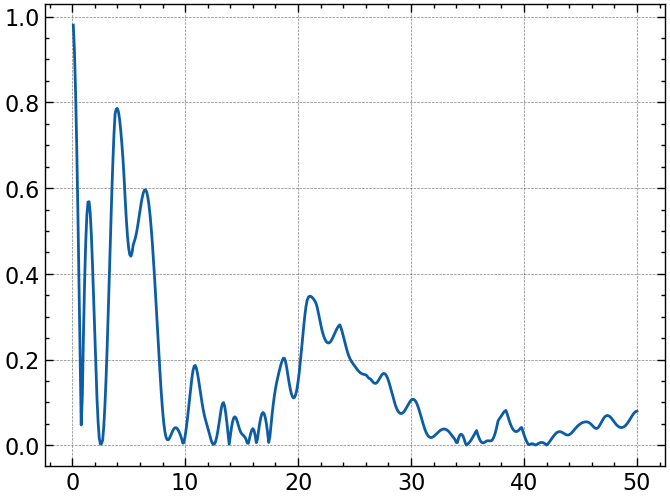

In [143]:
#plt.plot(coln1, max_singl_val, color='red')
#plt.plot(coln1, max_singl_val1, color='blue')
plt.plot(coln1,diff1)

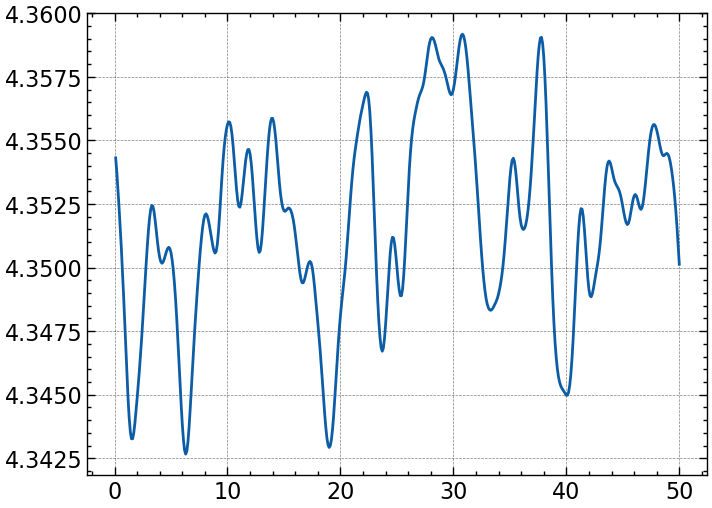

In [17]:
rand_1 = []
rand_2 = []
rand_3 = []

with open('Fredkin_random_state_N14_left_block_L7_dt0p1_t50_singval.txt', 'r') as file:
    for line in file:
        parts = line.strip().split(' ', 2)
        rand_1.append(float(parts[0]))
        rand_2.append(float(parts[1]))
        rand_3.append(parse_list(parts[2]))
plt.plot(rand_1, rand_2)


Text(0.5, 1.0, 'N = 20, $N_A$ = 10, |uu..u$d_{10}$u..uu>')

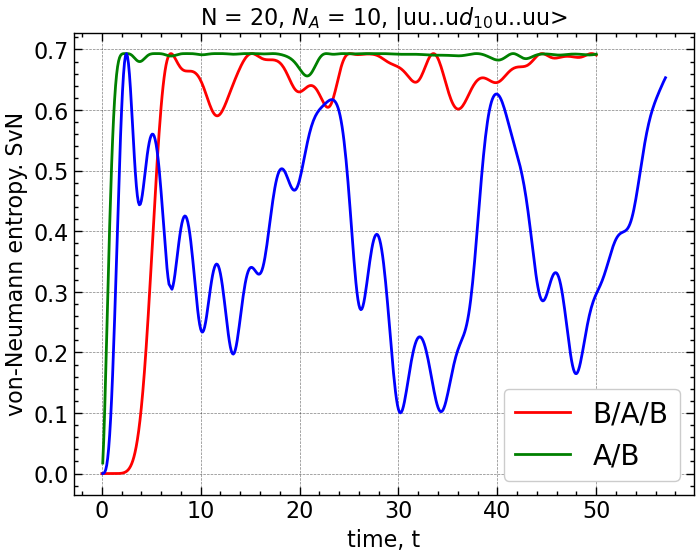

In [7]:
datanew = np.loadtxt('Fredkin_vN_pertup_N20_mid_block_L10_dt0p1_t5.txt')
datanew1 = np.loadtxt('Fredkin_vN_pertup_N20_mid_block_L10_dt0p1_t5-50.txt')
datanew2 = np.loadtxt('Fredkin_vN_pertup_N20_left_block_L10_dt0p1_t50.txt')
datanew_01 = np.loadtxt('Fredkin_vN_pertup_N20_mid_block_L3_dt0p1_t50.txt')
datanew_02 = np.loadtxt('Fredkin_vN_pertup_N20_mid_block_L3_dt0p1_t7-50.txt')
datanew3 = np.loadtxt('Fredkin_vN_pertup_N20_left_block_L2_dt0p1_t50.txt')


xdatan = datanew[:,0]
ydatan = datanew[:,1]

xdatan1 = datanew1[:,0]
ydatan1 = datanew1[:,1]

xdatan2 = datanew2[:,0]
ydatan2 = datanew2[:,1]

xdatan3=datanew3[:,0]
ydatan3=datanew3[:,1]

xdatan_010 = datanew_01[:,0]
xdatan_01 = [i-5.0 for i in xdatan_010]
xdatan_02 = datanew_02[:,0]
ydatan_01 = datanew_01[:,1]
ydatan_02 = datanew_02[:,1]

xdatan_mid_3 = np.concatenate((xdatan_01,xdatan_02))
ydatan_mid_3 = np.concatenate((ydatan_01,ydatan_02))
        

xdatan11 = np.concatenate((xdatan, xdatan1))
ydatan11 = np.concatenate((ydatan, ydatan1))


plt.plot(xdatan11, ydatan11,color='red',label=r'B/A/B')
plt.plot(xdatan2, ydatan2,color='green',label=r'A/B')
plt.plot(xdatan_mid_3, ydatan_mid_3,color='blue')
#plt.plot(xdatan3, ydatan3,color='orange')
#plt.xscale('log')
#plt.yscale('log')
plt.xlabel('time, t')
plt.ylabel('von-Neumann entropy. SvN')
plt.legend(fontsize = 20, loc = 'lower right')
plt.title(r'N = 20, $N_A$ = 10, |uu..u$d_{10}$u..uu>')

Text(0.5, 1.0, 'N = 20, $N_A$ = 10, |uu..u$d_{10}$u..uu>')

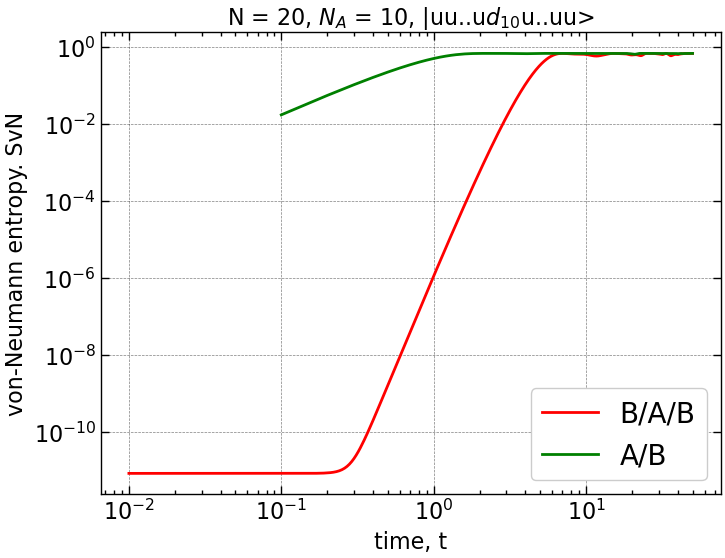

In [8]:
plt.plot(xdatan11, ydatan11,color='red',label=r'B/A/B')
plt.plot(xdatan2, ydatan2,color='green',label=r'A/B')
#plt.plot(xdatan_mid_3, ydatan_mid_3,color='blue')
#plt.plot(xdatan3, ydatan3,color='orange')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('time, t')
plt.ylabel('von-Neumann entropy. SvN')
plt.legend(fontsize = 20, loc = 'lower right')
plt.title(r'N = 20, $N_A$ = 10, |uu..u$d_{10}$u..uu>')

Text(0.5, 1.0, 'Two-DW, |u..udd..ddu..u>, Left block A, l= down spin-size')

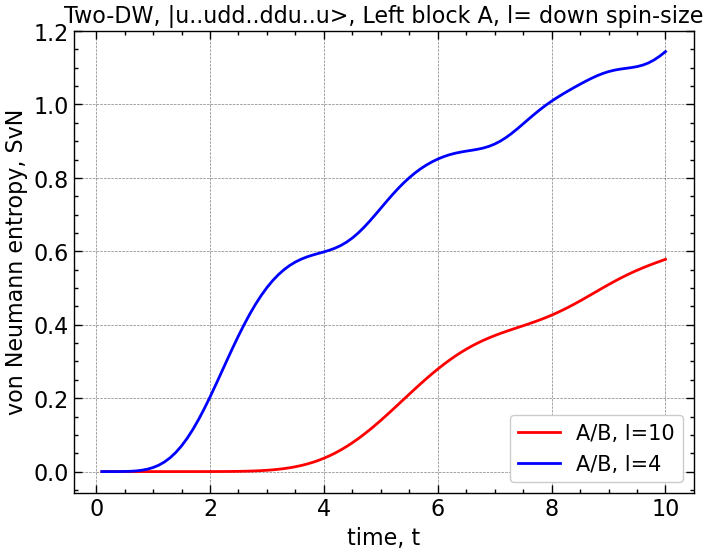

In [9]:
data2dw = np.loadtxt("Fredkin_vN_twoDW_N20_left_block_L10_dt0p1_t50.txt")
data2dw1 = np.loadtxt("Fredkin_vN_twoDW_N20_mid_l4_left_block_L10_dt0p1_t50.txt")

x2dw = data2dw[:,0][:100]
y2dw = data2dw[:,1][:100]

x2dw1 = data2dw1[:,0][:100]
y2dw1 = data2dw1[:,1][:100]


plt.plot(x2dw, y2dw, color='red', label=r'A/B, l=10')
plt.plot(x2dw1, y2dw1, color='blue', label=r'A/B, l=4')
#plt.plot(xdatan2, ydatan2,color='green',label=r'A/B, l = 1')

plt.xlabel('time, t')
plt.ylabel('von Neumann entropy, SvN')
plt.legend(fontsize=15, loc='lower right')
#plt.xscale('log')
#plt.yscale('log')
plt.title('Two-DW, |u..udd..ddu..u>, Left block A, l= down spin-size') 

Text(0.5, 1.0, 'Ferromagnetic H_XXX, initial perturbed-up, N =20')

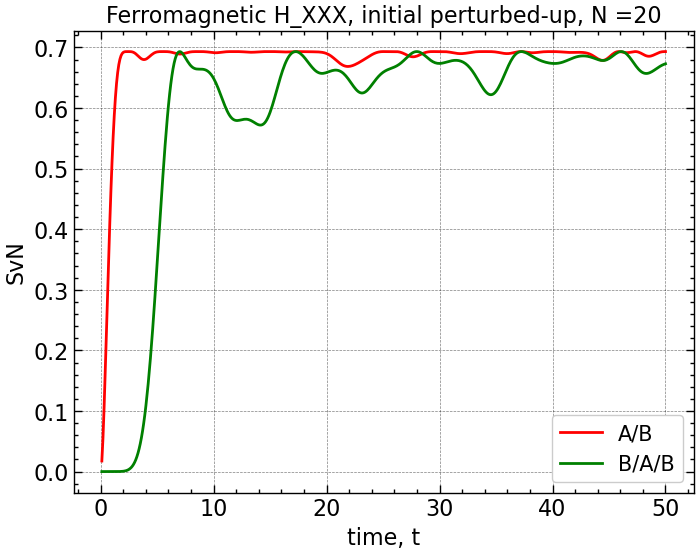

In [10]:
#dataferro = np.loadtxt("XXX_ferro_vN_pertup_N20_left_block_L10_dt0p1_t50.txt")
#dataantiferro = np.loadtxt("XXX_antiferro_vN_pertup_N20_left_block_L10_dt0p1_t50.txt")
#dataferrom = np.loadtxt("XXX_ferro_vN_pertup_N20_mid_block_L10_dt0p1_t50.txt")

dataferro = np.loadtxt("XXX_ferro_vN_pertup_N20_left_block_L10_dt0p1_t50-new.txt")

dataferrom = np.loadtxt("XXX_ferro_vN_pertup_N20_mid_block_L10_dt0p1_t50-new.txt")

xferro = dataferro[:,0]
yferro = dataferro[:,1]

#xantiferro = dataantiferro[:,0][:100]
#yantiferro = dataantiferro[:,1][:100]

xferrom = dataferrom[:,0]
yferrom = dataferrom[:,1]

plt.plot(xferro, yferro, color = 'red', label = r'A/B')
plt.plot(xferrom, yferrom, color = 'green', label=r'B/A/B')
#plt.plot(xdatan11, ydatan11,color='magenta',label=r'B/A/B')
#plt.plot(xdatan2, ydatan2,color='skyblue',label=r'A/B')



#plt.plot(xantiferro, yantiferro, color = 'blue')

plt.legend(fontsize = 15, loc = 'lower right')
plt.xlabel('time, t')
plt.ylabel('SvN')
plt.title('Ferromagnetic H_XXX, initial perturbed-up, N =20')

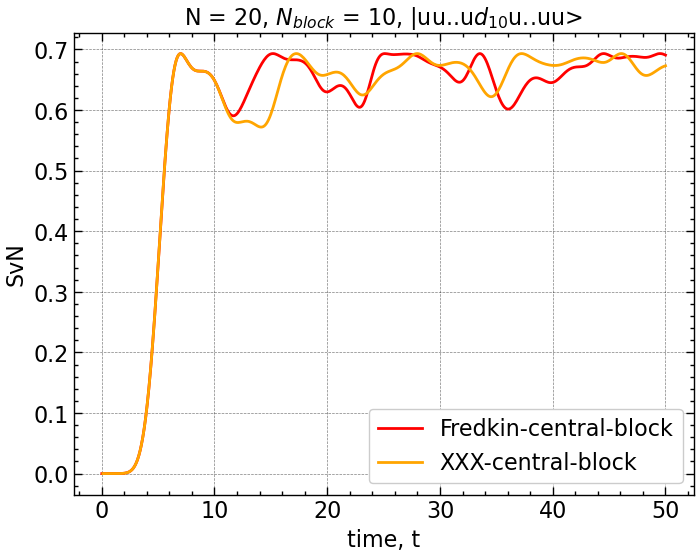

In [11]:
plt.plot(xdatan11, ydatan11, color = 'red', label = r'Fredkin-central-block')
#plt.plot(xdatan2, ydatan2, color = 'blue', label = r'Fredkin-left-block')
plt.plot(xferrom, yferrom, color = 'orange', label = r'XXX-central-block')
#plt.plot(xferro, yferro, color = 'green', label = r'XXX-left-block')
plt.xlabel('time, t')
plt.ylabel('SvN')
plt.legend(loc= 'lower right')
plt.title(r'N = 20, $N_{block}$ = 10, |uu..u$d_{10}$u..uu>')
plt.savefig('Fredkin_vs_XXX_pertup_N20_central-block_L10_t50.pdf',dpi=300)

Text(0.5, 1.0, 'Ferromagnetic H_XXX, N =20, block size, L = 10')

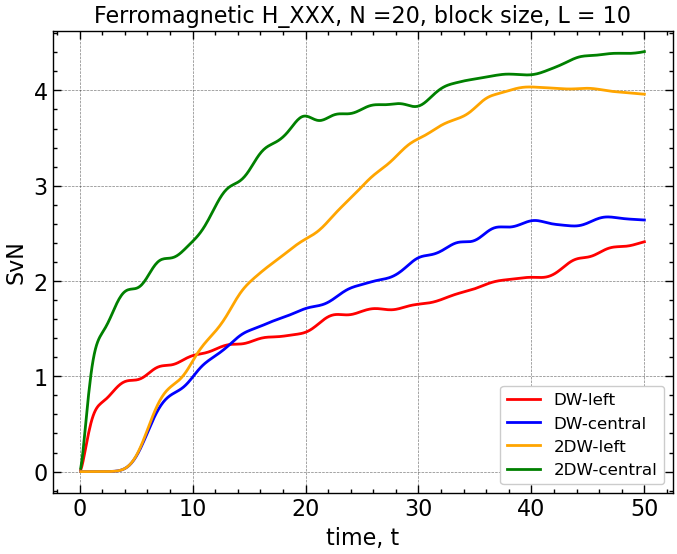

In [12]:
datadwxxxl = np.loadtxt("XXX_ferro_vN_DW_N20_left_block_L10_dt0p1_t50-v.txt")
datadwxxxmid = np.loadtxt('XXX_ferro_vN_DW_N20_mid_block_L10_dt0p1_t50-v.txt')

data2dwxxxl = np.loadtxt('XXX_ferro_vN_twoDW_N20_left_block_L10_dt0p1_t50-v.txt')
data2dwxxxmid =  np.loadtxt('XXX_ferro_vN_twoDW_N20_mid_block_L10_dt0p1_t50-v.txt')


xdatadwxxxl = datadwxxxl[:,0]
ydatadwxxxl = datadwxxxl[:,1]

xdatadwxxxmid = datadwxxxmid[:,0]
ydatadwxxxmid = datadwxxxmid[:,1]

xdata2dwxxxl = data2dwxxxl[:,0]
ydata2dwxxxl = data2dwxxxl[:,1]

xdata2dwxxxmid = data2dwxxxmid[:,0]
ydata2dwxxxmid = data2dwxxxmid[:,1]

plt.plot(xdatadwxxxl, ydatadwxxxl, color = 'red', label = 'DW-left')
plt.plot(xdatadwxxxmid, ydatadwxxxmid, color = 'blue', label = 'DW-central')
plt.plot(xdata2dwxxxl, ydata2dwxxxl, color = 'orange', label = '2DW-left')
plt.plot(xdata2dwxxxmid, ydata2dwxxxmid, color = 'green', label = '2DW-central')
plt.xlabel('time, t')
plt.ylabel('SvN')
plt.legend(fontsize = 12, loc = 'lower right')
plt.title('Ferromagnetic H_XXX, N =20, block size, L = 10')

Text(0.5, 1.0, 'Fredkin, initial Two-DW, N = 20, l =10, left block, L = 10')

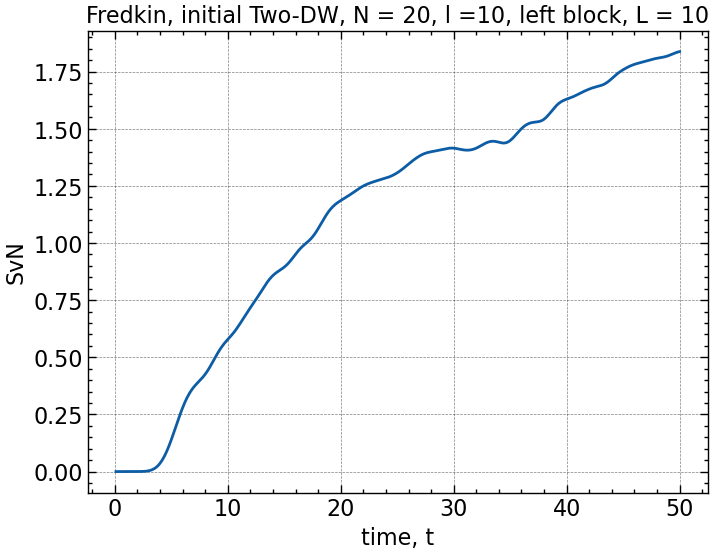

In [13]:
data2dwmid = np.loadtxt("Fredkin_vN_twoDW_N20_left_block_L10_dt0p1_t50-new.txt")

xdata2dwmid = data2dwmid[:,0][:500]
ydata2dwmid = data2dwmid[:,1][:500]

plt.plot(xdata2dwmid, ydata2dwmid)
plt.xlabel('time, t')
plt.ylabel('SvN')
plt.title('Fredkin, initial Two-DW, N = 20, l =10, left block, L = 10')

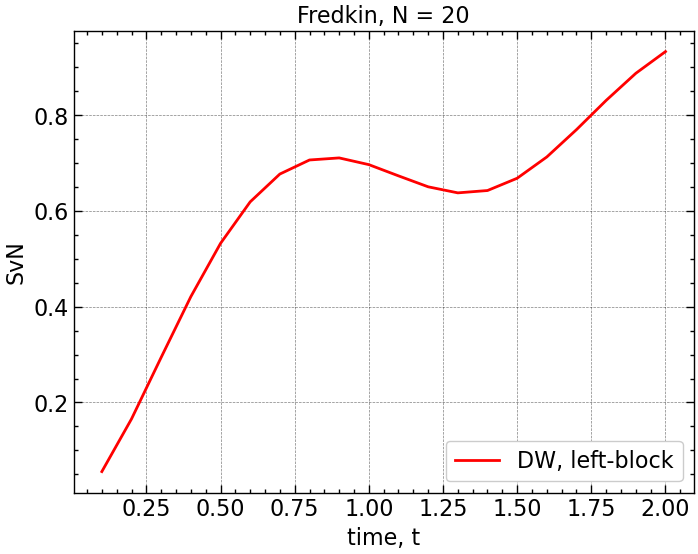

In [21]:
datan20 = np.loadtxt('Fredkin_N20_l10_dt0p1_t200.txt')
xdatan20 = datan20[:,0][:20]
ydatan20 = datan20[:,1][:20]

plt.plot(xdatan20, ydatan20, color = 'red', label = 'DW, left-block')
#plt.plot(coln1, max_singl_val, color='green')
#plt.plot(coln1, max_singl_val1, color='blue')
#plt.plot(coln1,diff1)
#plt.plot(xdata2dwmid, ydata2dwmid, color = 'blue', label = 'Two-DW, mid-block')
plt.xlabel('time, t')
plt.ylabel('SvN')
plt.title('Fredkin, N = 20')
plt.legend(loc='lower right')

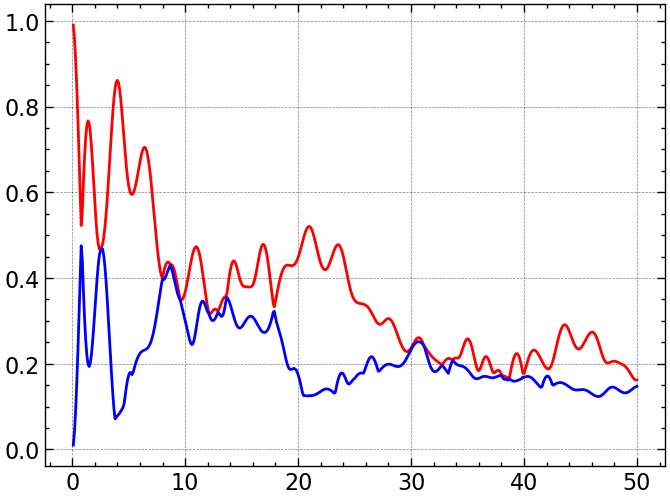

In [129]:
plt.plot(coln1, max_singl_val, color='red')
plt.plot(coln1, max_singl_val1, color='blue')
#plt.plot(coln1,diff1)

Text(0.5, 1.0, 'Ferromagnetic H_XXX, initial two-DW, N =20, mid block, L = 10')

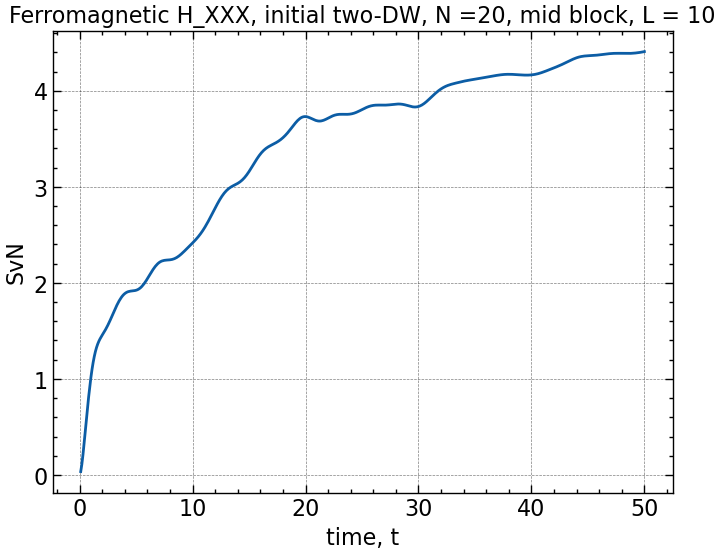

In [10]:
data2dwmidxxx = np.loadtxt('XXX_vN_twoDW_N20_mid_block_L10_dt0p1_t50.txt')

x2dwmidxxx = data2dwmidxxx[:,0]
y2dwmidxxx = data2dwmidxxx[:,1]

plt.plot(x2dwmidxxx, y2dwmidxxx)
plt.xlabel('time, t')
plt.ylabel('SvN')
plt.title('Ferromagnetic H_XXX, initial two-DW, N =20, mid block, L = 10')

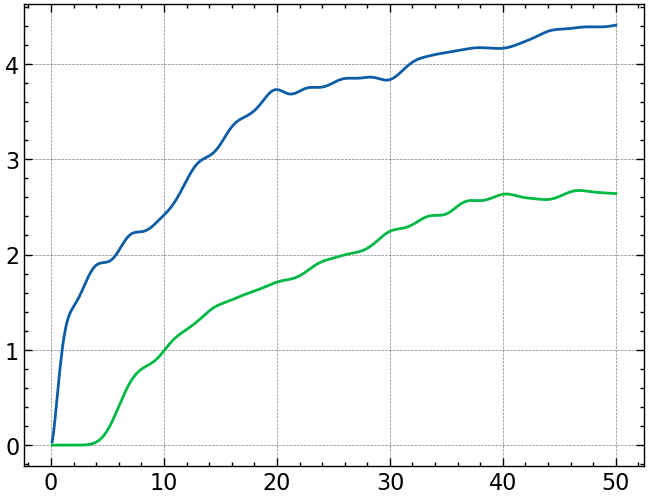

In [11]:
plt.plot(x2dwmidxxx, y2dwmidxxx)
plt.plot(xdatadwxxx, ydatadwxxx)


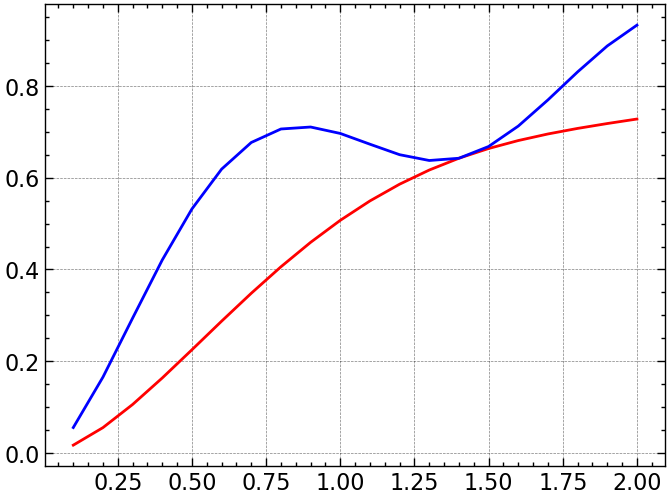

In [22]:
plt.plot(xdatadwxxxl[:20], ydatadwxxxl[:20], color = 'red', label = 'DW-left')
plt.plot(xdatan20, ydatan20, color = 'blue', label = 'DW, left-block')


In [27]:
ydatan20

array([0.05579146, 0.16563609, 0.29412038, 0.42080613, 0.53186157,
       0.61852077, 0.67655751, 0.70591194, 0.71022667, 0.69620983,
       0.67278217, 0.64994864, 0.63730714, 0.64218951, 0.66779997,
       0.71224405, 0.76924265, 0.83024123, 0.88675597, 0.93207766])

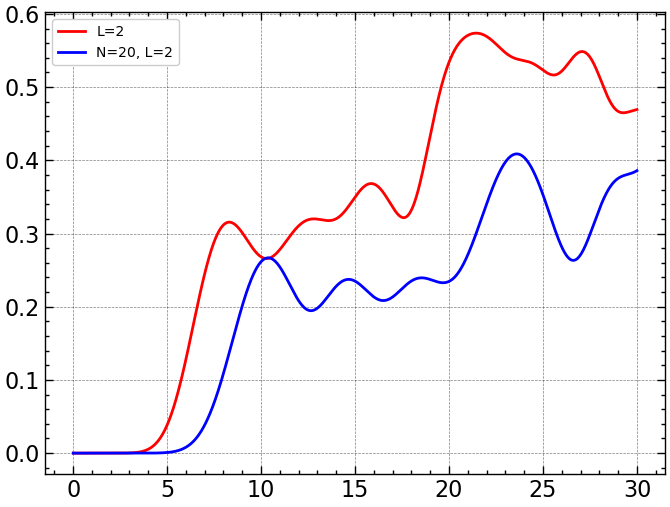

In [95]:
data2 = np.loadtxt('Fredkin_vN_DW_N16_two_region_dt0p01_t100-2.txt')
data3 = np.loadtxt('Fredkin_vN_DW_N16_left_block_dt0p01_t50-3.txt')
data4 = np.loadtxt('Fredkin_vN_DW_N16_two_region_dt0p01_t100-4.txt')
data5 = np.loadtxt('Fredkin_vN_DW_N16_left_block_dt0p01_t50-5.txt')
data6 = np.loadtxt('Fredkin_vN_DW_N16_two_region_dt0p01_t100-6.txt')
data7 = np.loadtxt('Fredkin_vN_DW_N16_left_block_dt0p01_t50-7.txt')
data8 = np.loadtxt('Fredkin_vN_DW_N16_two_region_dt0p01_t100-8.txt')

data20_2 = np.loadtxt('Fredkin_vN_DW_N20_left_block_dt0p01_t30-2.txt')

x20_2 = data20_2[:,0][:3000]
y20_2 = data20_2[:,1][:3000]

x2 = data2[:, 0][:3000]
y2 = data2[:, 1][:3000]

x4 = data4[:, 0][:1000]
y4 = data4[:, 1][:1000]

x6 = data6[:, 0][:1000]
y6 = data6[:, 1][:1000]

x8 = data8[:, 0][:1000]
y8 = data8[:, 1][:1000]

x3 = data3[:, 0][:1000]
y3 = data3[:, 1][:1000]

x5 = data5[:, 0][:1000]
y5 = data5[:, 1][:1000]

x7 = data7[:, 0][:1000]
y7 = data7[:, 1][:1000]

plt.plot(x2,y2,color='red', label = r'N=16, L=2')
plt.plot(x20_2,y20_2, color = 'blue', label = r'N=20, L=2')
#plt.plot(x3,y3,color='blue', label = r'L=3')
#plt.plot(x4,y4,color='green', label=r'L=4')
#plt.plot(x5,y5,color='orange', label=r'L=5')
#plt.plot(x6,y6,color='skyblue', label=r'L=6')
#plt.plot(x7,y7,color='violet', label=r'L=7')
#plt.plot(x8,y8,color='forestgreen',label=r'L=8')
plt.legend(fontsize = 10, loc='upper left')

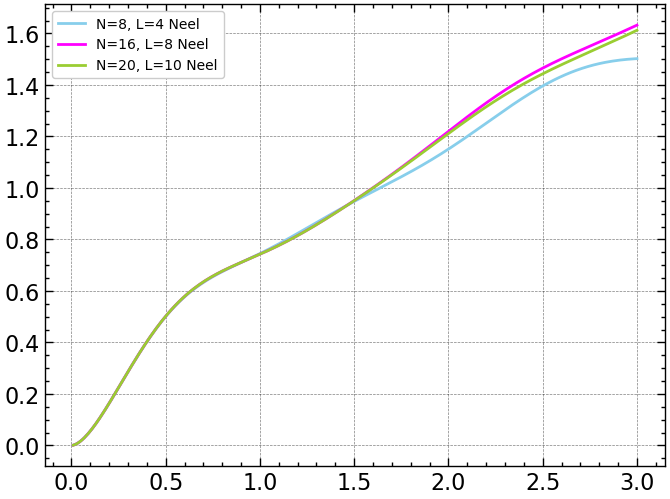

In [186]:
data_16_8 = np.loadtxt('Fredkin_vN_DW_N16_two_region_dt0p01_t100-8.txt')
data_20_10 = np.loadtxt('Fredkin_vN_DW_N20_two_region_dt0p01_t10.txt')
data_8_4 = np.loadtxt('Fredkin_vN_DW_N8_left_block_dt0p01_t20-4.txt')
data_8_4_neel = np.loadtxt('Fredkin_vN_Neel_N8_left_block_dt0p01_t20-4.txt')
data_16_8_neel = np.loadtxt('Fredkin_vN_Neel_N16_left_block_dt0p01_t20-8.txt')
data_20_10_neel = np.loadtxt('Fredkin_vN_Neel_N20_left_block_dt0p01_t20-10.txt')




x_8_4 = data_8_4[:,0][:1000]
y_8_4 = data_8_4[:,1][:1000]

x_8_4_neel = data_8_4_neel[:,0][:300]
y_8_4_neel = data_8_4_neel[:,1][:300]

x_16_8_neel = data_16_8_neel[:,0][:300]
y_16_8_neel = data_16_8_neel[:,1][:300]

x_20_10_neel = data_20_10_neel[:,0][:300]
y_20_10_neel = data_20_10_neel[:,1][:300]


x_16_8 = data_16_8[:, 0][:1000]
y_16_8 = data_16_8[:, 1][:1000]

dy_16_8=[]
for i in range(len(y_16_8)-1):
    df = y_16_8[i+1]-y_16_8[i]
    dff = df/0.01
    dy_16_8.append(dff)

x_20_10 = data_20_10[:, 0][:600]
y_20_10 = data_20_10[:, 1][:600]

dy_20_10=[]
for i in range(len(y_20_10)-1):
    df = y_20_10[i+1]-y_20_10[i]
    dff = df/0.01
    dy_20_10.append(dff)


#plt.plot(x_16_8,y_16_8, color='red', label=r'N=16, L=8')
#plt.plot(x_8_4, y_8_4, color = 'green', label=r'N=8, L=4')
plt.plot(x_8_4_neel, y_8_4_neel, color = 'skyblue', label=r'N=8, L=4 Neel')
plt.plot(x_16_8_neel, y_16_8_neel, color = 'magenta', label=r'N=16, L=8 Neel')
plt.plot(x_20_10_neel, y_20_10_neel, color = 'yellowgreen', label=r'N=20, L=10 Neel')
#plt.plot(x_20_10,y_20_10, color='blue', label=r'N=20, L=10')



plt.legend(fontsize = 10, loc = 'upper left')

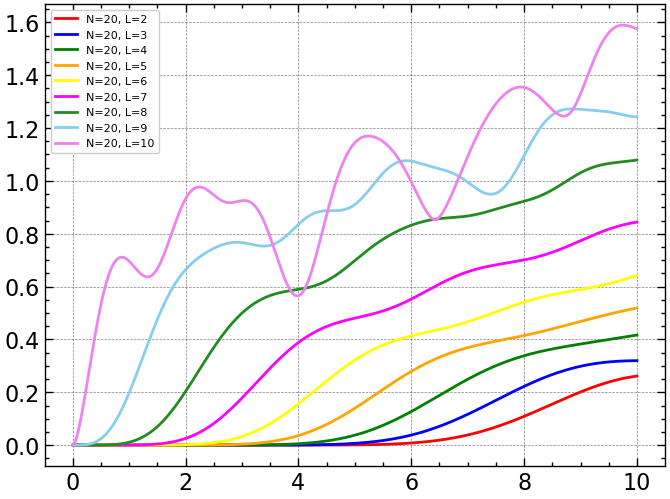

In [80]:
data_20_2 = np.loadtxt('Fredkin_vN_DW_N20_left_block_dt0p01_t30-2.txt')
data_20_3 = np.loadtxt('Fredkin_vN_DW_N20_left_block_dt0p01_t20-3.txt')
data_20_4 = np.loadtxt('Fredkin_vN_DW_N20_left_block_dt0p01_t20-4.txt')
data_20_5 = np.loadtxt('Fredkin_vN_DW_N20_left_block_dt0p01_t20-5.txt')
data_20_6 = np.loadtxt('Fredkin_vN_DW_N20_left_block_dt0p01_t20-6.txt')
data_20_7 = np.loadtxt('Fredkin_vN_DW_N20_left_block_dt0p01_t20-7.txt')
data_20_8 = np.loadtxt('Fredkin_vN_DW_N20_left_block_dt0p01_t20-8.txt')
data_20_9 = np.loadtxt('Fredkin_vN_DW_N20_left_block_dt0p01_t20-9.txt')
data_20_10 = np.loadtxt('Fredkin_vN_DW_N20_two_region_dt0p01_t10.txt')
ll=1000
x_20 = data_20_2[:, 0][:ll]
y_20_2 = data_20_2[:, 1][:ll]
y_20_3 = data_20_3[:, 1][:ll]
y_20_4 = data_20_4[:, 1][:ll]
y_20_5 = data_20_5[:, 1][:ll]
y_20_6 = data_20_6[:, 1][:ll]
y_20_7 = data_20_7[:, 1][:ll]
y_20_8 = data_20_8[:, 1][:ll]
y_20_9 = data_20_9[:, 1][:ll]
y_20_10 = data_20_10[:, 1][:ll]

plt.plot(x_20, y_20_2, color='red', label = r'N=20, L=2')
plt.plot(x_20, y_20_3, color='blue', label = r'N=20, L=3')
plt.plot(x_20, y_20_4, color='green', label = r'N=20, L=4')
plt.plot(x_20, y_20_5, color='orange', label = r'N=20, L=5')
plt.plot(x_20, y_20_6, color='yellow', label = r'N=20, L=6')
plt.plot(x_20, y_20_7, color='magenta', label = r'N=20, L=7')
plt.plot(x_20, y_20_8, color='forestgreen', label = r'N=20, L=8')
plt.plot(x_20, y_20_9, color='skyblue', label = r'N=20, L=9')
plt.plot(x_20, y_20_10, color='violet', label = r'N=20, L=10')
plt.legend(fontsize =8, loc = 'upper left')

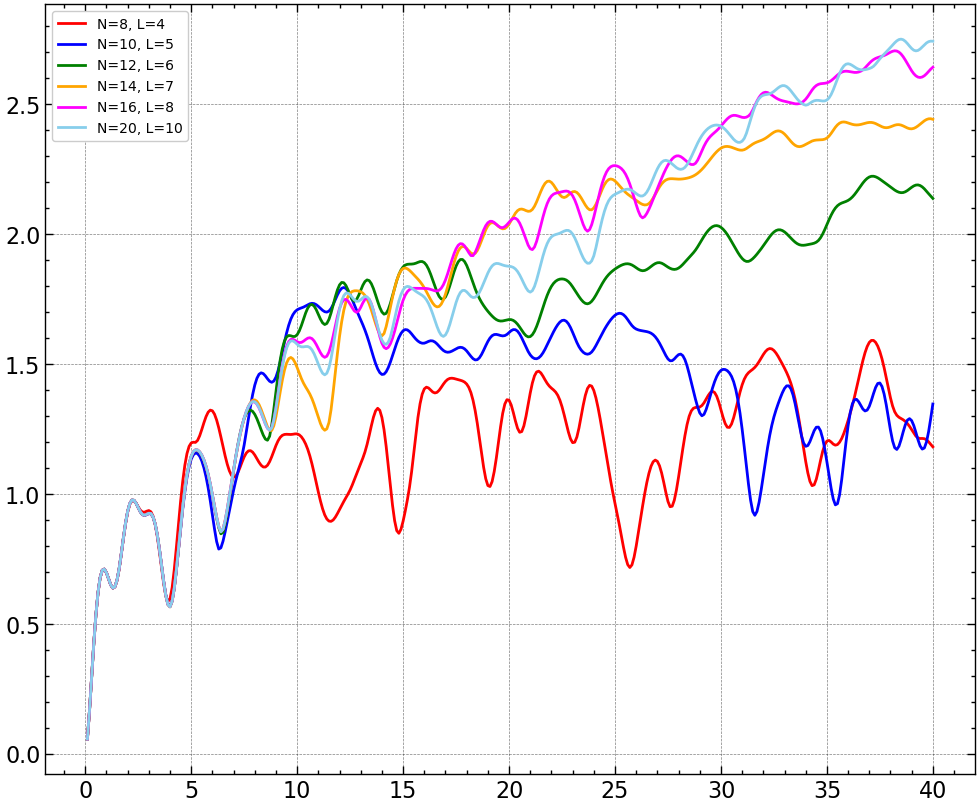

In [244]:
datan8 = np.loadtxt('Fredkin_vN_DW_N8_L4_dt0p1_t100-new.txt')
datan10 = np.loadtxt('Fredkin_vN_DW_N10_L5_dt0p1_t100-new.txt')
datan12 = np.loadtxt('Fredkin_vN_DW_N12_L6_dt0p1_t100-new.txt')
datan14 = np.loadtxt('Fredkin_vN_DW_N14_L7_dt0p1_t100-new.txt')
datan16 = np.loadtxt('Fredkin_vN_DW_N16_L8_dt0p1_t100-new.txt')
#datan18 = np.loadtxt('Fredkin_vN_Neel_N18_L9_dt0p1_t100-new.txt')
datan20 = np.loadtxt('Fredkin_N20_l10_dt0p1_t200.txt')

l=400
xn8 = datan8[:,0][:l]
yn8 = datan8[:,1][:l]

xn10 = datan10[:,0][:l]
yn10 = datan10[:,1][:l]

xn12 = datan12[:,0][:l]
yn12 = datan12[:,1][:l]

xn14 = datan14[:,0][:l]
yn14 = datan14[:,1][:l]

xn16 = datan16[:,0][:l]
yn16 = datan16[:,1][:l]

xn20 = datan20[:,0][:l]
yn20 = datan20[:,1][:l]

plt.figure(figsize=(12,10))
plt.plot(xn8, yn8, color='red', label=r'N=8, L=4')
plt.plot(xn10, yn10, color='blue', label=r'N=10, L=5')
plt.plot(xn12, yn12, color='green', label=r'N=12, L=6')
plt.plot(xn14, yn14, color='orange', label=r'N=14, L=7')
plt.plot(xn16, yn16, color='magenta', label=r'N=16, L=8')
plt.plot(xn20, yn20, color='skyblue', label=r'N=20, L=10')


plt.legend(fontsize=10, loc = 'upper left')




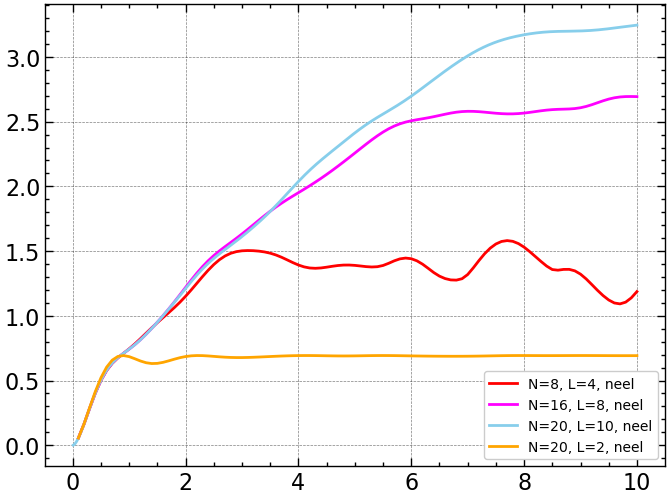

In [9]:
datam8 = np.loadtxt('Fredkin_vN_Neel_N8_L4_dt0p1_t100-new.txt')
datam10 = np.loadtxt('Fredkin_vN_Neel_N10_L5_dt0p1_t100-new.txt')
datam12 = np.loadtxt('Fredkin_vN_Neel_N12_L6_dt0p1_t100-new.txt')
datam14 = np.loadtxt('Fredkin_vN_Neel_N14_L7_dt0p1_t100-new.txt')
datam16 = np.loadtxt('Fredkin_vN_Neel_N16_L8_dt0p1_t100-new.txt')
datam18 = np.loadtxt('Fredkin_vN_Neel_N18_L9_dt0p1_t100-new.txt')
datam20 = np.loadtxt('Fredkin_vN_Neel_N20_left_block_dt0p01_t20-10.txt')
datam100 = np.loadtxt('Fredkin_vN_Neel_N100_L50_dt0p1_t10.txt')
datam20_L2=np.loadtxt("Fredkin_vN_Neel_N20_left_block_L2_dt0p1_t50.txt")

l=100
xm8 = datam8[:,0][:l]
ym8 = datam8[:,1][:l]

xm10 = datam10[:,0][:l]
ym10 = datam10[:,1][:l]

xm12 = datam12[:,0][:l]
ym12 = datam12[:,1][:l]

xm14 = datam14[:,0][:l]
ym14 = datam14[:,1][:l]

xm16 = datam16[:,0][:l]
ym16 = datam16[:,1][:l]

xm18 = datam18[:,0][:l]
ym18 = datam18[:,1][:l]

xm20 = datam20[:,0][:1000]
ym20 = datam20[:,1][:1000]

xm100 = datam100[:,0]
ym100 = datam100[:,1]

xm20_L2 = datam20_L2[:,0][:l]
ym20_L2 = datam20_L2[:,1][:l]




plt.plot(xm8, ym8, color='red', label=r'N=8, L=4, neel')
#plt.plot(xm10, ym10, color='blue', label=r'N=10, L=5, neel')
#plt.plot(xm12, ym12, color='green', label=r'N=12, L=6, neel')
#plt.plot(xm14, ym14, color='orange', label=r'N=14, L=7, neel')
plt.plot(xm16, ym16, color='magenta', label=r'N=16, L=8, neel')
#plt.plot(xm18, ym18, color='skyblue', label=r'N=18, L=9, neel')
plt.plot(xm20, ym20, color='skyblue', label=r'N=20, L=10, neel')
#plt.plot(xm100, ym100, color = 'orange', label=r'N=100, L=50, neel')
plt.plot(xm20_L2, ym20_L2, color = 'orange', label=r'N=20, L=2, neel')



plt.legend(fontsize=10, loc = 'lower right')




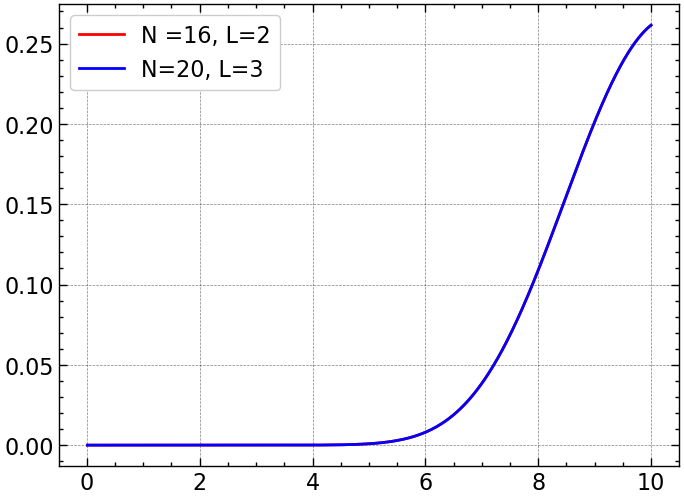

In [139]:
data_20_3 = np.loadtxt('Fredkin_vN_DW_N20_left_block_dt0p01_t20-3.txt')
data_16_2 = np.loadtxt('Fredkin_vN_DW_N20_left_block_dt0p01_t30-2.txt')

x_16_2 = data_16_2[:,0][:1000]
y_16_2 = data_16_2[:,1][:1000]

x_20_2 = data_20_2[:,0][:1000]
y_20_2 = data_20_2[:,1][:1000]

plt.plot(x_16_2, y_16_2, color = 'red', label = r'N =16, L=2')
plt.plot(x_20_2, y_20_2, color = 'blue', label = r'N=20, L=3')
plt.legend(loc='upper left')

In [10]:
#timelist = ntt
t = 0.1
Nstep = 800
alpha = 2.0
filename = "Fredkin_Renyi_DW_N20_two_region_dt0p1_t26-100.txt"
#evolved_state = initial_state
evolved_state = np.squeeze(np.transpose(evol_op(FredkinHam,1.0,26.4,26.4,1).dot(initial_state)))
with open(filename, "w") as file:
    file.write("")

for step in range(Nstep):
    evolved_state = np.squeeze(np.transpose(evol_op(FredkinHam,1.0,t,t,1).dot(evolved_state)))
    S_ent_1 = basis.ent_entropy(evolved_state,sub_sys_A=spinsite_1,density = False,return_rdm="A",enforce_pure=False,return_rdm_EVs=False,sparse=True,alpha=alpha,sparse_diag=True,subsys_ordering=True)
    S_ent_2 = basis.ent_entropy(evolved_state,sub_sys_A=spinsite_2,density = False,return_rdm="A",enforce_pure=False,return_rdm_EVs=False,sparse=True,alpha=alpha,sparse_diag=True,subsys_ordering=True)
    S_ent_f_1 = float(S_ent_1['Sent_A'])
    S_ent_f_2 = float(S_ent_2['Sent_A'])
    tmm = t*(step+1)
    c1 = str(tmm)
    c2 = str(S_ent_f_1)
    c3 = str(S_ent_f_2)
    c4 = c1 +' '+ c2 + ' '+ c3
    with open(filename, "a") as file:
        file.write(c4 + '\n')
        file.flush()

In [13]:
mm1=open('Fredkin_vN_DW_N20_two_region_dt0p01_t10.txt',"r")
linesmm1=mm1.readlines()
resultmm10=[]
resultmm11=[]
resultmm12=[]
for x in linesmm1:
    resultmm10.append(float(x.split(' ')[0]))
    resultmm11.append(float(x.split(' ')[1]))
    resultmm12.append(float(x.split(' ')[2]))
mm1.close()

mm2=open('Fredkin_vN_DW_N20_two_region_dt0p01_t10-20.txt',"r")
linesmm2=mm2.readlines()
resultmm20=[]
resultmm21=[]
resultmm22=[]
for x in linesmm2:
    resultmm20.append(float(x.split(' ')[0]))
    resultmm21.append(float(x.split(' ')[1]))
    resultmm22.append(float(x.split(' ')[2]))
mm2.close()

mm3=open('Fredkin_vN_DW_N20_two_region_dt0p1_t20-100.txt',"r")
linesmm3=mm3.readlines()
resultmm30=[]
resultmm31=[]
resultmm32=[]
for x in linesmm3:
    resultmm30.append(float(x.split(' ')[0]))
    resultmm31.append(float(x.split(' ')[1]))
    resultmm32.append(float(x.split(' ')[2]))
mm3.close()

resm10 = resultmm10 + resultmm20 + resultmm30
resm11 = resultmm11 + resultmm21 + resultmm31
resm12 = resultmm12 + resultmm22 + resultmm32

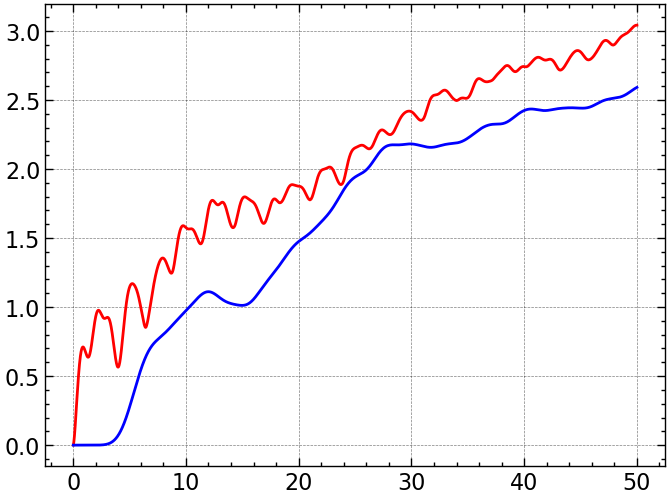

In [24]:
l=2300
plt.plot(resm10[:l], resm11[:l], color='red')
plt.plot(resm10[:l], resm12[:l], color='blue')

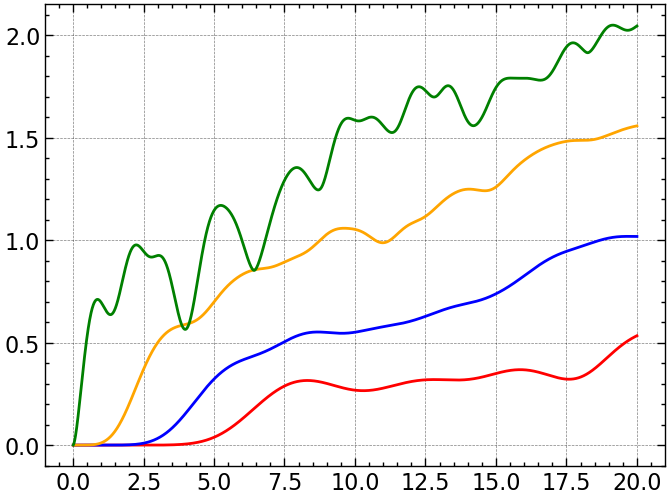

In [58]:
pm1=open('Fredkin_vN_DW_N16_two_region_dt0p01_t100-2.txt',"r")
linespm1=pm1.readlines()
resultpm10=[]
resultpm11=[]
resultpm12=[]
for x in linespm1:
    resultpm10.append(float(x.split(' ')[0]))
    resultpm11.append(float(x.split(' ')[1]))
    resultpm12.append(float(x.split(' ')[2]))
pm1.close()

pm2=open('Fredkin_vN_DW_N16_two_region_dt0p01_t100-4.txt',"r")
linespm2=pm2.readlines()
resultpm20=[]
resultpm21=[]
resultpm22=[]
for x in linespm2:
    resultpm20.append(float(x.split(' ')[0]))
    resultpm21.append(float(x.split(' ')[1]))
    resultpm22.append(float(x.split(' ')[2]))
pm2.close()

pm3=open('Fredkin_vN_DW_N16_two_region_dt0p01_t100-6.txt',"r")
linespm3=pm3.readlines()
resultpm30=[]
resultpm31=[]
resultpm32=[]
for x in linespm3:
    resultpm30.append(float(x.split(' ')[0]))
    resultpm31.append(float(x.split(' ')[1]))
    resultpm32.append(float(x.split(' ')[2]))
pm3.close()

pm4=open('Fredkin_vN_DW_N16_two_region_dt0p01_t100-8.txt',"r")
linespm4=pm4.readlines()
resultpm40=[]
resultpm41=[]
resultpm42=[]
for x in linespm4:
    resultpm40.append(float(x.split(' ')[0]))
    resultpm41.append(float(x.split(' ')[1]))
    resultpm42.append(float(x.split(' ')[2]))
pm4.close()

pn1=open('Fredkin_vN_DW_N16_mid_region_config2_dt0p01_t100-2.txt',"r")
linespn1=pn1.readlines()
resultpn10=[]
resultpn11=[]
resultpn12=[]
for x in linespn1:
    resultpn10.append(float(x.split(' ')[0]))
    resultpn11.append(float(x.split(' ')[1]))
    
pn1.close()

pn2=open('Fredkin_vN_DW_N16_mid_region_config2_dt0p01_t100-4.txt',"r")
linespn2=pn2.readlines()
resultpn20=[]
resultpn21=[]
resultpn22=[]
for x in linespn2:
    resultpn20.append(float(x.split(' ')[0]))
    resultpn21.append(float(x.split(' ')[1]))
    
pn2.close()

pn3=open('Fredkin_vN_DW_N16_mid_region_config2_dt0p01_t100-6.txt',"r")
linespn3=pn3.readlines()
resultpn30=[]
resultpn31=[]
resultpn32=[]
for x in linespn3:
    resultpn30.append(float(x.split(' ')[0]))
    resultpn31.append(float(x.split(' ')[1]))
    
pn3.close()

pn4=open('Fredkin_vN_DW_N16_mid_region_config2_dt0p01_t100-8.txt',"r")
linespn4=pn4.readlines()
resultpn40=[]
resultpn41=[]
resultpn42=[]
for x in linespn4:
    resultpn40.append(float(x.split(' ')[0]))
    resultpn41.append(float(x.split(' ')[1]))
    
pn4.close()

#plt.plot(resultmm10, resultmm11)
plt.plot(resultpm10[:2000], resultpm11[:2000], color='red')
plt.plot(resultpm20[:2000], resultpm21[:2000], color='blue')
plt.plot(resultpm30[:2000], resultpm31[:2000], color='orange')
plt.plot(resultpm40[:2000], resultpm41[:2000], color='green')

#plt.plot(resultpm10, resultpm12, color='blue')
#plt.plot(resultpn10, resultpn11, color='forestgreen')




[0.89360646 0.8901241 ]
[[0.00019446 0.00029367]
 [0.00029367 0.00071517]]


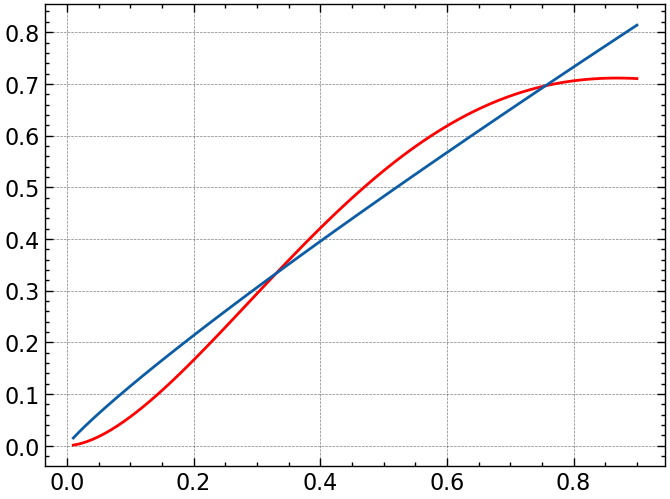

In [72]:
def Sf(t,a,b):
    return a*(t**b)
popt, pcov = curve_fit(Sf, resm10[:l], resm11[:l])
print(popt)
print(pcov)
Sflist = []
for i in resm10[:l]:
    Sflist.append(Sf(i,*popt))
    
plt.plot(resm10[:l], resm11[:l], color='red')

plt.plot(resm10[:l], Sflist)


In [22]:
nn1=open('Fredkin_vN_pert_GS_N20_two_region_dt0p01_t20.txt',"r")
linesnn1=nn1.readlines()
resultnn10=[]
resultnn11=[]
resultnn12=[]
for x in linesnn1:
    resultnn10.append(float(x.split(' ')[0]))
    resultnn11.append(float(x.split(' ')[1]))
    resultnn12.append(float(x.split(' ')[2]))
nn1.close()

nn2=open('Fredkin_vN_pert_GS_N20_two_region_dt0p1_t20-100.txt',"r")
linesnn2=nn2.readlines()
resultnn20=[]
resultnn21=[]
resultnn22=[]
for x in linesnn2:
    resultnn20.append(float(x.split(' ')[0]))
    resultnn21.append(float(x.split(' ')[1]))
    resultnn22.append(float(x.split(' ')[2]))
nn2.close()

resn10 = resultnn10 + resultnn20
resn11 = resultnn11 + resultnn21
resn12 = resultnn12 + resultnn22

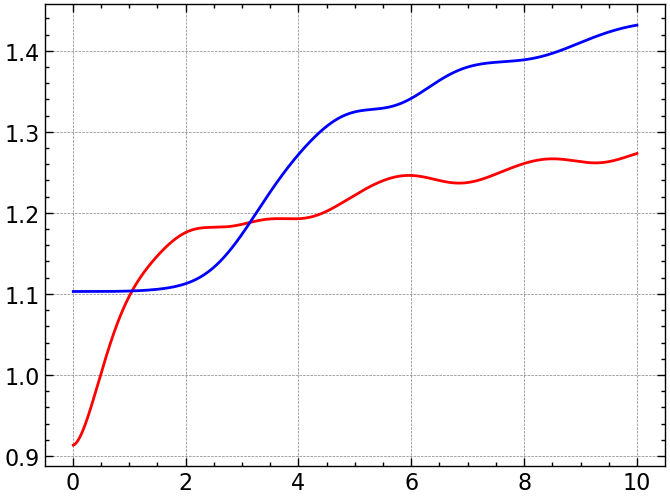

In [36]:
l = 1000
plt.plot(resn10[:l], resn11[:l], color='red')
plt.plot(resn10[:l], resn12[:l], color='blue')

In [28]:
datah1 = np.loadtxt("Fredkin_vN_DW_N20_two_region_dt0p01_t10.txt")
datah2 = np.loadtxt("Fredkin_vN_DW_N20_two_region_dt0p01_t10-20.txt")
datah3 = np.loadtxt("Fredkin_vN_DW_N20_two_region_dt0p1_t20-100.txt")

datah = np.concatenate((datah1, datah2, datah3))

xh = datah[:, 0]
yh = datah[:, 1]
zh = datah[:, 2]

datag1 = np.loadtxt("Fredkin_Renyi_DW_N20_two_region_dt0p01_t100.txt")
datag2 = np.loadtxt("Fredkin_Renyi_DW_N20_two_region_dt0p1_t26-100.txt")

xg1 = datag1[:,0]
yg1 = datag1[:,1]
zg1 = datag1[:,2]

xg2 = datag2[:, 0]
yg2 = datag2[:, 1]
zg2 = datag2[:, 2]

xg21 = [xg2[i]+26.4 for i in range(len(xg2))]

xg = np.concatenate((xg1, xg21))
yg = np.concatenate((yg1, yg2))
zg = np.concatenate((zg1, zg2))

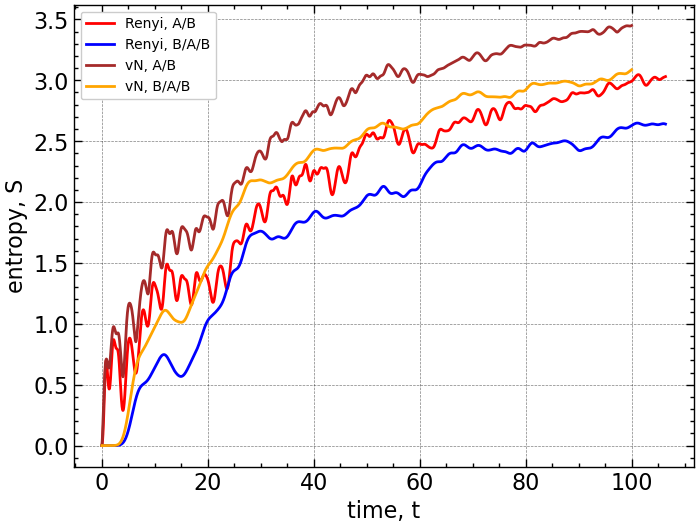

In [29]:
plt.plot(xg, yg, color = 'red', label = 'Renyi, A/B')
plt.plot(xg, zg, color = 'blue', label = 'Renyi, B/A/B')
plt.plot(xh, yh, color = 'brown', label = 'vN, A/B')
plt.plot(xh, zh, color = 'orange', label = 'vN, B/A/B')
plt.xlabel('time, t')
plt.ylabel('entropy, S')
plt.legend(fontsize = 10, loc = 'upper left')

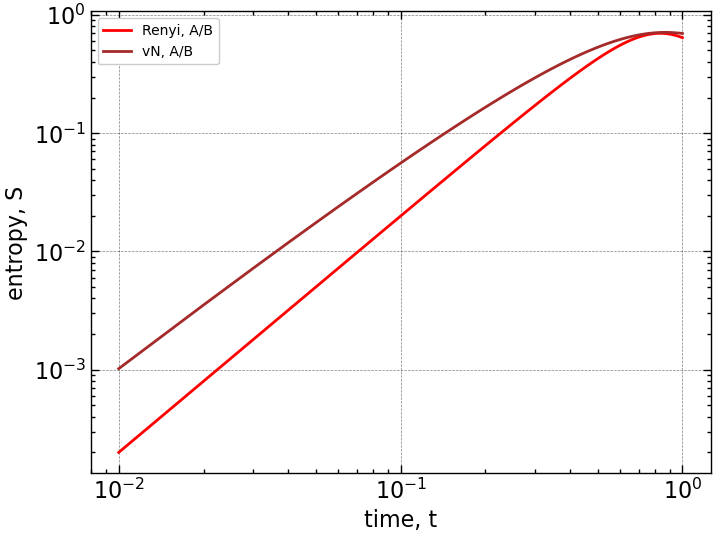

In [30]:
tx = 1.0
xgq = [xg[i] for i in range(len(xg)) if xg[i]<=tx]
ygq = [yg[i] for i in range(len(yg)) if xg[i]<=tx]
zgq = [zg[i] for i in range(len(zg)) if xg[i]<=tx]

xhq = [xh[i] for i in range(len(xh)) if xh[i]<=tx]
yhq = [yh[i] for i in range(len(yh)) if xh[i]<=tx]
zhq = [zh[i] for i in range(len(zh)) if xh[i]<=tx]

plt.plot(xgq, ygq, color = 'red', label = 'Renyi, A/B')
#plt.plot(xgq, zgq, color = 'blue', label = 'Renyi, B/A/B')
plt.plot(xhq, yhq, color = 'brown', label = 'vN, A/B')
#plt.plot(xhq, zhq, color = 'orange', label = 'vN, B/A/B')
plt.xlabel('time, t')
plt.ylabel('entropy, S')
plt.xscale('log')
plt.yscale('log')
plt.legend(fontsize = 10, loc = 'upper left')

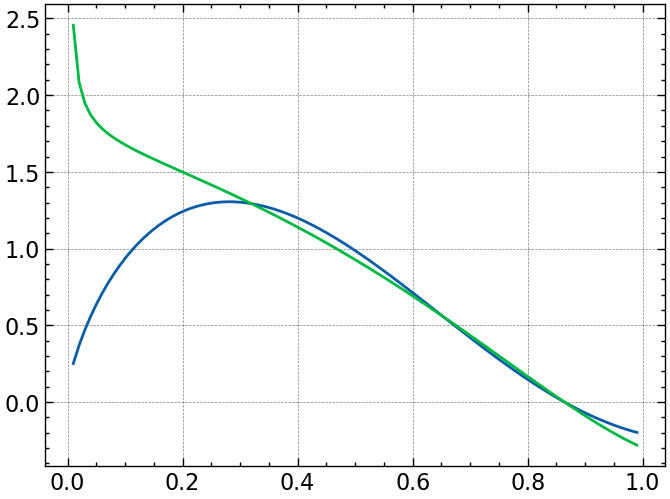

In [78]:
dygq = [(ygq[i+1]-ygq[i])/(xgq[i+1]-xgq[i]) for i in range(len(xgq)-1)]
dyhq = [(yhq[i+1]-yhq[i])/(xhq[i+1]-xhq[i]) for i in range(len(xhq)-1)]


dygqlog = [(xgq[i]/ygq[i])*((ygq[i+1]-ygq[i])/(xgq[i+1]-xgq[i])) for i in range(len(xgq)-1)]
dyhqlog = [(xhq[i]/yhq[i])*((yhq[i+1]-yhq[i])/(xhq[i+1]-xhq[i])) for i in range(len(xhq)-1)]

#plt.plot(xgq[:len(xgq)-1],dygq)
#plt.plot(xgq[:len(xgq)-1],dygqlog)

plt.plot(xhq[:len(xhq)-1],dyhq)
plt.plot(xhq[:len(xhq)-1],dyhqlog)

In [34]:
yhq

[0.0010209868327323614,
 0.003528964728469182,
 0.0072087964325392795,
 0.011891573374117505,
 0.01745838905167638,
 0.02381669863642091,
 0.03089032357907326,
 0.038614246341056195,
 0.04693154906419167,
 0.055791460820177254,
 0.0651480370472622,
 0.07495922620882044,
 0.08518618696710213,
 0.09579277460688342,
 0.10674514590445192,
 0.11801144934380536,
 0.12956157836258184,
 0.14136697213382138,
 0.1534004528538806,
 0.16563609151148542,
 0.17804909618641215,
 0.19061571838836688,
 0.20331317399815937,
 0.2161195761422906,
 0.22901387790364786,
 0.24197582320166405,
 0.25498590450391184,
 0.26802532628502,
 0.2810759733467938,
 0.2941203832696712,
 0.3071417223897441,
 0.32012376479533183,
 0.3330508739175222,
 0.34590798635486675,
 0.35868059762607424,
 0.37135474958910897,
 0.3839170193018939,
 0.396354509130696,
 0.40865483793814505,
 0.4208061332046692,
 0.43279702395570757,
 0.44461663438285176,
 0.4562545780606096,
 0.4677009526721124,
 0.4789463351671785,
 0.4899817772848368

In [70]:
dataw=np.loadtxt("Fredkin_vN_Neel_N20_left_block_dt0p01_t20-10.txt")

xw = dataw[:,0]
yw = dataw[:,1]

txx = 1.0

xwq = [xw[i] for i in range(len(xw)) if xw[i]<=txx]
ywq = [yw[i] for i in range(len(xw)) if xw[i]<=txx]

dywq = [(ywq[i+1]-ywq[i])/(xwq[i+1]-xwq[i]) for i in range(len(xwq)-1)]
dywqlog = [(xwq[i]/ywq[i])*((ywq[i+1]-ywq[i])/(xwq[i+1]-xwq[i])) for i in range(len(xwq)-1)]


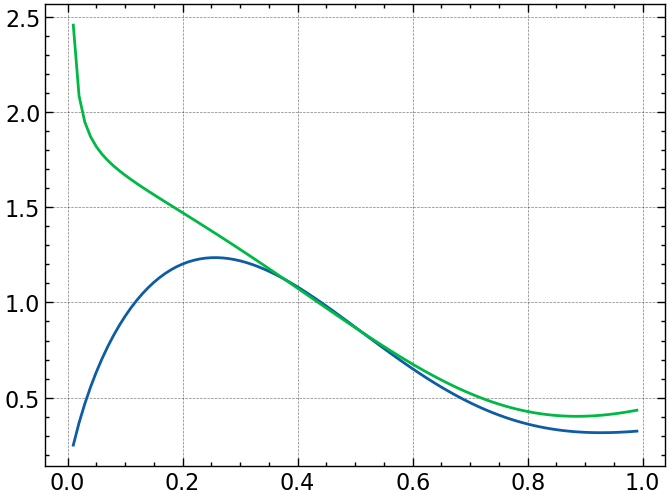

In [71]:
#plt.plot(xwq, ywq)
plt.plot(xwq[:len(xwq)-1],dywq)
plt.plot(xwq[:len(xwq)-1],dywqlog)

#plt.xscale('log')
#plt.yscale('log')

In [79]:
np.array(ywq)

array([0.00102094, 0.00352839, 0.00720619, 0.01188403, 0.01744126,
       0.02378338, 0.03083206, 0.03851996, 0.0467878 , 0.05558232,
       0.06485508, 0.07456152, 0.08466031, 0.09511288, 0.10588298,
       0.11693649, 0.12824111, 0.13976623, 0.15148274, 0.16336297,
       0.17538055, 0.18751031, 0.19972829, 0.21201161, 0.22433844,
       0.23668801, 0.2490405 , 0.26137706, 0.27367978, 0.28593165,
       0.29811655, 0.31021925, 0.32222534, 0.33412129, 0.34589438,
       0.3575327 , 0.36902516, 0.38036144, 0.391532  , 0.40252809,
       0.41334168, 0.4239655 , 0.43439301, 0.44461838, 0.45463648,
       0.46444287, 0.47403378, 0.48340612, 0.49255741, 0.50148583,
       0.51019014, 0.51866973, 0.52692454, 0.53495506, 0.54276236,
       0.55034799, 0.55771401, 0.56486296, 0.57179785, 0.5785221 ,
       0.58503956, 0.59135447, 0.59747143, 0.6033954 , 0.60913163,
       0.61468569, 0.62006342, 0.6252709 , 0.63031443, 0.63520051,
       0.63993582, 0.64452718, 0.64898152, 0.65330591, 0.65750

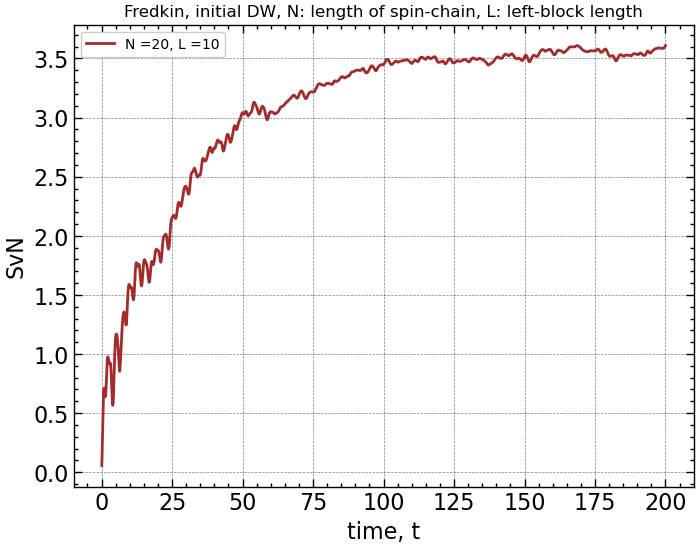

In [124]:
gh1=open('Fredkin_N20_l10_dt0p1_t200.txt',"r")
linesgh1=gh1.readlines()
resultgh10=[]
resultgh11=[]
for x in linesgh1:
    resultgh10.append(float(x.split(' ')[0]))
    resultgh11.append(float(x.split(' ')[1]))
gh1.close()


gg1=open('Fredkin_N16_l8_dt1p0_t200.txt',"r")
linesgg1=gg1.readlines()
resultgg10=[]
resultgg11=[]
for x in linesgg1:
    resultgg10.append(float(x.split(' ')[0]))
    resultgg11.append(float(x.split(' ')[1]))
gg1.close()

gg2=open('Fredkin_SvN_N40_L20_dt0p1_t100_m500.txt',"r")
linesgg2=gg2.readlines()
resultgg20=[]
resultgg21=[]
for x in linesgg2:
    resultgg20.append(float(x.split(' ')[0]))
    resultgg21.append(float(x.split(' ')[1]))
gg2.close()


gg3=open('test_N100_L50_t1_15_t2_35-n.txt',"r")
linesgg3=gg3.readlines()
resultgg30=[]
resultgg31=[]
for x in linesgg3:
    resultgg30.append(float(x.split(' ')[0]))
    resultgg31.append(float(x.split(' ')[1]))
gg3.close()

gg4=open('Fredkin_SvN_N40_L20_dt0p1_t_200-double.txt',"r")
linesgg4=gg4.readlines()
resultgg40=[]
resultgg41=[]
for x in linesgg4:
    resultgg40.append(float(x.split(' ')[0]))
    resultgg41.append(float(x.split(' ')[1]))
gg4.close()

gg5=open('Fredkin_SvN_N100_L50_dt0p1_t200_t1_150-d.txt',"r")
linesgg5=gg5.readlines()
resultgg50=[]
resultgg51=[]
for x in linesgg5:
    resultgg50.append(float(x.split(' ')[0]))
    resultgg51.append(float(x.split(' ')[1]))
gg5.close()

plt.plot(resultgh10, resultgh11, color = 'brown', label = r'N =20, L =10')

#plt.plot(resultgg10, resultgg11, color='red', label = r'N = 16, L = 8')
#plt.plot(resultgg20, resultgg21, color='blue', label = r'N =40, L = 20')

#plt.plot(resultgg40, resultgg41, color='forestgreen', label = r'N =20, L = 10')

#plt.plot(resultgg50, resultgg51, color='black', label = r'N =40, L = 20')
#plt.plot(resultgg30, resultgg31, color='skyblue', label = r'N =40, L = 20')


#plt.plot(resultgg10, resultgg11, color='red', label = r'QuSpin, N = 20, L = 10')
#plt.plot(resultgg20, resultgg21,'o', color='blue', label = r'ITensor-TDVP, N =8, L = 4')

#plt.plot(resultgg30, resultgg31, color='forestgreen', label = r'QuSpin, N =16, L = 8')
#plt.plot(resultgg40, resultgg41,'o', color='orange', label = r'ITensor-TDVP, N =16, L = 8')
plt.xlabel('time, t')
plt.ylabel('SvN')
#plt.xscale('log')
#plt.yscale('log')
plt.legend(fontsize = 10, loc = 'upper left')
plt.title('Fredkin, initial DW, N: length of spin-chain, L: left-block length', size = 12)
plt.savefig('Fredkin_SvN_N20_L10.pdf')

In [34]:
xdata = resultgh10
ydata = resultgh11

xdata1 = xdata[:10]
ydata1 = ydata[:10]

In [45]:
np.array(ydata)

array([0.69620983, 0.93207766, 0.92529881, 0.5654195 , 1.14459356,
       0.99637551, 1.09254064, 1.35418282, 1.3294127 , 1.57569017,
       1.4987976 , 1.70993757, 1.74700276, 1.59139875, 1.78487061,
       1.75712101, 1.61162135, 1.77739356, 1.84975983, 1.87583078,
       1.77631093, 1.98906166, 1.99974929, 1.91585542, 2.15295322,
       2.15575947, 2.25084352, 2.25066587, 2.36522227, 2.41510989,
       2.35741894, 2.53428983, 2.57103448, 2.49585902, 2.51570631,
       2.65537743, 2.63682573, 2.71806591, 2.71408658, 2.74205919,
       2.80179963, 2.78980287, 2.72741443, 2.80007156, 2.8485649 ,
       2.8032532 , 2.92274602, 2.90122207, 2.97899608, 3.04219155,
       3.04851705, 3.01394888, 3.04267545, 3.12792877, 3.09048638,
       3.03079106, 3.0947788 , 3.04452038, 2.99182803, 3.04972506,
       3.04015509, 3.03764785, 3.06471385, 3.09383464, 3.11451912,
       3.13922096, 3.16154834, 3.18900719, 3.17001966, 3.19074715,
       3.22476781, 3.17355942, 3.17990253, 3.21546758, 3.21512

In [41]:
def func(x, a, b):
    return a * x + b

def func_pow(x, a, b):
    return a*(x**b)

popt, pcov = curve_fit(func, xdata1, ydata1)
print(popt)
#print(pcov)
print(np.linalg.cond(pcov))

popt1, pcov1 = curve_fit(func_pow, xdata1, ydata1)
print(popt1)
#print(pcov1)
print(np.linalg.cond(pcov1))


[0.08651051 0.58537233]
187.11587205932747
[0.58102617 0.3760089 ]
48.4738655371608


In [42]:
ydata11 = [func(xdata1[i],*popt) for i in range(len(xdata1))]
ydata12 = [func_pow(xdata1[i],*popt1) for i in range(len(xdata1))]

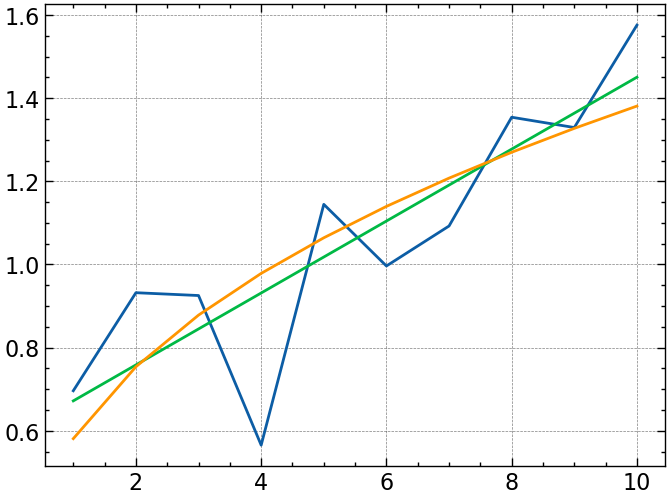

In [43]:
plt.plot(xdata1, ydata1)
plt.plot(xdata1, ydata11)
plt.plot(xdata1, ydata12)

Text(0.5, 1.0, 'Ising, initial all up spin, N: length of spin-chain, L: left-block length')

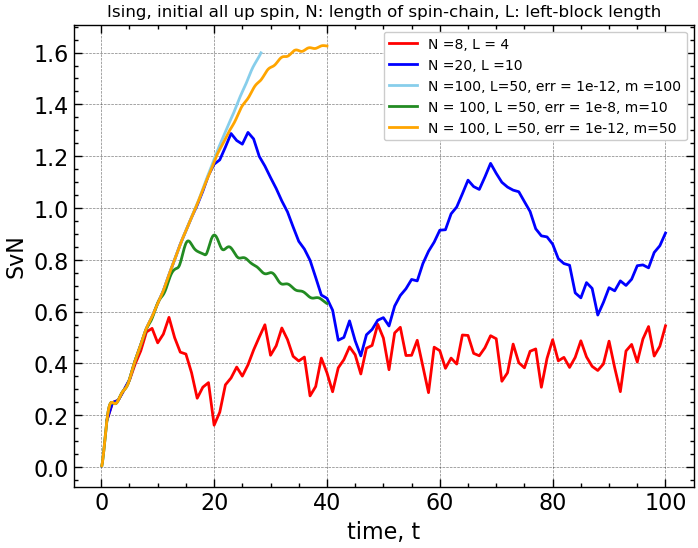

In [12]:
g1=open('new_ising_N8_l4_allup_dt1p0_t1-100.txt',"r")
linesg1=g1.readlines()
resultg10=[]
resultg11=[]
for x in linesg1:
    resultg10.append(float(x.split(' ')[0]))
    resultg11.append(float(x.split(' ')[1]))
g1.close()

g2=open('new_ising_N20_l10_allup_dt1p0_t1-100.txt',"r")
linesg2=g2.readlines()
resultg20=[]
resultg21=[]
for x in linesg2:
    resultg20.append(float(x.split(' ')[0]))
    resultg21.append(float(x.split(' ')[1]))
g2.close()

g3=open('Ising_SvN_N100_L50_dt0p1_t50-2.txt',"r")
linesg3=g3.readlines()
resultg30=[]
resultg31=[]
for x in linesg3:
    resultg30.append(float(x.split(' ')[0]))
    resultg31.append(float(x.split(' ')[1]))
g3.close()

g4=open('Ising_SvN_N100_L50_dt0p1_t40_chi_10.txt',"r")
linesg4=g4.readlines()
resultg40=[]
resultg41=[]
for x in linesg4:
    resultg40.append(float(x.split(' ')[0]))
    resultg41.append(float(x.split(' ')[1]))
g4.close()

g5=open('Ising_SvN_N100_L50_dt0p1_t40_chi_50.txt',"r")
linesg5=g5.readlines()
resultg50=[]
resultg51=[]
for x in linesg5:
    resultg50.append(float(x.split(' ')[0]))
    resultg51.append(float(x.split(' ')[1]))
g5.close()


plt.plot(resultg10,resultg11,color='red', label=r'N =8, L = 4')
plt.plot(resultg20,resultg21,color='blue', label=r'N =20, L =10')
plt.plot(resultg30,resultg31,color='skyblue', label = r'N =100, L=50, err = 1e-12, m =100')
plt.plot(resultg40,resultg41,color='forestgreen', label = r'N = 100, L =50, err = 1e-8, m=10')
plt.plot(resultg50,resultg51,color='orange',label = r'N = 100, L =50, err = 1e-12, m=50' )


plt.xlabel('time, t')
plt.ylabel('SvN')
plt.legend(fontsize = 10, loc = 'upper right')
plt.title('Ising, initial all up spin, N: length of spin-chain, L: left-block length', size = 12)
#plt.savefig('Ising_SvN_comparison_N8_and_N20.pdf')

In [13]:
f1=open('S_vN_ising_N6_t0-t100.txt',"r")
lines1=f1.readlines()
result10=[]
result11=[]
for x in lines1:
    result10.append(float(x.split(' ')[0]))
    result11.append(float(x.split(' ')[1]))
f1.close()

f2=open('S_vN_ising_N8_t0-t100.txt',"r")
lines2=f2.readlines()
result20=[]
result21=[]
for x in lines2:
    result20.append(float(x.split(' ')[0]))
    result21.append(float(x.split(' ')[1]))
f2.close()

f3=open('S_vN_ising_N10_t0-t100.txt',"r")
lines3=f3.readlines()
result30=[]
result31=[]
for x in lines3:
    result30.append(float(x.split(' ')[0]))
    result31.append(float(x.split(' ')[1]))
f3.close()

f4=open('S_vN_ising_N12_t0-t100.txt',"r")
lines4=f4.readlines()
result40=[]
result41=[]
for x in lines4:
    result40.append(float(x.split(' ')[0]))
    result41.append(float(x.split(' ')[1]))
f4.close()

f5=open('S_vN_ising_N14_t0-t100.txt',"r")
lines5=f5.readlines()
result50=[]
result51=[]
for x in lines5:
    result50.append(float(x.split(' ')[0]))
    result51.append(float(x.split(' ')[1]))
f5.close()

f6=open('S_vN_ising_N16_t0-t100.txt',"r")
lines6=f6.readlines()
result60=[]
result61=[]
for x in lines6:
    result60.append(float(x.split(' ')[0]))
    result61.append(float(x.split(' ')[1]))
f6.close()

f7=open('S_vN_ising_N18_t0-t100.txt',"r")
lines7=f7.readlines()
result70=[]
result71=[]
for x in lines7:
    result70.append(float(x.split(' ')[0]))
    result71.append(float(x.split(' ')[1]))
f7.close()

f8=open('S_vN_ising_N20_t0-t30.txt',"r")
lines8=f8.readlines()
result80=[]
result81=[]
for x in lines8:
    result80.append(float(x.split(' ')[0]))
    result81.append(float(x.split(' ')[1]))
f8.close()

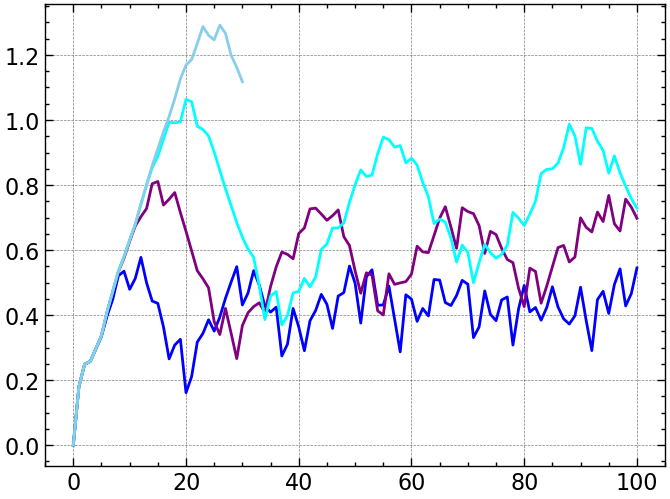

In [16]:
#plt.plot(result10,result11,color='red')
plt.plot(result20,result21,color='blue')
#plt.plot(result30,result31,color='orange')
plt.plot(result40,result41,color='purple')
#plt.plot(result50,result51,color='green')
plt.plot(result60,result61,color='cyan')
#plt.plot(result70,result71,color='pink')
plt.plot(result80,result81,color='skyblue')

#plt.xscale('log')
#plt.yscale('log')

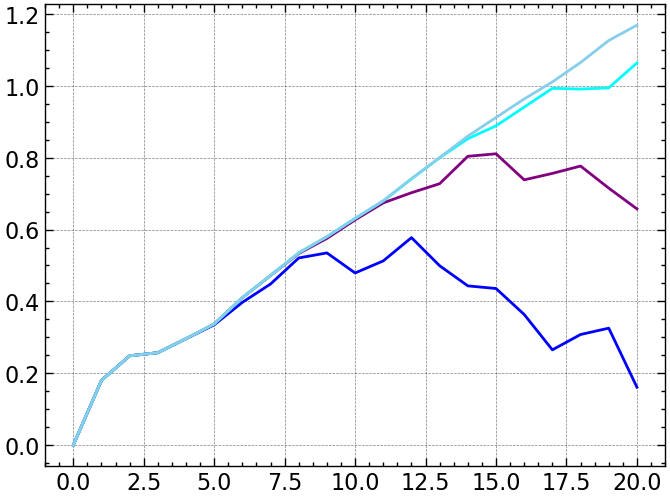

In [19]:
#plt.plot(result10[:20],result11[:20],color='red')
plt.plot(result20[:21],result21[:21],color='blue')
#plt.plot(result30[:20],result31[:20],color='orange')
plt.plot(result40[:21],result41[:21],color='purple')
#plt.plot(result50[:20],result51[:20],color='green')
plt.plot(result60[:21],result61[:21],color='cyan')
#plt.plot(result70[:20],result71[:20],color='pink')
plt.plot(result80[:21],result81[:21],color='skyblue')


In [ ]:
Talal_secondary_school_certificate